# Exploratory Data Analysis Notebook of Aggregate Analysis of ClinicalTrials.gov (AACT) Database.

Flat Text data files were downloaded from https://aact.ctti-clinicaltrials.org/downloads on April 14, 2026. (See Historical Data).  This is the source for the current Raw Data.

Define folder locations

## Section 1: Environment & Module Pathing
We add the project root to the Python path to allow direct imports of our production modules.

In [2]:
import os
import sys
import pandas as pd
import numpy as np
from datetime import datetime

# Detect Environment
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_ROOT = '/content/drive/MyDrive/BIFX546/'
    DATA_DIR = os.path.join(PROJECT_ROOT, 'data/demo/')
    sys.path.append(PROJECT_ROOT)
    !pip install -q matplotlib-venn
else:
    PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
    DATA_DIR = os.path.join(PROJECT_ROOT, 'data/demo/')
    sys.path.append(PROJECT_ROOT)

print(f"Project Root added to path: {PROJECT_ROOT}")
print(f"Data Directory: {DATA_DIR}")

Project Root added to path: c:\Users\Ownwer\Documents\BIFX\BIFX546\Final_Project
Data Directory: c:\Users\Ownwer\Documents\BIFX\BIFX546\Final_Project\data/demo/


In [62]:
# Run this inside the script file, not just the console

print(f"Is PROJECT_ROOT still here? {PROJECT_ROOT}")
print(f"Currently defined variables: {list(locals().keys())}")

Is PROJECT_ROOT still here? c:\Users\Ownwer\Documents\BIFX\BIFX546\Final_Project
Currently defined variables: ['__name__', '__doc__', '__package__', '__loader__', '__spec__', '__builtin__', '__builtins__', '_ih', '_oh', '_dh', 'In', 'Out', 'get_ipython', 'exit', 'quit', 'open', 'help', '_', '__', '___', '_i', '_ii', '_iii', '_i1', '_i2', 'os', 'sys', 'pd', 'np', 'datetime', 'IN_COLAB', 'PROJECT_ROOT', 'DATA_DIR', '_i3', 'INTERIM_DIR', 'PROCESSED_DIR', 'RAW_DIR', '_i4', 'studies_df', '_i5', '_5', '_i6', '_6', '_i7', '_7', '_i8', '_8', '_i9', '_9', '_i10', 'phase_nan_count', 'num_studies', 'num_studies_with_data', 'percent_missing_phase', '_i11', '_11', '_i12', '_12', '_i13', 'sns', 'plt', '_i14', '_14', '_i15', '_15', '_i16', 'interventional_only', 'int_phase_nans', 'total_int', '_i17', '_17', '_i18', '_i19', '_19', '_i20', '_20', '_i21', '_21', '_i22', '_22', '_i23', '_23', '_i24', '_24', '_i25', '_25', '_i26', '_26', '_i27', '_27', '_i28', '_28', '_i29', '_29', '_i30', 'interventional

Define the pathways to the data directories (interim, processed, raw data)

In [3]:
INTERIM_DIR = os.path.join(PROJECT_ROOT, 'data', 'interim')
PROCESSED_DIR = os.path.join(PROJECT_ROOT, 'data', 'processed')
RAW_DIR = os.path.join(PROJECT_ROOT, 'data','raw')

## Section 1 Exploring AACT tables

### **studies table**

Basic info about study, including study title, date study registered with ClinicalTrials.gov, date results first posted to ClinicalTrials.gov, dates for study start and completion, phase of study, enrollment status, planned or actual enrollment, number of study arms/groups, etc.
https://aact.ctti-clinicaltrials.org/data_dictionary

Load the studies.txt csv from the raw data directory

In [31]:
# Load studies.txt from raw data directory
studies_df = pd.read_csv(os.path.join(RAW_DIR, 'studies.txt'), sep='|')

<positron-console-cell-31>:2: DtypeWarning: Columns (0: expanded_access_type_individual, 1: expanded_access_type_intermediate, 2: expanded_access_type_treatment, 3: is_ppsd, 4: fdaaa801_violation) have mixed types. Specify dtype option on import or set low_memory=False.


In [ ]:
studies_df.shape #580247 x 71

(580247, 71)

In [6]:
studies_df.columns

Index(['nct_id', 'nlm_download_date_description', 'study_first_submitted_date',
       'results_first_submitted_date', 'disposition_first_submitted_date',
       'last_update_submitted_date', 'study_first_submitted_qc_date',
       'study_first_posted_date', 'study_first_posted_date_type',
       'results_first_submitted_qc_date', 'results_first_posted_date',
       'results_first_posted_date_type', 'disposition_first_submitted_qc_date',
       'disposition_first_posted_date', 'disposition_first_posted_date_type',
       'last_update_submitted_qc_date', 'last_update_posted_date',
       'last_update_posted_date_type', 'start_month_year', 'start_date_type',
       'start_date', 'verification_month_year', 'verification_date',
       'completion_month_year', 'completion_date_type', 'completion_date',
       'primary_completion_month_year', 'primary_completion_date_type',
       'primary_completion_date', 'target_duration', 'study_type', 'acronym',
       'baseline_population', 'brief_titl

#### **nct_id**

foreign key referencing studies.nct_id

Table:
studies
Field:
nct_id

https://aact.ctti-clinicaltrials.org/documentation/388

In [24]:
studies_df['nct_id'].isna().sum()

np.int64(0)

In [65]:
studies_df['nct_id'].describe()

count          580247
unique         580247
top       NCT06545955
freq                1
Name: nct_id, dtype: object

#### **phase**

Definition: For a clinical trial of a drug product (including a biological product), the numerical phase of such clinical trial, consistent with terminology in 21 CFR 312.21 and in 21 CFR 312.85 for phase 4 studies. Select only one.

    N/A: Trials without phases (for example, studies of devices or behavioral interventions).
    Early Phase 1 (Formerly listed as "Phase 0"): Exploratory trials, involving very limited human exposure, with no therapeutic or diagnostic intent (e.g., screening studies, microdose studies). See FDA guidance on exploratory IND studies for more information.
    Phase 1: Includes initial studies to determine the metabolism and pharmacologic actions of drugs in humans, the side effects associated with increasing doses, and to gain early evidence of effectiveness; may include healthy participants and/or patients.
    Phase 1/Phase 2: Trials that are a combination of phases 1 and 2.
    Phase 2: Includes controlled clinical studies conducted to evaluate the effectiveness of the drug for a particular indication or indications in participants with the disease or condition under study and to determine the common short-term side effects and risks.
    Phase 2/Phase 3: Trials that are a combination of phases 2 and 3.
    Phase 3: Includes trials conducted after preliminary evidence suggesting effectiveness of the drug has been obtained, and are intended to gather additional information to evaluate the overall benefit-risk relationship of the drug.
    Phase 4: Studies of FDA-approved drugs to delineate additional information including the drug's risks, benefits, and optimal use. 

https://clinicaltrials.gov/policy/protocol-definitions

For Trials if Study Start Date is on or after January 18, 2017

Interventional Study Design * (For interventional studies only)

    Primary Purpose *§

    Definition: The main objective of the intervention(s) being evaluated by the clinical trial. Select one.

        Treatment: One or more interventions are being evaluated for treating a disease, syndrome, or condition.
        Prevention: One or more interventions are being assessed for preventing the development of a specific disease or health condition.
        Diagnostic: One or more interventions are being evaluated for identifying a disease or health condition.
        Supportive Care: One or more interventions are evaluated for maximizing comfort, minimizing side effects, or mitigating against a decline in the participant's health or function.
        Screening: One or more interventions are assessed or examined for identifying a condition, or risk factors for a condition, in people who are not yet known to have the condition or risk factor.
        Health Services Research: One or more interventions for evaluating the delivery, processes, management, organization, or financing of healthcare.
        Basic Science: One or more interventions for examining the basic mechanism of action (for example, physiology or biomechanics of an intervention).
        Device Feasibility: An intervention of a device product is being evaluated in a small clinical trial (generally fewer than 10 participants) to determine the feasibility of the product; or a clinical trial to test a prototype device for feasibility and not health outcomes. Such studies are conducted to confirm the design and operating specifications of a device before beginning a full clinical trial.
        Other: None of the other options applies. 

Interventional Study Model *§

Definition: The strategy for assigning interventions to participants.

    Single Group: Clinical trials with a single arm
    Parallel: Participants are assigned to one of two or more groups in parallel for the duration of the study
    Crossover: Participants receive one of two (or more) alternative interventions during the initial phase of the study and receive the other intervention during the second phase of the study
    Factorial: Two or more interventions, each alone and in combination, are evaluated in parallel against a control group
    Sequential: Groups of participants are assigned to receive interventions based on prior milestones being reached in the study, such as in some dose escalation and adaptive design studies
    Model Description
    Definitions: Provide details about the Interventional Study Model.
    Limit: 1,000 characters. 

In [9]:
studies_df['phase'].describe

<bound method NDFrame.describe of 0                PHASE3
1                   NaN
2                PHASE1
3         PHASE1/PHASE2
4                   NaN
              ...      
580242              NaN
580243           PHASE3
580244           PHASE3
580245           PHASE4
580246           PHASE2
Name: phase, Length: 580247, dtype: str>

In [10]:
phase_nan_count = studies_df['phase'].isna().sum()
num_studies = studies_df['phase'].size
num_studies_with_data = num_studies - phase_nan_count
percent_missing_phase = phase_nan_count / num_studies

print(f"Number of NaN values in phase colum: {phase_nan_count}")
print(f"Total number of studies: {num_studies}")
print(f"Percent of Studies missing Phase entry: {percent_missing_phase: .2%}")

Number of NaN values in phase colum: 362271
Total number of studies: 580247
Percent of Studies missing Phase entry:  62.43%


In [27]:
interventional_only['phase'].isna().sum()

np.int64(224861)

In [11]:
studies_df['phase'].value_counts()

phase
PHASE2           63894
PHASE1           47424
PHASE3           41432
PHASE4           35026
PHASE1/PHASE2    16565
PHASE2/PHASE3     7418
EARLY_PHASE1      6217
Name: count, dtype: int64

In [21]:
studies_df['phase'].value_counts().sum()

np.int64(217976)

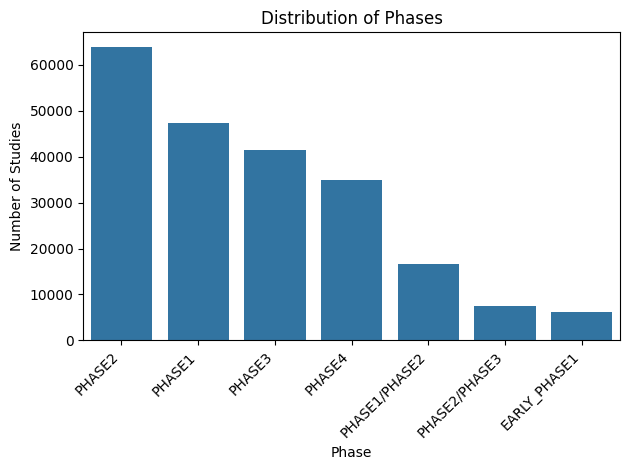

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# Shorthand version using countplot
sns.countplot(
    x="phase", 
    data=studies_df, 
    order=studies_df['phase'].value_counts().index # Keeps them sorted
)
plt.xticks(rotation=45)

plt.title('Distribution of Phases')
plt.xlabel('Phase')
plt.ylabel('Number of Studies')
plt.xticks(rotation=45, ha='right') # Rotate labels so they don't overlap
plt.tight_layout() # Ensures labels are not truncated


#### **study_type**

In [ ]:
studies_df['study_type'].isna().sum() #967

np.int64(967)

In [33]:
studies_df['study_type'].describe()

count             579280
unique                 3
top       INTERVENTIONAL
freq              442837
Name: study_type, dtype: object

In [ ]:
studies_df['study_type'].value_counts()
# INTERVENTIONAL 442837
# OBSERVATIONAL 135403
# EXPANDED_ACCESS 1040

study_type
INTERVENTIONAL     442837
OBSERVATIONAL      135403
EXPANDED_ACCESS      1040
Name: count, dtype: int64

In [18]:
# 1. Create a subset of just the Interventional trials
interventional_only = studies_df[studies_df['study_type'] == 'INTERVENTIONAL']

# 2. Count NaNs in the 'phase' column for ONLY this group
int_phase_nans = interventional_only['phase'].isna().sum()
total_int = len(interventional_only)

# 3. Print the results
print(f"Total Interventional Studies: {total_int:,}")
print(f"Missing Phases (Interventional): {int_phase_nans:,}")
print(f"Percent Missing in this group: {int_phase_nans / total_int:.2%}")

Total Interventional Studies: 442,837
Missing Phases (Interventional): 224,861
Percent Missing in this group: 50.78%


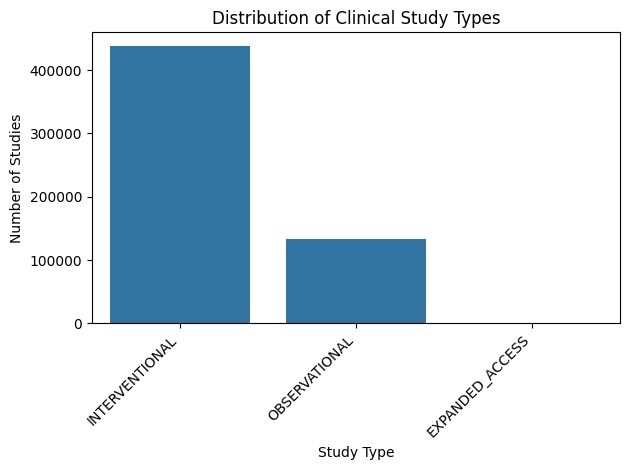

In [184]:
import seaborn as sns
import matplotlib.pyplot as plt

# Shorthand version using countplot
sns.countplot(
    x="study_type", 
    data=studies_df, 
    order=studies_df['study_type'].value_counts().index # Keeps them sorted
)
plt.xticks(rotation=45)

plt.title('Distribution of Clinical Study Types')
plt.xlabel('Study Type')
plt.ylabel('Number of Studies')
plt.xticks(rotation=45, ha='right') # Rotate labels so they don't overlap
plt.tight_layout() # Ensures labels are not truncated

plt.savefig('study_type_countplot.png')

#### **overall_status**

Definition: The recruitment status for the clinical study as a whole, based upon the status of the individual sites. If at least one facility in a multi-site clinical study has an Individual Site Status of "Recruiting," then the Overall Recruitment Status for the study must be "Recruiting." Select one.

    **Not yet recruiting** : Participants are not yet being recruited
    **Recruiting** : Participants are currently being recruited, whether or not any participants have yet been enrolled
    **Enrolling by invitation** : Participants are being (or will be) selected from a predetermined population
    **Active, not recruiting** : Study is continuing, meaning participants are receiving an intervention or being examined, but new participants are not currently being recruited or enrolled
    **Completed** : The study has concluded normally; participants are no longer receiving an intervention or being examined (that is, last participant’s last visit has occurred)
    **Suspended** : Study halted prematurely but potentially will resume
    **Terminated** : Study halted prematurely and will not resume; participants are no longer being examined or receiving intervention
    **Withdrawn** : Study halted prematurely, prior to enrollment of first participant

https://clinicaltrials.gov/policy/protocol-definitions#study-status

In [ ]:
# all studies
studies_df['overall_status'].isna().sum()

np.int64(0)

In [18]:
studies_df['overall_status'].info()

<class 'pandas.Series'>
RangeIndex: 580247 entries, 0 to 580246
Series name: overall_status
Non-Null Count   Dtype
--------------   -----
580247 non-null  str  
dtypes: str(1)
memory usage: 9.9 MB


In [189]:
studies_df['overall_status'].value_counts()

overall_status
COMPLETED                    313413
UNKNOWN                       88224
RECRUITING                    65739
TERMINATED                    32972
NOT_YET_RECRUITING            26920
ACTIVE_NOT_RECRUITING         21593
WITHDRAWN                     16050
ENROLLING_BY_INVITATION        5078
SUSPENDED                      1687
WITHHELD                        964
NO_LONGER_AVAILABLE             514
AVAILABLE                       252
APPROVED_FOR_MARKETING          234
TEMPORARILY_NOT_AVAILABLE        34
Name: count, dtype: int64

In [27]:
# Create list of overall_status to filter for
svef_status_list = [
    'UNKNOWN', 'TERMINATED', 'WITHDRAWN', 'SUSPENDED' 
 ]

In [28]:
# svef_list
# create a new panda dataframe that has interventional only studies and svef_status_list
interventional_svef_list = interventional_only[interventional_only['overall_status'].isin(svef_status_list)].copy()

##### **interventional_terminated**

In [29]:
# inverventional_terminated
# create new dataframe that has interventional only studies and only TERMINATED
interventional_terminated = interventional_only[interventional_only['overall_status'] == 'TERMINATED']

In [ ]:
interventional_terminated['overall_status'].describe() # 28,866 only TERMINATED

count          28866
unique             1
top       TERMINATED
freq           28866
Name: overall_status, dtype: object

In [98]:
len(interventional_terminated['overall_status'])

28866

##### **interventional_withdrawn**

In [30]:
# interventional_withdrwan
# create new dataframe that has interventional only studies and only WITHDRAWN
interventional_withdrawn = interventional_only[interventional_only['overall_status'] == 'WITHDRAWN']

In [116]:
interventional_withdrawn['overall_status'].describe() # 13,366 only WITHDRWAN

count         13366
unique            1
top       WITHDRAWN
freq          13366
Name: overall_status, dtype: object

##### **interventional_suspended**

In [31]:
# interventional_suspended
# create a new dataframe that has interventional only studies and only SUSPENDED
interventional_suspended = interventional_only[interventional_only['overall_status'] == 'SUSPENDED']

In [ ]:
interventional_suspended['overall_status'].describe() # 1,391 only SUSPENDED

count          1391
unique            1
top       SUSPENDED
freq           1391
Name: overall_status, dtype: object

##### ##### **interventional_completed**

In [32]:
# interventional_completed
# create a new dataframe that has interventional only studies and only COMPLETED
interventional_completed = interventional_only[interventional_only['overall_status'] == 'COMPLETED']

In [ ]:
interventional_completed['overall_status'].describe() # 247,958 and only COMPLETED

count        247958
unique            1
top       COMPLETED
freq         247958
Name: overall_status, dtype: object

In [75]:
interventional_svef_list['overall_status'].describe()

count      106877
unique          4
top       UNKNOWN
freq        63254
Name: overall_status, dtype: object

#### **why_stopped**

Why Study Stopped *§ (Required for For Trials if Study Start Date is on or after January 18, 2017 )

Definition: A brief explanation of the reason(s) why such clinical study was stopped (for a clinical study that is "Suspended," "Terminated," or "Withdrawn" prior to its planned completion as anticipated by the protocol).
Limit: 250 characters.

https://clinicaltrials.gov/policy/protocol-definitions#study-status

In [ ]:
# all studies
studies_df['why_stopped'].isna().sum() # 534,894

np.int64(534894)

In [36]:
# interventional only studies
interventional_why_stopped_missing = interventional_only['why_stopped'].isna().sum() # 404,006
interventional_only_total = len(interventional_only)
interventional_why_stopped = interventional_only_total - interventional_why_stopped_missing
print(f"Total of {interventional_only_total} studies with " \
    f"{interventional_why_stopped_missing} studies missing why_stopped feature")
print(f"Only {interventional_why_stopped} interventional studies with why_stopped data")


Total of 442837 studies with 404006 studies missing why_stopped feature
Only 38831 interventional studies with why_stopped data


In [ ]:
# all studies
studies_df['why_stopped'].describe()

count                45353
unique               32898
top       Sponsor decision
freq                   319
Name: why_stopped, dtype: object

In [92]:
# only interventional studies
interventional_only['why_stopped'].describe()

count                38831
unique               28369
top       Sponsor decision
freq                   297
Name: why_stopped, dtype: object

##### **interventional_completed['why_stopped']**

In [93]:
interventional_completed['why_stopped'].describe()

count       0
unique      0
top       NaN
freq      NaN
Name: why_stopped, dtype: object

In [106]:
interventional_completed['why_stopped'].isna().sum()

np.int64(247958)

In [105]:
len(interventional_completed)

247958

##### **interventional_terminated['why_stopped']**

In [94]:
interventional_terminated['why_stopped'].describe()

count            25927
unique           18951
top       Slow accrual
freq               226
Name: why_stopped, dtype: object

In [100]:
len(interventional_terminated)

28866

In [95]:
interventional_terminated['why_stopped'].isna().sum()

np.int64(2939)

##### **interventional_suspended['why_stopped']**

In [96]:
interventional_suspended['why_stopped'].describe()

count         1265
unique        1123
top       COVID-19
freq            14
Name: why_stopped, dtype: object

In [101]:
len(interventional_suspended)

1391

In [97]:
interventional_suspended['why_stopped'].isna().sum()

np.int64(126)

##### **interventional_withdrawn['why_stopped']**

In [117]:
interventional_withdrawn['why_stopped'].describe()

count               11639
unique               9051
top       Lack of funding
freq                  142
Name: why_stopped, dtype: object

In [118]:
len(interventional_withdrawn)

13366

In [119]:
interventional_withdrawn['why_stopped'].isna().sum()

np.int64(1727)

In [24]:
studies_df['why_stopped'].value_counts()

why_stopped
Sponsor decision                                                                                                                                                   319
Lack of funding                                                                                                                                                    299
Slow accrual                                                                                                                                                       268
Lack of enrollment                                                                                                                                                 179
Sponsor Decision                                                                                                                                                   168
                                                                                                                                                         

#### **number_of_arms**

"Arm" means a pre-specified group or subgroup of participant(s) in a clinical trial assigned to receive specific intervention(s) (or no intervention) according to a protocol.

https://clinicaltrials.gov/policy/protocol-definitions#arms-groups-interventions

##### **interventional_only['number_of_arms]***

In [ ]:
# all studies
studies_df['number_of_arms'].isna().sum()

np.int64(161377)

In [26]:
print(" 'number_of_arms' missing data: ", interventional_only['number_of_arms'].isna().sum())
print("interventional_only 'number_of_arms' with data: ", interventional_only['number_of_arms'].notna().sum())
print("length of interventional_only: ", len(interventional_only))

 'number_of_arms' missing data:  23967
interventional_only 'number_of_arms' with data:  418870
length of interventional_only:  442837


In [27]:
interventional_only['number_of_arms'].value_counts()

number_of_arms
2.0     231504
1.0     104308
3.0      46142
4.0      21605
5.0       5347
6.0       4464
8.0       1439
7.0       1375
9.0        679
10.0       548
12.0       328
11.0       261
14.0       153
16.0       153
13.0       147
15.0        99
18.0        72
17.0        52
19.0        31
20.0        30
24.0        23
32.0        20
22.0        15
21.0        12
23.0        12
28.0        10
25.0         7
26.0         5
27.0         5
30.0         5
34.0         3
37.0         2
29.0         2
40.0         2
44.0         2
48.0         2
31.0         1
33.0         1
43.0         1
53.0         1
39.0         1
38.0         1
Name: count, dtype: int64

In [ ]:
interventional_only['number_of_arms'].describe()
# mean 2.15
# std 1.37
# min 1.00
# 25% 2.00
# 50% 2.00
# 75% 2.00
# max 53.0

count    418870.000000
mean          2.149178
std           1.366732
min           1.000000
25%           2.000000
50%           2.000000
75%           2.000000
max          53.000000
Name: number_of_arms, dtype: float64

##### **interventional_completed['number_of_arms']**

In [111]:
print(f"length of interventional_completed['number_of_arms'] : ", len(interventional_completed['number_of_arms']))
print(f"number of missing values interventional_completed['number_of_arms'] :", interventional_completed['number_of_arms'].isna().sum())
interventional_completed['number_of_arms'].describe()

length of interventional_completed['number_of_arms'] :  247958
number of missing values interventional_completed['number_of_arms'] : 17614


count    230344.000000
mean          2.219064
std           1.414548
min           1.000000
25%           2.000000
50%           2.000000
75%           2.000000
max          44.000000
Name: number_of_arms, dtype: float64

##### **interventional_terminated['number_of_arms']**

In [112]:
print(f"length of interventional_terminated['number_of_arms'] : ", len(interventional_terminated['number_of_arms']))
print(f"number of missing values interventional_terminated['number_of_arms'] :", interventional_terminated['number_of_arms'].isna().sum())
interventional_terminated['number_of_arms'].describe()

length of interventional_terminated['number_of_arms'] :  28866
number of missing values interventional_terminated['number_of_arms'] : 1861


count    27005.000000
mean         2.089613
std          1.439558
min          1.000000
25%          1.000000
50%          2.000000
75%          2.000000
max         43.000000
Name: number_of_arms, dtype: float64

##### **interventional_suspended['number_of_arms']**

In [113]:
print(f"length of interventional_suspended['number_of_arms'] : ", len(interventional_suspended['number_of_arms']))
print(f"number of missing values interventional_suspended['number_of_arms'] :", interventional_suspended['number_of_arms'].isna().sum())
interventional_suspended['number_of_arms'].describe()

length of interventional_suspended['number_of_arms'] :  1391
number of missing values interventional_suspended['number_of_arms'] : 80


count    1311.000000
mean        2.006102
std         1.329050
min         1.000000
25%         1.000000
50%         2.000000
75%         2.000000
max        26.000000
Name: number_of_arms, dtype: float64

##### **interventional_withdrawn['number_of_arms']**

In [120]:
print(f"length of interventional_withdrawn['number_of_arms'] : ", len(interventional_withdrawn['number_of_arms']))
print(f"number of missing values interventional_withdrawn['number_of_arms'] :", interventional_withdrawn['number_of_arms'].isna().sum())
interventional_withdrawn['number_of_arms'].describe()

length of interventional_withdrawn['number_of_arms'] :  13366
number of missing values interventional_withdrawn['number_of_arms'] : 896


count    12470.000000
mean         1.942662
std          1.073302
min          1.000000
25%          1.000000
50%          2.000000
75%          2.000000
max         21.000000
Name: number_of_arms, dtype: float64

#### **number_of_groups**

Group/Cohort Information (For observational studies only)

Definition: Specify the predefined participant groups (cohorts) to be studied, corresponding to Number of Groups specified under Study Design (for single-group studies, the following data elements are optional). Do not use this section to specify strata (Detailed Description can be used for that purpose, if desired). 

https://clinicaltrials.gov/policy/protocol-definitions#arms-groups-interventions

In [41]:
#all studies
studies_df['number_of_groups'].isna().sum()

np.int64(491432)

In [ ]:
# only interventional studies
print(" 'number_of_groups' missing data: ", interventional_only['number_of_groups'].isna().sum())
print("interventional_only 'number_of_groups' with data: ", interventional_only['number_of_groups'].notna().sum())
print("length of interventional_only: ", len(interventional_only))

 'number_of_groups' missing data:  442837
interventional_only 'number_of_groups' with data:  0
length of interventional_only:  442837


In [82]:
interventional_only['number_of_groups'].describe()

count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: number_of_groups, dtype: float64

#### **enrollment**

Definitions: The estimated total number of participants to be enrolled (target number) or the actual total number of participants that are enrolled in the clinical study.

"Enrolled" means a participant's, or their legally authorized representative’s, agreement to participate in a clinical study following completion of the informed consent process. Potential participants who are screened for the purpose of determining eligibility for the study, but do not participate in the study, are not considered enrolled, unless otherwise specified by the protocol.

https://clinicaltrials.gov/policy/protocol-definitions#IntEnrollment

In [ ]:
print(f"interventional_only 'enrollment' missing data: ", interventional_only['enrollment'].isna().sum())
print(f"interventional_only 'enrollment' with data: ", interventional_only['enrollment'].notna().sum())
print(f"length of interventional_only: ", len(interventional_only))

interventional_only 'enrollment' missing data:  3847
interventional_only 'enrollment' with data:  438990
length of interventional_only:  442837


In [30]:
interventional_only['enrollment'].describe()

count    4.389900e+05
mean     1.142605e+03
std      2.186630e+05
min      0.000000e+00
25%      2.800000e+01
50%      6.000000e+01
75%      1.440000e+02
max      1.000000e+08
Name: enrollment, dtype: float64

In [39]:
### Compare enrollment for interventional only studies of WITHDRWAN, TERMINATED, and SUSPENDED.  
print("number of missing data for interventional_completed['enrollment'] is: ", interventional_completed['enrollment'].isna().sum())
print("interventional_completed 'enrollment' with data: ", interventional_completed['enrollment'].notna().sum())
print("length of interventional_completed: ", len(interventional_completed), end = "\n\n")
print()
print("number of missing data for interventional_terminated['enrollment] is: ", interventional_terminated['enrollment'].isna().sum())
print("interventional_terminated 'enrollment' with data: ", interventional_terminated['enrollment'].notna().sum())
print("length of interventional_terminated: ", len(interventional_terminated), end = "\n\n")

print("number of missing data for interventionl_withdrwan['enrollment'] is: ", interventional_withdrawn['enrollment'].isna().sum())
print("interventional_withdrawn 'enrollment' with data: ", interventional_withdrawn['enrollment'].notna().sum())
print("length of interventional_withdrawn: ", len(interventional_withdrawn), end = "\n\n")

print("number of missing data for interventional_suspended['enrollment'] is: ", interventional_suspended['enrollment'].isna().sum())
print("interventional_suspended 'enrollment' with data: ", interventional_suspended['enrollment'].notna().sum())
print("length of interventional_suspended: ", len(interventional_suspended))

number of missing data for interventional_completed['enrollment'] is:  3011
interventional_completed 'enrollment' with data:  244947
length of interventional_completed:  247958


number of missing data for interventional_terminated['enrollment] is:  214
interventional_terminated 'enrollment' with data:  28652
length of interventional_terminated:  28866

number of missing data for interventionl_withdrwan['enrollment'] is:  16
interventional_withdrawn 'enrollment' with data:  13350
length of interventional_withdrawn:  13366

number of missing data for interventional_suspended['enrollment'] is:  8
interventional_suspended 'enrollment' with data:  1383
length of interventional_suspended:  1391


In [40]:
studies_df['enrollment'].isna().sum()

np.int64(7093)

#### **enrollment_type**

Definitions: The estimated total number of participants to be enrolled (target number) or the actual total number of participants that are enrolled in the clinical study.

"Enrolled" means a participant's, or their legally authorized representative’s, agreement to participate in a clinical study following completion of the informed consent process. Potential participants who are screened for the purpose of determining eligibility for the study, but do not participate in the study, are not considered enrolled, unless otherwise specified by the protocol.

https://clinicaltrials.gov/policy/protocol-definitions#IntEnrollment

enrollment_type appears to be either ACTUAL or ESTIMATED (if present)

In [41]:
interventional_only['enrollment_type'].isna().sum()

np.int64(12187)

In [42]:
### Compare enrollment_type for interventional only studies of WITHDRWAN, TERMINATED, and SUSPENDED.  
print("number of missing data for interventional_completed['enrollment_type'] is: ", interventional_completed['enrollment_type'].isna().sum())
print("interventional_completed 'enrollment_type' with data: ", interventional_completed['enrollment_type'].notna().sum())
print("length of interventional_completed: ", len(interventional_completed), end = "\n\n")
print()
print("number of missing data for interventional_terminated['enrollment_type] is: ", interventional_terminated['enrollment_type'].isna().sum())
print("interventional_terminated 'enrollment_type' with data: ", interventional_terminated['enrollment_type'].notna().sum())
print("length of interventional_terminated: ", len(interventional_terminated), end = "\n\n")

print("number of missing data for interventionl_withdrwan['enrollment_type'] is: ", interventional_withdrawn['enrollment_type'].isna().sum())
print("interventional_withdrawn 'enrollment_type' with data: ", interventional_withdrawn['enrollment_type'].notna().sum())
print("length of interventional_withdrawn: ", len(interventional_withdrawn), end = "\n\n")

print("number of missing data for interventional_suspended['enrollment_type'] is: ", interventional_suspended['enrollment_type'].isna().sum())
print("interventional_suspended 'enrollment_type' with data: ", interventional_suspended['enrollment_type'].notna().sum())
print("length of interventional_suspended: ", len(interventional_suspended))

number of missing data for interventional_completed['enrollment_type'] is:  9710
interventional_completed 'enrollment_type' with data:  238248
length of interventional_completed:  247958


number of missing data for interventional_terminated['enrollment_type] is:  829
interventional_terminated 'enrollment_type' with data:  28037
length of interventional_terminated:  28866

number of missing data for interventionl_withdrwan['enrollment_type'] is:  37
interventional_withdrawn 'enrollment_type' with data:  13329
length of interventional_withdrawn:  13366

number of missing data for interventional_suspended['enrollment_type'] is:  39
interventional_suspended 'enrollment_type' with data:  1352
length of interventional_suspended:  1391


In [43]:
interventional_only['enrollment_type'].describe()

count     430650
unique         2
top       ACTUAL
freq      285228
Name: enrollment_type, dtype: object

In [50]:
enroll_type_summary_counts = pd.concat([
    interventional_completed['enrollment_type'].value_counts(),
    interventional_terminated['enrollment_type'].value_counts(),
    interventional_suspended['enrollment_type'].value_counts(),
    interventional_withdrawn['enrollment_type'].value_counts(),
    interventional_only['enrollment_type'].value_counts()
], axis = 1)

enroll_type_summary_counts.columns = ['Completed', 'Terminated', 'Suspended', 'Withdrawn', 'All_Interventional']

enroll_type_summary_counts = enroll_type_summary_counts.fillna(0).astype(int)

enroll_type_summary_counts

,Completed,Terminated,Suspended,Withdrawn,All_Interventional
enrollment_type,,,,,
ACTUAL,231114,27090,124,13184,285228
ESTIMATED,7134,947,1228,145,145422


#### **last_known_status**

In [ ]:
print("number of missing data for interventional_only['last_known_status'] is: ", interventional_only['last_known_status'].isna().sum())
print("interventional_only 'last_known_status' with data: ", interventional_only['last_known_status'].notna().sum())
print("length of interventional_only: ", len(interventional_only))

number of missing data for interventional_only['last_known_status'] is:  379583
interventional_only 'last_known_status' with data:  63254
length of interventional_only:  442837


In [49]:
interventional_only['last_known_status'].describe()

count          63254
unique             4
top       RECRUITING
freq           35545
Name: last_known_status, dtype: object

In [52]:
interventional_only['last_known_status'].value_counts()

last_known_status
RECRUITING                 35545
NOT_YET_RECRUITING         15317
ACTIVE_NOT_RECRUITING      10236
ENROLLING_BY_INVITATION     2156
Name: count, dtype: int64

In [51]:
last_status_summary_counts = pd.concat([
    interventional_completed['last_known_status'].value_counts(),
    interventional_terminated['last_known_status'].value_counts(),
    interventional_suspended['last_known_status'].value_counts(),
    interventional_withdrawn['last_known_status'].value_counts(),
    interventional_only['last_known_status'].value_counts()
], axis = 1)

last_status_summary_counts.columns = ['Completed', 'Terminated', 'Suspended', 'Withdrawn', 'All_Interventional']

last_status_summary_counts = last_status_summary_counts.fillna(0).astype(int)

last_status_summary_counts

,Completed,Terminated,Suspended,Withdrawn,All_Interventional
last_known_status,,,,,
RECRUITING,0,0,0,0,35545
NOT_YET_RECRUITING,0,0,0,0,15317
ACTIVE_NOT_RECRUITING,0,0,0,0,10236
ENROLLING_BY_INVITATION,0,0,0,0,2156


#### **patient_registry**

In [ ]:
print("number of missing data for interventional_only['patient_registry'] is: ", interventional_only['patient_registry'].isna().sum())
print("interventional_only 'patient_registry' with data: ", interventional_only['patient_registry'].notna().sum())
print("length of interventional_only: ", len(interventional_only))

number of missing data for interventional_only['patient_registry'] is:  442837
interventional_only 'patient_registry' with data:  0
length of interventional_only:  442837


#### **is_fda_regulated_drug**

Table:
studies
Field:
is_fda_regulated_drug

CTGov Section:
Protocol
CTGov Module:
Oversight
CTGov Data Point:
Is FDA Regulated Drug
CTGov API Field Path:
protocolSection.oversightModule.isFdaRegulatedDrug
CTGov Documentation URL:
https://clinicaltrials.gov/policy/protocol-definitions#FDADrugProduct 
https://aact.ctti-clinicaltrials.org/documentation/438

Studies a U.S. FDA-regulated Drug Product *§ (Optional for Observational Studies)

Definition: Indication that a clinical study is studying a drug product (including a biological product) subject to section 505 of the Federal Food, Drug, and Cosmetic Act or to section 351 of the Public Health Service Act. Select Yes/No.
Studies a U.S. FDA-regulated Device Product *§ (Optional for Observational Studies)

Definition: Indication that a clinical study is studying a device product subject to section 510(k), 515, or 520(m) of the Federal Food, Drug, and Cosmetic Act. Select Yes/No.

    Device Product Not Approved or Cleared by U.S. FDA *§ (formerly "Delayed Posting")

    Definition: Indication that at least one device product studied in the clinical study has not been previously approved or cleared by the U.S. Food and Drug Administration (FDA) for one or more uses. Select one.

        Yes: At least one studied FDA-regulated device product has not been previously approved or cleared by FDA
        No: All studied FDA-regulated device products have been previously approved or cleared by FDA
        
https://clinicaltrials.gov/policy/protocol-definitions#FDADrugProduct

In [58]:
print("number of missing data for interventional_only['is_fda_regulated_drug'] is: ", interventional_only['is_fda_regulated_drug'].isna().sum())
print("interventional_only 'is_fda_regulated_drug' with data: ", interventional_only['is_fda_regulated_drug'].notna().sum())
print("length of interventional_only: ", len(interventional_only), end = "\n\n")

print("number of missing data for interventional_completed['is_fda_regulated_drug'] is: ", interventional_completed['is_fda_regulated_drug'].isna().sum())
print("interventional_completed 'is_fda_regulated_drug' with data: ", interventional_completed['is_fda_regulated_drug'].notna().sum())
print("length of interventional_completed: ", len(interventional_completed), end = "\n\n")

print("number of missing data for interventional_terminated['is_fda_regulated_drug'] is: ", interventional_terminated['is_fda_regulated_drug'].isna().sum())
print("interventional_terminated 'is_fda_regulated_drug' with data: ", interventional_terminated['is_fda_regulated_drug'].notna().sum())
print("length of interventional_terminated: ", len(interventional_terminated), end = "\n\n")

print("number of missing data for interventionl_withdrwan['is_fda_regulated_drug'] is: ", interventional_withdrawn['is_fda_regulated_drug'].isna().sum())
print("interventional_withdrawn 'is_fda_regulated_drug' with data: ", interventional_withdrawn['is_fda_regulated_drug'].notna().sum())
print("length of interventional_withdrawn: ", len(interventional_withdrawn), end = "\n\n")

print("number of missing data for interventional_suspended['is_fda_regulated_drug'] is: ", interventional_suspended['is_fda_regulated_drug'].isna().sum())
print("interventional_suspended 'is_fda_regulated_drug' with data: ", interventional_suspended['is_fda_regulated_drug'].notna().sum())
print("length of interventional_suspended: ", len(interventional_suspended))

number of missing data for interventional_only['is_fda_regulated_drug'] is:  174674
interventional_only 'is_fda_regulated_drug' with data:  268163
length of interventional_only:  442837

number of missing data for interventional_completed['is_fda_regulated_drug'] is:  129424
interventional_completed 'is_fda_regulated_drug' with data:  118534
length of interventional_completed:  247958

number of missing data for interventional_terminated['is_fda_regulated_drug'] is:  15867
interventional_terminated 'is_fda_regulated_drug' with data:  12999
length of interventional_terminated:  28866

number of missing data for interventionl_withdrwan['is_fda_regulated_drug'] is:  5961
interventional_withdrawn 'is_fda_regulated_drug' with data:  7405
length of interventional_withdrawn:  13366

number of missing data for interventional_suspended['is_fda_regulated_drug'] is:  390
interventional_suspended 'is_fda_regulated_drug' with data:  1001
length of interventional_suspended:  1391


In [61]:
fda_reg_summary_counts = pd.concat([
    interventional_completed['is_fda_regulated_drug'].value_counts(dropna = False),
    interventional_terminated['is_fda_regulated_drug'].value_counts(dropna = False),
    interventional_suspended['is_fda_regulated_drug'].value_counts(dropna = False),
    interventional_withdrawn['is_fda_regulated_drug'].value_counts(dropna = False),
    interventional_only['is_fda_regulated_drug'].value_counts(dropna = False)
], axis = 1)

fda_reg_summary_counts.columns = ['Completed', 'Terminated', 'Suspended', 'Withdrawn', 'All_Interventional']

fda_reg_summary_counts = fda_reg_summary_counts.fillna(0).astype(int)

fda_reg_summary_counts.index = fda_reg_summary_counts.index.fillna('Missing/Not Reported')

fda_reg_summary_counts

,Completed,Terminated,Suspended,Withdrawn,All_Interventional
is_fda_regulated_drug,,,,,
Missing/Not Reported,129424,15867,390,5961,174674
f,96588,6877,721,4683,218388
t,21946,6122,280,2722,49775


#### **baseline_population**

Table:
studies
Field:
baseline_population

CTGov Section:
Results
CTGov Module:
Baseline Characteristics
CTGov Data Point:
Baseline Population Description
CTGov API Field Path:
resultsSection.baselineCharacteristicsModule.populationDescription
CTGov Documentation URL:
https://clinicaltrials.gov/policy/results-definitions#BaselineAnalysisPopulationDesc 
https://aact.ctti-clinicaltrials.org/documentation/420

In [62]:
studies_df['baseline_population'].isna().sum()

np.int64(554438)

In [63]:
print("number of missing data for interventional_only['baseline_population'] is: ", interventional_only['baseline_population'].isna().sum())
print("interventional_only 'baseline_population' with data: ", interventional_only['baseline_population'].notna().sum())
print("length of interventional_only: ", len(interventional_only), end = "\n\n")

print("number of missing data for interventional_completed['baseline_population'] is: ", interventional_completed['baseline_population'].isna().sum())
print("interventional_completed 'baseline_population' with data: ", interventional_completed['baseline_population'].notna().sum())
print("length of interventional_completed: ", len(interventional_completed), end = "\n\n")

print("number of missing data for interventional_terminated['baseline_population'] is: ", interventional_terminated['baseline_population'].isna().sum())
print("interventional_terminated 'baseline_population' with data: ", interventional_terminated['baseline_population'].notna().sum())
print("length of interventional_terminated: ", len(interventional_terminated), end = "\n\n")

print("number of missing data for interventionl_withdrwan['baseline_population'] is: ", interventional_withdrawn['baseline_population'].isna().sum())
print("interventional_withdrawn 'baseline_population' with data: ", interventional_withdrawn['baseline_population'].notna().sum())
print("length of interventional_withdrawn: ", len(interventional_withdrawn), end = "\n\n")

print("number of missing data for interventional_suspended['baseline_population'] is: ", interventional_suspended['baseline_population'].isna().sum())
print("interventional_suspended 'baseline_population' with data: ", interventional_suspended['baseline_population'].notna().sum())
print("length of interventional_suspended: ", len(interventional_suspended))

number of missing data for interventional_only['baseline_population'] is:  418716
interventional_only 'baseline_population' with data:  24121
length of interventional_only:  442837

number of missing data for interventional_completed['baseline_population'] is:  228379
interventional_completed 'baseline_population' with data:  19579
length of interventional_completed:  247958

number of missing data for interventional_terminated['baseline_population'] is:  24846
interventional_terminated 'baseline_population' with data:  4020
length of interventional_terminated:  28866

number of missing data for interventionl_withdrwan['baseline_population'] is:  13366
interventional_withdrawn 'baseline_population' with data:  0
length of interventional_withdrawn:  13366

number of missing data for interventional_suspended['baseline_population'] is:  1388
interventional_suspended 'baseline_population' with data:  3
length of interventional_suspended:  1391


In [67]:
interventional_only['baseline_population'].describe()

count                            24121
unique                           20358
top       All randomized participants.
freq                               247
Name: baseline_population, dtype: object

#### **baseline_type_units_analyzed**

Type of Units Analyzed [*]

Definition: If the analysis is based on a unit other than participants, a description of the unit of analysis (for example, eyes, lesions, implants).
Limit: 40 characters.

https://clinicaltrials.gov/policy/results-definitions#DocumentUpload

In [65]:
print("number of missing data for interventional_only['baseline_type_units_analyzed'] is: ", interventional_only['baseline_type_units_analyzed'].isna().sum())
print("interventional_only 'baseline_type_units_analyzed' with data: ", interventional_only['baseline_type_units_analyzed'].notna().sum())
print("length of interventional_only: ", len(interventional_only), end = "\n\n")

print("number of missing data for interventional_completed['baseline_type_units_analyzed'] is: ", interventional_completed['baseline_type_units_analyzed'].isna().sum())
print("interventional_completed 'baseline_type_units_analyzed' with data: ", interventional_completed['baseline_type_units_analyzed'].notna().sum())
print("length of interventional_completed: ", len(interventional_completed), end = "\n\n")

print("number of missing data for interventional_terminated['baseline_type_units_analyzed'] is: ", interventional_terminated['baseline_type_units_analyzed'].isna().sum())
print("interventional_terminated 'baseline_type_units_analyzed' with data: ", interventional_terminated['baseline_type_units_analyzed'].notna().sum())
print("length of interventional_terminated: ", len(interventional_terminated), end = "\n\n")

print("number of missing data for interventionl_withdrwan['baseline_type_units_analyzed'] is: ", interventional_withdrawn['baseline_type_units_analyzed'].isna().sum())
print("interventional_withdrawn 'baseline_type_units_analyzed' with data: ", interventional_withdrawn['baseline_type_units_analyzed'].notna().sum())
print("length of interventional_withdrawn: ", len(interventional_withdrawn), end = "\n\n")

print("number of missing data for interventional_suspended['baseline_type_units_analyzed'] is: ", interventional_suspended['baseline_type_units_analyzed'].isna().sum())
print("interventional_suspended 'baseline_type_units_analyzed' with data: ", interventional_suspended['baseline_type_units_analyzed'].notna().sum())
print("length of interventional_suspended: ", len(interventional_suspended))

number of missing data for interventional_only['baseline_type_units_analyzed'] is:  442368
interventional_only 'baseline_type_units_analyzed' with data:  469
length of interventional_only:  442837

number of missing data for interventional_completed['baseline_type_units_analyzed'] is:  247539
interventional_completed 'baseline_type_units_analyzed' with data:  419
length of interventional_completed:  247958

number of missing data for interventional_terminated['baseline_type_units_analyzed'] is:  28819
interventional_terminated 'baseline_type_units_analyzed' with data:  47
length of interventional_terminated:  28866

number of missing data for interventionl_withdrwan['baseline_type_units_analyzed'] is:  13366
interventional_withdrawn 'baseline_type_units_analyzed' with data:  0
length of interventional_withdrawn:  13366

number of missing data for interventional_suspended['baseline_type_units_analyzed'] is:  1391
interventional_suspended 'baseline_type_units_analyzed' with data:  0
leng

In [66]:
interventional_only['baseline_type_units_analyzed'].describe()

count      469
unique     234
top       Eyes
freq        65
Name: baseline_type_units_analyzed, dtype: object

#### **studies columns**

In [59]:
interventional_only.columns

Index(['nct_id', 'nlm_download_date_description', 'study_first_submitted_date', 'results_first_submitted_date', 'disposition_first_submitted_date', 'last_update_submitted_date', 'study_first_submitted_qc_date',
       'study_first_posted_date', 'study_first_posted_date_type', 'results_first_submitted_qc_date', 'results_first_posted_date', 'results_first_posted_date_type', 'disposition_first_submitted_qc_date', 'disposition_first_posted_date',
       'disposition_first_posted_date_type', 'last_update_submitted_qc_date', 'last_update_posted_date', 'last_update_posted_date_type', 'start_month_year', 'start_date_type', 'start_date', 'verification_month_year',
       'verification_date', 'completion_month_year', 'completion_date_type', 'completion_date', 'primary_completion_month_year', 'primary_completion_date_type', 'primary_completion_date', 'target_duration', 'study_type', 'acronym',
       'baseline_population', 'brief_title', 'official_title', 'overall_status', 'last_known_status', 'p

#### **Project Notes**

Project plan for Studies.txt

*Keep features:*
- nct_id
- overall_status
- phase
- study_type
- enrollment
- enrollment_type
- number_of_arms
- why_stopped
- is_fda_regulated_drug
- is_fda_regulated_device 

*Filter Features:*
- ['study_type'] == INTERVENTIONAL
- ['overall_status'] == ['COMPLETED', 'UNKNOWN', 'TERMINATED', 'WITHDRWAN', 'SUSPENDED', 'ENROLLING_BY_INVITATION', 'ACTIVE_NOT_RECRUITING']

In [67]:
## set studies_features equal to the features to keep for subsetting the studies.txt RAW data
studies_features = ['nct_id', 'overall_status', 'phase', 'study_type', 'enrollment', 'enrollment_type', 'number_of_arms', 'why_stopped', 'is_fda_regulated_drug', 'is_fda_regulated_device']

## set status_list equal to overal_status to keep 
status_list = [
    'COMPLETED', 'UNKNOWN', 'TERMINATED', 'WITHDRAWN',
    'SUSPENDED', 'ENROLLING_BY_INVITATION', 'ACTIVE_NOT_RECRUITING'
]

In [68]:
# load studies.txt using only studies_features
studies_df = pd.read_csv(
    os.path.join(RAW_DIR, 'studies.txt'),
    sep = '|',
    usecols = studies_features
)

In [69]:
# Apply filters to studies_df
mask = (studies_df['study_type'] == 'INTERVENTIONAL') & (studies_df['overall_status'].isin(status_list))
studies_filtered_df = studies_df[mask].copy()

In [70]:
# verify filtering
print(f"Total trials in subset: {len(studies_filtered_df)}")
print("Unique statuses found:", studies_filtered_df['overall_status'].unique())

Total trials in subset: 374913
Unique statuses found: <ArrowStringArray>
[                'UNKNOWN',   'ACTIVE_NOT_RECRUITING',
               'COMPLETED',               'WITHDRAWN',
              'TERMINATED', 'ENROLLING_BY_INVITATION',
               'SUSPENDED']
Length: 7, dtype: str


In [73]:
## Create a set of the nct_id in studies_filtered_df for use in other RAW datasets
nct_id_filter_set = set(studies_filtered_df['nct_id'])
print(f"Filter set created with {len(nct_id_filter_set):,} unique IDs")

Filter set created with 374,913 unique IDs


In [75]:
#Extract studies_filtered_df column names into a list
studies_filtered_headers = studies_filtered_df.columns.tolist()

#Verify the list
print(f"Captured {len(studies_filtered_headers)} headers.")
print(studies_filtered_headers)


Captured 10 headers.
['nct_id', 'study_type', 'overall_status', 'phase', 'enrollment', 'enrollment_type', 'number_of_arms', 'why_stopped', 'is_fda_regulated_drug', 'is_fda_regulated_device']


#### **Remove dataframes from memory**

In [76]:
# Remove studies_filtered_df from memory
import gc

# Check both global and local memory for the variable name
if 'studies_filtered_df' in globals() or 'studies_filtered_df' in locals():
    del studies_filtered_df
    gc.collect() # Trigger the 'garbage truck' to pick up the freed RAM
    print("Success: studies_filtered_df was found and cleared from memory.")
else:
    print("Notice: studies_filtered_df was not found. No action needed.")

Success: studies_filtered_df was found and cleared from memory.


In [72]:
# Remove mask from memory
import gc

# Check both global and local memory for the variable name
if 'mask' in globals() or 'mask' in locals():
    del mask
    gc.collect() # Trigger the 'garbage truck' to pick up the freed RAM
    print("Success: mask was found and cleared from memory.")
else:
    print("Notice: mask was not found. No action needed.")

Success: mask was found and cleared from memory.


In [71]:
# Remove studies_df from memory
import gc

# Check both global and local memory for the variable name
if 'studies_df' in globals() or 'studies_df' in locals():
    del studies_df
    gc.collect() # Trigger the 'garbage truck' to pick up the freed RAM
    print("Success: studies_df was found and cleared from memory.")
else:
    print("Notice: studies_df was not found. No action needed.")

Success: studies_df was found and cleared from memory.


In [36]:
# Remove interventional_only from memory
import gc

# Check both global and local memory for the variable name
if 'interventional_only' in globals() or 'interventional_only' in locals():
    del interventional_only
    gc.collect() # Trigger the 'garbage truck' to pick up the freed RAM
    print("Success: interventional_only was found and cleared from memory.")
else:
    print("Notice: interventional_only was not found. No action needed.")

Success: interventional_only was found and cleared from memory.


In [24]:
# Remove interventional_terminated from memory
import gc

# Check both global and local memory for the variable name
if 'interventional_terminated' in globals() or 'interventional_terminated' in locals():
    del interventional_terminated
    gc.collect() # Trigger the 'garbage truck' to pick up the freed RAM
    print("Success: interventional_terminated was found and cleared from memory.")
else:
    print("Notice: interventional_terminated was not found. No action needed.")

Notice: interventional_terminated was not found. No action needed.


In [23]:
# Remove interventional_suspended from memory
import gc

# Check both global and local memory for the variable name
if 'interventional_suspended' in globals() or 'interventional_suspended' in locals():
    del interventional_suspended
    gc.collect() # Trigger the 'garbage truck' to pick up the freed RAM
    print("Success: interventional_suspended was found and cleared from memory.")
else:
    print("Notice: interventional_suspended was not found. No action needed.")

Notice: interventional_suspended was not found. No action needed.


In [22]:
# Remove interventional_withdrawn from memory
import gc

# Check both global and local memory for the variable name
if 'interventional_withdrawn' in globals() or 'interventional_withdrawn' in locals():
    del interventional_withdrawn
    gc.collect() # Trigger the 'garbage truck' to pick up the freed RAM
    print("Success: interventional_withdrawn was found and cleared from memory.")
else:
    print("Notice: interventional_withdrawn was not found. No action needed.")

Notice: interventional_withdrawn was not found. No action needed.


In [21]:
# Remove interventional_completed from memory
import gc

# Check both global and local memory for the variable name
if 'interventional_completed' in globals() or 'interventional_completed' in locals():
    del interventional_completed
    gc.collect() # Trigger the 'garbage truck' to pick up the freed RAM
    print("Success: interventional_completed was found and cleared from memory.")
else:
    print("Notice: interventional_completed was not found. No action needed.")

Notice: interventional_completed was not found. No action needed.


### **design_groups table** 

Defines the protocol-specified group, subgroup, or cohort of participants in a clinical trial assigned to receive specific intervention(s) or observations according to a protocol.
https://aact.ctti-clinicaltrials.org/data_dictionary

Load the design_groups.txt csv from the raw data directory

In [69]:
# Load design_groups from raw data directory
design_groups_df = pd.read_csv(os.path.join(RAW_DIR, 'design_groups.txt'), sep='|')

In [4]:
design_groups_df.shape

(1064302, 5)

In [6]:
design_groups_df.columns

Index(['id', 'nct_id', 'group_type', 'title', 'description'], dtype='str')

In [5]:
design_groups_df.describe(include = 'all')

,id,nct_id,group_type,title,description
count,1.064302e+06,1064302,900226,1064301,938732
unique,NaN,507685,6,663586,872030
top,NaN,NCT05582499,EXPERIMENTAL,Placebo,Placebo
freq,NaN,53,515929,26130,1938
mean,3.567201e+08,NaN,NaN,NaN,NaN
std,3.097555e+05,NaN,NaN,NaN,NaN
min,3.561788e+08,NaN,NaN,NaN,NaN
25%,3.564518e+08,NaN,NaN,NaN,NaN
50%,3.567190e+08,NaN,NaN,NaN,NaN
75%,3.569887e+08,NaN,NaN,NaN,NaN


In [10]:
design_groups_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1051527 entries, 0 to 1051526
Data columns (total 5 columns):
 #   Column       Non-Null Count    Dtype
---  ------       --------------    -----
 0   id           1051527 non-null  int64
 1   nct_id       1051527 non-null  str  
 2   group_type   889723 non-null   str  
 3   title        1051526 non-null  str  
 4   description  927632 non-null   str  
dtypes: int64(1), str(4)
memory usage: 240.4 MB


In [11]:
design_groups_df.head(10)

,id,nct_id,group_type,title,description
0,331687753,NCT02835274,EXPERIMENTAL,Ring mode followed by Unrestricted mode,omni-directional stimulation followed by unres...
1,332316897,NCT06176365,EXPERIMENTAL,Survodutide - 3.6 mg,NaN
2,332316898,NCT06176365,EXPERIMENTAL,Survodutide - 6.0 mg,NaN
3,331687754,NCT02835274,ACTIVE_COMPARATOR,Unrestricted mode followed by ring mode,Unrestricted Mode stimulation followed by omni...
4,331687755,NCT01064791,EXPERIMENTAL,Arm 1,sotrastaurin (100mg bid) + tacrolimus + standa...
5,332526404,NCT01658059,EXPERIMENTAL,group 1,"homeopathic remedy first , placebo second"
6,331687756,NCT01064791,EXPERIMENTAL,Arm 2,sotrastaurin (200mg bid) + tacrolimus + standa...
7,331687757,NCT01064791,EXPERIMENTAL,Arm 3,sotrastaurin (300mg bid) + tacrolimus + standa...
8,331687758,NCT01064791,ACTIVE_COMPARATOR,Arm 4,mycophenolic acid (720mg bid) + tacrolimus + s...
9,331687759,NCT00670800,NO_INTERVENTION,Normal Controls,Control subjects will have 5 visits (screening...


#### **id**

primary key

Table:
design_groups
Field:
id
Type:
integer
Nullable:
No
Active:
Yes
Description:
primary key
https://aact.ctti-clinicaltrials.org/documentation/82

##### **group_type**

Arm Type *

Definition: The role of each arm in the clinical trial.

    Experimental
    Active Comparator
    Placebo Comparator
    Sham Comparator
    No Intervention
    Other 
Table: design_groups
Column: group_type
CTGov Data Point: Arm Group Type

https://clinicaltrials.gov/policy/protocol-definitions#ArmType

In [10]:
print(f"group_type missing data: ", design_groups_df['group_type'].isna().sum())
print(f"group_type with data: ", design_groups_df['group_type'].notna().sum())
print(f"length of group_type: ", len(design_groups_df))

group_type missing data:  164076
group_type with data:  900226
length of group_type:  1064302


In [7]:
design_groups_df['group_type'].value_counts()

group_type
EXPERIMENTAL          515929
ACTIVE_COMPARATOR     195573
PLACEBO_COMPARATOR     78667
NO_INTERVENTION        55928
OTHER                  42144
SHAM_COMPARATOR        11985
Name: count, dtype: int64

##### **title**

Arm Title *

Definition: The short name used to identify the arm.
Limit: 100 characters. 
https://clinicaltrials.gov/policy/protocol-definitions#ArmLabel

Table: design_groups
Field: title
CTGov Section: Protocol
CTGov Section:
Protocol
CTGov Module:
Arms Interventions
CTGov Data Point:
Arm Group Label
CTGov API Field Path:
protocolSection.armsInterventionsModule.armGroups.label
CTGov Documentation URL:
https://aact.ctti-clinicaltrials.org/documentation/85

In [11]:
print(f"title missing data: ", design_groups_df['title'].isna().sum())
print(f"title data present: ", design_groups_df['title'].notna().sum())
print(f"length of title column: ", len(design_groups_df))

title missing data:  1
title data present:  1064301
length of title column:  1064302


In [12]:
design_groups_df.columns

Index(['id', 'nct_id', 'group_type', 'title', 'description'], dtype='str')

##### **description**

Arm Description [*]

Definition: If needed, additional descriptive information (including which interventions are administered in each arm) to differentiate each arm from other arms in the clinical trial.
Limit: 999 characters. 
https://clinicaltrials.gov/policy/protocol-definitions#ArmDescription

Table:
design_groups
Field:
description
CTGov Section:
Protocol
CTGov Module:
Arms Interventions
CTGov Data Point:
Arm Group Description
CTGov API Field Path:
protocolSection.armsInterventionsModule.armGroups.description
CTGov Documentation URL:
https://clinicaltrials.gov/policy/protocol-definitions#ArmDescription 
https://aact.ctti-clinicaltrials.org/documentation/86

In [13]:
print(f"description missing data: ", design_groups_df['description'].isna().sum())
print(f"description present data: ", design_groups_df['description'].notna().sum())
print(f"description column length: ", len(design_groups_df['description']))

description missing data:  125570
description present data:  938732
description column length:  1064302


#### **nct_id**

foreign key referencing studies.nct_id

In [15]:
print(f"nct_id missing data: ", design_groups_df['nct_id'].isna().sum())
print(f"nct_id present data: ", design_groups_df['nct_id'].notna().sum())
print(f"nct_id column length: ", len(design_groups_df['nct_id']))

nct_id missing data:  0
nct_id present data:  1064302
nct_id column length:  1064302


In [198]:
design_groups_df['nct_id'].describe()

count         1051527
unique         501486
top       NCT05582499
freq               53
Name: nct_id, dtype: object

In [200]:
design_groups_df.isna().sum()

id                  0
nct_id              0
group_type     161804
title               1
description    123895
dtype: int64

In [70]:
design_groups_df['nct_id'].value_counts()

nct_id
NCT05582499    53
NCT00042289    49
NCT06401330    48
NCT07015567    48
NCT01042379    44
               ..
NCT07265999     1
NCT07268222     1
NCT06353802     1
NCT01611532     1
NCT05938543     1
Name: count, Length: 507685, dtype: int64

In [72]:
# Histogram of nct_id distribution
import seaborn as sns

# Plot the histogram thanks to the displot function
sns.displot( data=design_groups_df["nct_id"], kde=True )

KeyboardInterrupt: 

#### **Project Notes**

*Keep Features:*
- Keep all features
- Rename
    - title = group_title
    - description = group_description

*Filter Features:*
- group_type == EXPERIMENTAL

#### **design_groups_filtered_df**

In [77]:
# Create an empty list to store the pieces that match your IDs
design_chunks = []

# Pass the path directly into the loop
for chunk in pd.read_csv(os.path.join(RAW_DIR, 'design_groups.txt'), 
                        sep='|', 
                        chunksize=50000, 
                        low_memory=False):
    
    # Filter: Keep only rows where the nct_id is in your pre-defined set
    filtered_chunk = chunk[chunk['nct_id'].isin(nct_id_filter_set)]
    
    if not filtered_chunk.empty:
        design_chunks.append(filtered_chunk)

# Combine results
design_groups_filtered_df = pd.concat(design_chunks, axis=0).reset_index(drop=True)

In [78]:
design_groups_filtered_df.columns

Index(['id', 'nct_id', 'group_type', 'title', 'description'], dtype='str')

In [79]:
design_groups_filtered_df['group_type'].value_counts()

group_type
EXPERIMENTAL          430224
ACTIVE_COMPARATOR     167380
PLACEBO_COMPARATOR     69497
NO_INTERVENTION        46363
OTHER                  35562
SHAM_COMPARATOR         9428
Name: count, dtype: int64

In [ ]:
design_groups_filtered_df['group_type'].isna().sum() # 0

np.int64(0)

In [81]:
# Remove chunk, filtered_chunk, design_chunks from memory
import gc

# Check both global and local memory for the variable name
if 'chunk' in globals() or 'chunk' in locals():
    del chunk
    gc.collect() # Trigger the 'garbage truck' to pick up the freed RAM
    print("Success: chunk was found and cleared from memory.")
else:
    print("Notice: chunk was not found. No action needed.")

# Check both global and local memory for the variable name
if 'filtered_chunk' in globals() or 'filtered_chunk' in locals():
    del filtered_chunk
    gc.collect() # Trigger the 'garbage truck' to pick up the freed RAM
    print("Success: filtered_chunk was found and cleared from memory.")
else:
    print("Notice: filtered_chunk was not found. No action needed.")

# Check both global and local memory for the variable name
if 'design_chunks' in globals() or 'design_chunks' in locals():
    del design_chunks
    gc.collect() # Trigger the 'garbage truck' to pick up the freed RAM
    print("Success: design_chunks was found and cleared from memory.")
else:
    print("Notice: design_chunks was not found. No action needed.")

Notice: chunk was not found. No action needed.
Notice: filtered_chunk was not found. No action needed.
Success: design_chunks was found and cleared from memory.


In [82]:
# Apply filters to design_groups_filtered_df
mask = (design_groups_filtered_df['group_type'] == 'EXPERIMENTAL')
design_groups_filtered_df2 = design_groups_filtered_df[mask].copy()

In [83]:
# Verify that ONLY Experimental groups remain
print(design_groups_filtered_df2['group_type'].value_counts())

group_type
EXPERIMENTAL    430224
Name: count, dtype: int64


In [84]:
# 1. Create the refined set of NCT IDs
nct_id_filter_set2 = set(design_groups_filtered_df2['nct_id'])

# 2. Quick validation
print(f"Original subset count: {len(nct_id_filter_set):,}")
print(f"Refined 'Experimental' count: {len(nct_id_filter_set2):,}")
print(f"Trials filtered out: {len(nct_id_filter_set) - len(nct_id_filter_set2):,}")

Original subset count: 374,913
Refined 'Experimental' count: 286,303
Trials filtered out: 88,610


#### Remove design_groups_df

In [16]:
# Remove design_groups_df from memory
import gc

# Check if the variable exists before deleting to avoid errors
if 'design_groups_df' in locals():
    del design_groups_df

# Force the notebook's kernel to release the RAM
gc.collect()

print("design_groups_df cleared from memory.")

design_groups_df cleared from memory.


In [87]:
# Remove design_groups_filtered_df from memory
import gc

# Check both global and local memory for the variable name
if 'design_groups_filtered_df' in globals() or 'design_groups_filtered_df' in locals():
    del design_groups_filtered_df
    gc.collect() # Trigger the 'garbage truck' to pick up the freed RAM
    print("Success: design_groups_filtered_df was found and cleared from memory.")
else:
    print("Notice: design_groups_filtered_df was not found. No action needed.")

Success: design_groups_filtered_df was found and cleared from memory.


In [88]:
# Remove design_groups_filtered_df2 from memory
import gc

# Check both global and local memory for the variable name
if 'design_groups_filtered_df2' in globals() or 'design_groups_filtered_df2' in locals():
    del design_groups_filtered_df2
    gc.collect() # Trigger the 'garbage truck' to pick up the freed RAM
    print("Success: design_groups_filtered_df2 was found and cleared from memory.")
else:
    print("Notice: design_groups_filtered_df2 was not found. No action needed.")

Success: design_groups_filtered_df2 was found and cleared from memory.


### **result_groups table** 

 	Consolidated, aggregate list of group titles/descriptions used for reporting summary results information.
    https://aact.ctti-clinicaltrials.org/data_dictionary

load the full aact result_groups.txt from raw data directory

In [49]:
result_groups_df = pd.read_csv(os.path.join(RAW_DIR, 'result_groups.txt'), sep='|')

In [6]:
result_groups_df.shape

(2135261, 7)

In [7]:
result_groups_df.columns

Index(['id', 'nct_id', 'ctgov_group_code', 'result_type', 'title',
       'description', 'outcome_id'],
      dtype='str')

In [11]:
result_groups_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2135261 entries, 0 to 2135260
Data columns (total 7 columns):
 #   Column            Dtype  
---  ------            -----  
 0   id                int64  
 1   nct_id            str    
 2   ctgov_group_code  str    
 3   result_type       str    
 4   title             str    
 5   description       str    
 6   outcome_id        float64
dtypes: float64(1), int64(1), str(5)
memory usage: 713.2 MB


#### **result_type**

Table:
result_groups
Field:
result_type
https://aact.ctti-clinicaltrials.org/documentation/357

In [ ]:
result_groups_df['result_type'].value_counts()
# result_type:
# Outcome (Outcomes Table?)
# Baseline (Baseline_Measures Table)
# Reported Event
# Participant Flow

result_type
Outcome             1506254
Baseline             228125
Reported Event       191928
Participant Flow     186936
Name: count, dtype: int64

In [8]:
print(f"result_type missing data: ", result_groups_df['result_type'].isna().sum())
print(f"result_type present data: ", result_groups_df['result_type'].notna().sum())
print(f"result_type column length: ", len(result_groups_df['result_type']))

result_type missing data:  0
result_type present data:  2135261
result_type column length:  2135261


In [50]:
# Filter for 'Reported Event' and show the first 10 rows
result_groups_df[result_groups_df['result_type'] == 'Reported Event'].head(10)

,id,nct_id,ctgov_group_code,result_type,title,description,outcome_id
3537,682888070,NCT01323530,EG000,Reported Event,Phase 1b (Schedule 1): Eribulin Mesilate (1.2 ...,Participants received eribulin mesilate 1.2 mg...,NaN
3538,682888071,NCT01323530,EG001,Reported Event,Phase 1b (Schedule 1): Eribulin Mesilate (1.6 ...,Participants received eribulin mesilate 1.6 mg...,NaN
3539,682888072,NCT01323530,EG002,Reported Event,Phase 1b (Schedule 1): Eribulin Mesilate (2.0 ...,Participants received eribulin mesilate 2.0 mg...,NaN
3549,682888073,NCT01323530,EG003,Reported Event,Phase 1b (Schedule 2): Eribulin Mesilate (0.7 ...,Participants received eribulin mesilate 0.7 mg...,NaN
3551,682888074,NCT01323530,EG004,Reported Event,Phase 1b (Schedule 2): Eribulin Mesilate (1.1 ...,Participants received eribulin mesilate 1.1 mg...,NaN
3552,682888075,NCT01323530,EG005,Reported Event,Phase 1b (Schedule 2): Eribulin Mesilate (1.4 ...,Participants received eribulin mesilate 1.4 mg...,NaN
3557,682888076,NCT01323530,EG006,Reported Event,Phase 2: Eribulin Mesilate 1.4 mg/m^2,Participants received eribulin mesilate 1.4 mg...,NaN
3558,682888077,NCT04171102,EG000,Reported Event,Short Term Post-implantation,Determining presence and level of maturation o...,NaN
3559,682888078,NCT04171102,EG001,Reported Event,Mid Term Post-implantation,Determining presence and level of maturation o...,NaN
3560,682888079,NCT04171102,EG002,Reported Event,Long Term Post-implantation,Determining presence and level of maturation o...,NaN


In [51]:
# Filter for 'Reported Event' and show the first 10 rows
result_groups_df[result_groups_df['result_type'] == 'Outcome'].head(10)

,id,nct_id,ctgov_group_code,result_type,title,description,outcome_id
0,682886952,NCT01323530,OG000,Outcome,Phase 1b (Schedule 1): Eribulin Mesilate (1.2 ...,Participants received eribulin mesilate 1.2 mg...,211599148.0
1,682886953,NCT01323530,OG001,Outcome,Phase 1b (Schedule 1): Eribulin Mesilate (1.6 ...,Participants received eribulin mesilate 1.6 mg...,211599148.0
2,682886954,NCT01323530,OG002,Outcome,Phase 1b (Schedule 1): Eribulin Mesilate (2.0 ...,Participants received eribulin mesilate 2.0 mg...,211599148.0
3,683746291,NCT03726320,OG000,Outcome,Intervention Group,A decision aid along with decision coaching on...,211857374.0
4,684176083,NCT03569293,OG000,Outcome,Placebo,Participants received placebo orally once a da...,211988102.0
5,684176084,NCT03569293,OG001,Outcome,Upadacitinib 15 mg QD,Participants received upadacitinib 15 mg orall...,211988102.0
6,684176085,NCT03569293,OG002,Outcome,Upadacitinib 30 mg QD,Participants received upadacitinib 30 mg orall...,211988102.0
7,684176086,NCT03569293,OG000,Outcome,Placebo,Participants received placebo orally once a da...,211988103.0
8,684176087,NCT03569293,OG001,Outcome,Upadacitinib 15 mg QD,Participants received upadacitinib 15 mg orall...,211988103.0
9,684176088,NCT03569293,OG002,Outcome,Upadacitinib 30 mg QD,Participants received upadacitinib 30 mg orall...,211988103.0


In [52]:
# Filter for 'Reported Event' and show the first 10 rows
result_groups_df[result_groups_df['result_type'] == 'Baseline'].head(10)

,id,nct_id,ctgov_group_code,result_type,title,description,outcome_id
852,684623720,NCT02467179,BG000,Baseline,Manual Catheter Manipulation,25 subjects will be randomized to this arm. Ma...,NaN
853,684623721,NCT02467179,BG001,Baseline,Amigo™ Robotic Catheter Manipulation,25 subjects will be randomized to this arm. Ro...,NaN
854,684623722,NCT02467179,BG002,Baseline,Total,Total of all reporting groups,NaN
855,684623723,NCT02796677,BG000,Baseline,Aclidinium Bromide (AB)/Formoterol Fumarate (F...,Randomized participants received AB 400 μg/FF ...,NaN
856,684623724,NCT02796677,BG001,Baseline,AB 400 μg,Randomized participants received AB 400 μg ora...,NaN
857,684623725,NCT02796677,BG002,Baseline,FF 12 μg,Randomized participants received FF 12 μg oral...,NaN
858,684623726,NCT02796677,BG003,Baseline,Tiotropium (TIO) 18 μg,Randomized participants received TIO 18 μg ora...,NaN
859,684623727,NCT02796677,BG004,Baseline,Total,Total of all reporting groups,NaN
862,684623728,NCT01609348,BG000,Baseline,Venlafaxine,225 mg daily over 12 weeks~Venlafaxine: 225 mg...,NaN
863,684623729,NCT01609348,BG001,Baseline,Sugar Pill,Placebo: Capsule matching active drug to be ta...,NaN


#### **ctgov_group_code**

Table:
result_groups
Field:
ctgov_group_code
CTGov Section:
Results
CTGov Module:
Outcome Measures
CTGov Data Point:
Outcome Group Id
CTGov API Field Path:
resultsSection.outcomeMeasuresModule.outcomeMeasures.groups.id
https://aact.ctti-clinicaltrials.org/documentation/356

In [209]:
result_groups_df['ctgov_group_code'].value_counts()

ctgov_group_code
OG000    616268
OG001    462517
OG002    177013
OG003     96957
FG000     76723
          ...  
BG056         1
BG057         1
BG058         1
BG059         1
BG060         1
Name: count, Length: 268, dtype: int64

In [21]:
print(f"ctgov_group_code missing data: ", result_groups_df['ctgov_group_code'].isna().sum())
print(f"ctgov_group_code present data: ", result_groups_df['ctgov_group_code'].notna().sum())
print(f"ctgov_group_code column length: ", len(result_groups_df['ctgov_group_code']))

ctgov_group_code missing data:  0
ctgov_group_code present data:  2135261
ctgov_group_code column length:  2135261


#### **nct_id**

foreign key referencing studies.nct_id

Table:
result_groups
Field:
nct_id

https://aact.ctti-clinicaltrials.org/documentation/355

In [235]:
result_groups_df['nct_id'].describe()

count         2113243
unique          76723
top       NCT00328627
freq             1540
Name: nct_id, dtype: object

In [22]:
print(f"nct_id missing data: ", result_groups_df['nct_id'].isna().sum())
print(f"nct_id present data: ", result_groups_df['nct_id'].notna().sum())
print(f"nct_id column length: ", len(result_groups_df['nct_id']))

nct_id missing data:  0
nct_id present data:  2135261
nct_id column length:  2135261


#### **outcome_id**

Unsure what outcome_id means.  May be a foreign key.  Documentation on outcome_id is unclear

In [12]:
result_groups_df['outcome_id'].describe()

count    1.522404e+06
mean     2.118778e+08
std      1.858519e+05
min      2.115539e+08
25%      2.117181e+08
50%      2.118767e+08
75%      2.120397e+08
max      2.122001e+08
Name: outcome_id, dtype: float64

In [13]:
result_groups_df['outcome_id'].value_counts()

outcome_id
211601112.0    72
211601114.0    72
211601116.0    72
211954493.0    60
211954494.0    60
               ..
211729832.0     1
211729833.0     1
211729948.0     1
211729965.0     1
211729966.0     1
Name: count, Length: 622786, dtype: int64

In [9]:
result_groups_df.columns

Index(['id', 'nct_id', 'ctgov_group_code', 'result_type', 'title',
       'description', 'outcome_id'],
      dtype='str')

#### Remove result_groups_df

In [54]:
# Remove result_groups_df from memory
import gc

# Check both global and local memory for the variable name
if 'result_groups_df' in globals() or 'result_groups_df' in locals():
    del result_groups_df
    gc.collect() # Trigger the 'garbage truck' to pick up the freed RAM
    print("Success: result_groups_df was found and cleared from memory.")
else:
    print("Notice: result_groups_df was not found. No action needed.")

Notice: result_groups_df was not found. No action needed.


### interventions table

The interventions or exposures (including drugs, medical devices, procedures, vaccines, and other products) of interest to the study, or associated with study arms/groups.
https://aact.ctti-clinicaltrials.org/data_dictionary


Load interventions table

In [15]:
interventions_df = pd.read_csv(os.path.join(RAW_DIR, 'interventions.txt'), sep='|')

In [16]:
interventions_df.shape

(980969, 5)

In [216]:
interventions_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 970051 entries, 0 to 970050
Data columns (total 5 columns):
 #   Column             Non-Null Count   Dtype
---  ------             --------------   -----
 0   id                 970051 non-null  int64
 1   nct_id             970051 non-null  str  
 2   intervention_type  970051 non-null  str  
 3   name               969878 non-null  str  
 4   description        878566 non-null  str  
dtypes: int64(1), str(4)
memory usage: 218.1 MB


In [17]:
interventions_df.columns

Index(['id', 'nct_id', 'intervention_type', 'name', 'description'], dtype='str')

#### **id**

primary key for interventions table
https://aact.ctti-clinicaltrials.org/documentation/175

#### **intervention_type**

Definition: For each intervention studied in the clinical study, the general type of intervention. Select one.

    Drug: Including placebo
    Device: Including sham
    Biological/Vaccine
    Procedure/Surgery
    Radiation
    Behavioral: For example, psychotherapy, lifestyle counseling
    Genetic: Including gene transfer, stem cell and recombinant DNA
    Dietary Supplement: For example, vitamins, minerals
    Combination Product: Combining a drug and device, a biological product and device; a drug and biological product; or a drug, biological product, and device
    Diagnostic Test: For example, imaging, in vitro
    Other

https://clinicaltrials.gov/policy/protocol-definitions#arms-groups-interventions

In [217]:
interventions_df['intervention_type'].value_counts()

intervention_type
DRUG                   399453
OTHER                  170645
DEVICE                  98537
BEHAVIORAL              91790
PROCEDURE               87632
BIOLOGICAL              45921
DIETARY_SUPPLEMENT      29343
DIAGNOSTIC_TEST         25826
RADIATION               12510
COMBINATION_PRODUCT      4414
GENETIC                  3980
Name: count, dtype: int64

In [218]:
interventions_df['intervention_type'].isna().sum()

np.int64(0)

#### **name**

Definition: A brief descriptive name used to refer to the intervention(s) studied in each arm of the clinical study. A non-proprietary name of the intervention must be used, if available. If a non-proprietary name is not available, a brief descriptive name or identifier must be used.
Limit: 200 characters. 
https://clinicaltrials.gov/policy/protocol-definitions#InterventionName

Table:
interventions
Field:
name
CTGov Section:
Protocol
CTGov Module:
Arms Interventions
CTGov Data Point:
Intervention Name
CTGov API Field Path:
protocolSection.armsInterventionsModule.interventions.name
CTGov Documentation URL:
https://clinicaltrials.gov/policy/protocol-definitions#InterventionName 

https://aact.ctti-clinicaltrials.org/documentation/178

In [18]:
print("interventions_df 'name' missing data: ", interventions_df['name'].isna().sum())
print("interventions_df 'name' with data: ", interventions_df['name'].notna().sum())
print("length of interventions_df: ", len(interventions_df))

interventions_df 'name' missing data:  176
interventions_df 'name' with data:  980793
length of interventions_df:  980969


In [224]:
interventions_df['name'].describe()

count      969878
unique     505937
top       Placebo
freq        36700
Name: name, dtype: object

In [19]:
drug_intervention_only = interventions_df[interventions_df['intervention_type'] == 'DRUG']

In [20]:
print("drug_intervention_only 'name' missing data: ", drug_intervention_only['name'].isna().sum())
print("drug_intervention_only 'name' with data: ", drug_intervention_only['name'].notna().sum())
print("length of drug_intervention_only: ", len(drug_intervention_only))

drug_intervention_only 'name' missing data:  1
drug_intervention_only 'name' with data:  402658
length of drug_intervention_only:  402659


In [225]:
drug_intervention_only['name'].describe()

count      399452
unique     146698
top       Placebo
freq        25657
Name: name, dtype: object

In [226]:
drug_intervention_only['nct_id'].describe()

count          399453
unique         204599
top       NCT02374567
freq               97
Name: nct_id, dtype: object

In [221]:
drug_intervention_only.head()

,id,nct_id,intervention_type,name,description
2,299849919,NCT04997291,DRUG,Dexrazoxane,Twelve enrollees will be consecutively assigne...
6,299267078,NCT00154440,DRUG,proton pump inhibitor,NaN
7,299267079,NCT00154440,DRUG,clarithromycin,NaN
8,299267080,NCT00154440,DRUG,amoxicillin,NaN
9,299267081,NCT00154440,DRUG,metronidazole,NaN


In [170]:
drug_intervention_only.describe(include = 'all')

,id,nct_id,intervention_type,name,description
count,3.994530e+05,399453,399453,399452,349635
unique,NaN,204599,1,146698,281866
top,NaN,NCT02374567,DRUG,Placebo,Given IV
freq,NaN,97,399453,25657,5875
mean,2.997271e+08,NaN,NaN,NaN,NaN
std,2.834187e+05,NaN,NaN,NaN,NaN
min,2.992379e+08,NaN,NaN,NaN,NaN
25%,2.994790e+08,NaN,NaN,NaN,NaN
50%,2.997339e+08,NaN,NaN,NaN,NaN
75%,2.999723e+08,NaN,NaN,NaN,NaN


#### **Project Notes**

*Features to Keep*
- Keep all features
- Rename features
    - ['id'] -> ['intervention_id']
    - ['name'] -> ['intervention_name']
    - ['description'] -> ['intervention_description']

*Features to Filter*
- intervention_type == DRUG

In [108]:
# The "Sieve" Approach
drug_interventions_chunks = []

# Intake 50,000 rows at a time
for chunk in pd.read_csv(os.path.join(RAW_DIR, 'interventions.txt'), 
                        sep='|', 
                        chunksize=50000, 
                        usecols=['id', 'nct_id', 'intervention_type']):
    
    # Apply BOTH filters (Type and ID) while the chunk is on the "desk"
    mask = (chunk['intervention_type'].str.upper() == 'DRUG') & \
           (chunk['nct_id'].isin(nct_id_filter_set2))
    
    filtered_chunk = chunk[mask]
    
    if not filtered_chunk.empty:
        drug_interventions_chunks.append(filtered_chunk)

# Assemble only the relevant data
filtered_interventions_df = pd.concat(drug_interventions_chunks, axis=0).reset_index(drop=True)

In [119]:
# Remove chunk, filtered_chunk, drug_interventions_chunks, mask from memory
import gc

# Check both global and local memory for the variable name
if 'chunk' in globals() or 'chunk' in locals():
    del chunk
    gc.collect() # Trigger the 'garbage truck' to pick up the freed RAM
    print("Success: chunk was found and cleared from memory.")
else:
    print("Notice: chunk was not found. No action needed.")

# Check both global and local memory for the variable name
if 'filtered_chunk' in globals() or 'filtered_chunk' in locals():
    del filtered_chunk
    gc.collect() # Trigger the 'garbage truck' to pick up the freed RAM
    print("Success: filtered_chunk was found and cleared from memory.")
else:
    print("Notice: filtered_chunk was not found. No action needed.")

# Check both global and local memory for the variable name
if 'drug_interventions_chunks' in globals() or 'drug_interventions_chunks' in locals():
    del drug_interventions_chunks
    gc.collect() # Trigger the 'garbage truck' to pick up the freed RAM
    print("Success: drug_interventions_chunks was found and cleared from memory.")
else:
    print("Notice: drug_interventions_chunks was not found. No action needed.")


# Check both global and local memory for the variable name
if 'mask' in globals() or 'mask' in locals():
    del mask
    gc.collect() # Trigger the 'garbage truck' to pick up the freed RAM
    print("Success: mask was found and cleared from memory.")
else:
    print("Notice: mask was not found. No action needed.")

Notice: chunk was not found. No action needed.
Notice: filtered_chunk was not found. No action needed.
Notice: drug_interventions_chunks was not found. No action needed.
Success: mask was found and cleared from memory.


In [110]:
# 1. Create the refined set of NCT IDs
nct_id_filter_set3 = set(filtered_interventions_df['nct_id'])

# 2. Quick validation
print(f"Original subset count: {len(nct_id_filter_set2):,}")
print(f"Refined 'Experimental' count: {len(nct_id_filter_set3):,}")
print(f"Trials filtered out: {len(nct_id_filter_set2) - len(nct_id_filter_set3):,}")

Original subset count: 286,303
Refined 'Experimental' count: 128,186
Trials filtered out: 158,117


In [ ]:
filtered_interventions_df['nct_id'].describe()
# count 261945
# unique 128186
# top NCT02374567
# freq 97

count          261945
unique         128186
top       NCT02374567
freq               97
Name: nct_id, dtype: object

In [ ]:
filtered_interventions_df['intervention_type'].nunique()
# 1 (DRUG)

1

In [ ]:
len(filtered_interventions_df)
# 261945

261945

In [118]:
# Remove filtered_interventions_df from memory
import gc

# Check both global and local memory for the variable name
if 'filtered_interventions_df' in globals() or 'filtered_interventions_df' in locals():
    del filtered_interventions_df
    gc.collect() # Trigger the 'garbage truck' to pick up the freed RAM
    print("Success: filtered_interventions_df was found and cleared from memory.")
else:
    print("Notice: filtered_interventions_df was not found. No action needed.")

Success: filtered_interventions_df was found and cleared from memory.


#### Remove interventions_df

Remove interventions_df and drug_intervention_only from memory

In [ ]:
# Remove interventions_df from memory
import gc

# Check if the variable exists before deleting to avoid errors
if 'interventions_df' in locals():
    del interventions_df
if 'drug_intervention_only' in locals():
    del drug_intervention_only
if 'drug_interventional_df' in locals():
    del drug_interventional_df

# Force the notebook's kernel to release the RAM
gc.collect()

print("interventions_df and drug_intervention_only cleared from memory.")

interventions_df and drug_intervention_only cleared from memory.


### **design_group_interventions**

In [ ]:
A cross reference for groups/interventions. If a study has multiple groups and multiple interventions, this table shows which interventions are associated with which groups.
https://aact.ctti-clinicaltrials.org/data_dictionary

load design_group_interventions

In [4]:
design_group_interventions_df = pd.read_csv(os.path.join(RAW_DIR, 'design_group_interventions.txt'), sep='|')

In [5]:
design_group_interventions_df.columns

Index(['id', 'nct_id', 'design_group_id', 'intervention_id'], dtype='str')

#### **id**

primary key for design_group_interventions
https://aact.ctti-clinicaltrials.org/documentation/78

#### **nct_id**

foreign key referencing studies.nct_id
https://aact.ctti-clinicaltrials.org/documentation/79

#### **design_group_id**

unclear if this is a foreign key for design_group

Table:
design_group_interventions
Field:
design_group_id
https://aact.ctti-clinicaltrials.org/documentation/80

#### **intervention_id**

Unclear if this is a foreign key for interventions table

Table:
design_group_interventions
Field:
intervention_id
https://aact.ctti-clinicaltrials.org/documentation/81

#### **clear design_group_interventions_df**

In [6]:
# Remove design_group_interventions_df from memory
import gc

# Check both global and local memory for the variable name
if 'design_group_interventions_df' in globals() or 'design_group_interventions_df' in locals():
    del design_group_interventions_df
    gc.collect() # Trigger the 'garbage truck' to pick up the freed RAM
    print("Success: design_group_interventions_df was found and cleared from memory.")
else:
    print("Notice: design_group_interventions_df was not found. No action needed.")

Success: design_group_interventions_df was found and cleared from memory.


### **id_information**

Identifiers (other than the NCT ID) that uniquely identify the study such as that assigned by the sponsor, or an NCT ID that had previously been used for the study.
https://aact.ctti-clinicaltrials.org/data_dictionary

load id_informatation table

In [25]:
id_info_df = pd.read_csv(os.path.join(RAW_DIR, 'id_information.txt'), sep='|')

#### **columns**

In [26]:
id_info_df.columns

Index(['id', 'nct_id', 'id_source', 'id_value', 'id_type',
       'id_type_description', 'id_link'],
      dtype='str')

#### **Clear id_info_df**

In [27]:
# Remove result_groups_df from memory
import gc

# Check if the variable exists before deleting to avoid errors
if 'id_info_df' in locals():
    del id_info_df

# Force the notebook's kernel to release the RAM
gc.collect()

print("id_info_df cleared from memory.")

id_info_df cleared from memory.


### **sponsors**

Name of study sponsors and collaborators. The sponsor is the entity or individual initiating the study. Collaborators are other organizations providing support, including funding, design, implementation, data analysis, and reporting.
https://aact.ctti-clinicaltrials.org/data_dictionary

### **browse_conditions**

NLM uses an internal algorithm to assess the data entered for a study and creates a list of standard MeSH terms that describe the condition(s) being addressed by the clinical trial. This table provides the results of NLM's assessment. https://aact.ctti-clinicaltrials.org/data_dictionary

Load browse_conditions table

In [3]:
browse_conditions_df = pd.read_csv(os.path.join(RAW_DIR, 'browse_conditions.txt'), sep='|')

#### **browse_conditions_df columns**

In [4]:
browse_conditions_df.columns

Index(['id', 'nct_id', 'mesh_term', 'downcase_mesh_term', 'mesh_type'], dtype='str')

#### **mesh_term**

In [5]:
browse_conditions_df['mesh_term'].describe()

count                                         4221170
unique                                           6020
top       Pathological Conditions, Signs and Symptoms
freq                                           136535
Name: mesh_term, dtype: object

In [6]:
print("browse_conditions_df 'mesh_term' missing data: ", browse_conditions_df['mesh_term'].isna().sum())
print("browse_conditions_df 'mesh_term' with data: ", browse_conditions_df['mesh_term'].notna().sum())
print("length of browse_conditions_df: ", len(browse_conditions_df))

browse_conditions_df 'mesh_term' missing data:  0
browse_conditions_df 'mesh_term' with data:  4221170
length of browse_conditions_df:  4221170


In [9]:
browse_conditions_df['mesh_term'].head()

0          Intestinal Neoplasms
1    Gastrointestinal Neoplasms
2    Digestive System Neoplasms
3             Neoplasms by Site
4                     Neoplasms
Name: mesh_term, dtype: str

#### **downcase_mesh_term**

In [7]:
browse_conditions_df['downcase_mesh_term'].describe()

count                                         4221170
unique                                           6020
top       pathological conditions, signs and symptoms
freq                                           136535
Name: downcase_mesh_term, dtype: object

In [8]:
print("browse_conditions_df 'downcase_mesh_term' missing data: ", browse_conditions_df['downcase_mesh_term'].isna().sum())
print("browse_conditions_df 'downcase_mesh_term' with data: ", browse_conditions_df['downcase_mesh_term'].notna().sum())
print("length of browse_conditions_df: ", len(browse_conditions_df))

browse_conditions_df 'downcase_mesh_term' missing data:  0
browse_conditions_df 'downcase_mesh_term' with data:  4221170
length of browse_conditions_df:  4221170


In [10]:
browse_conditions_df['downcase_mesh_term'].head()

0          intestinal neoplasms
1    gastrointestinal neoplasms
2    digestive system neoplasms
3             neoplasms by site
4                     neoplasms
Name: downcase_mesh_term, dtype: str

#### ** Remove browse_conditions dataframes**

In [11]:
# Remove browse_conditions_df from memory
import gc

# Check if the variable exists before deleting to avoid errors
if 'browse_conditions_df' in locals():
    del browse_conditions_df

# Force the notebook's kernel to release the RAM
gc.collect()

print("browse_conditions_df cleared from memory.")

browse_conditions_df cleared from memory.


### **calculated_values**

 	An AACT-provided table that contains info that's been calculated from the information received from ClinicalTrials.gov. For example, number_of_facilities and actual_duration are provided in this table. https://aact.ctti-clinicaltrials.org/data_dictionary

In [12]:
calc_values_df = pd.read_csv(os.path.join(RAW_DIR, 'calculated_values.txt'), sep='|')

#### **columns**

In [13]:
calc_values_df.columns

Index(['id', 'nct_id', 'number_of_facilities', 'number_of_nsae_subjects',
       'number_of_sae_subjects', 'registered_in_calendar_year',
       'nlm_download_date', 'actual_duration', 'were_results_reported',
       'months_to_report_results', 'has_us_facility', 'has_single_facility',
       'minimum_age_num', 'maximum_age_num', 'minimum_age_unit',
       'maximum_age_unit', 'number_of_primary_outcomes_to_measure',
       'number_of_secondary_outcomes_to_measure',
       'number_of_other_outcomes_to_measure'],
      dtype='str')

#### **number_of_nsae_subjects**

No definition of number_of_nsae_subjects in AACT Data Dictionary.  Current presumption is nsae = non serious adverse event count for subjects.

In [14]:
calc_values_df['number_of_nsae_subjects'].describe()

count     53229.000000
mean        499.992748
std        2589.386661
min           0.000000
25%          18.000000
50%          81.000000
75%         319.000000
max      362370.000000
Name: number_of_nsae_subjects, dtype: float64

In [17]:
calc_values_df['number_of_nsae_subjects'].value_counts(dropna = False)

number_of_nsae_subjects
NaN       527018
1.0         1896
2.0         1409
3.0         1142
4.0          951
           ...  
2641.0         1
3228.0         1
4642.0         1
2427.0         1
2528.0         1
Name: count, Length: 4039, dtype: int64

In [18]:
# Count actual zeros
zeros = (calc_values_df['number_of_nsae_subjects'] == 0).sum()

# Count missing values
missing = calc_values_df['number_of_nsae_subjects'].isna().sum()

# Count data that is neither zero nor missing
actual_counts = calc_values_df['number_of_nsae_subjects'].count() - zeros

print(f"Recorded Zeros: {zeros}")
print(f"Missing (NaN):  {missing}")
print(f"Non-Zero Data: {actual_counts}")

Recorded Zeros: 111
Missing (NaN):  527018
Non-Zero Data: 53118


In [15]:
print("calc_values_df 'number_of_nsae_subjects' missing data: ", calc_values_df['number_of_nsae_subjects'].isna().sum())
print("calc_values_df 'number_of_nsae_subjects' with data: ", calc_values_df['number_of_nsae_subjects'].notna().sum())
print("length of calc_values_df: ", len(calc_values_df))

calc_values_df 'number_of_nsae_subjects' missing data:  527018
calc_values_df 'number_of_nsae_subjects' with data:  53229
length of calc_values_df:  580247


#### **number_of_sae_subjects**

No definition of number_of_sae_subjects in AACT Data Dictionary.  Current presumption is sae = non serious adverse event count for subjects.

In [29]:
print("number_of_sae_subjects Recorded Zeros:" , (calc_values_df['number_of_sae_subjects'] == 0).sum())
print("number_of_sae_subjects Missing (NaN): ",  calc_values_df['number_of_sae_subjects'].isna().sum())
print("number_of_sae_subjects Non-Zero Data: ", calc_values_df['number_of_sae_subjects'].count() - zeros)

number_of_sae_subjects Recorded Zeros: 139
number_of_sae_subjects Missing (NaN):  538990
number_of_sae_subjects Non-Zero Data:  41146


In [30]:
print("calc_values_df 'number_of_sae_subjects' missing data: ", calc_values_df['number_of_sae_subjects'].isna().sum())
print("calc_values_df 'number_of_sae_subjects' with data: ", calc_values_df['number_of_sae_subjects'].notna().sum())
print("length of calc_values_df: ", len(calc_values_df))

calc_values_df 'number_of_sae_subjects' missing data:  538990
calc_values_df 'number_of_sae_subjects' with data:  41257
length of calc_values_df:  580247


#### **actual_duration**

actual_duration does not have a description in the AACT Data Dictionary
https://aact.ctti-clinicaltrials.org/documentation/50

In [21]:
print("calc_values_df 'actual_duration' missing data: ", calc_values_df['actual_duration'].isna().sum())
print("calc_values_df 'actual_duration' with data: ", calc_values_df['actual_duration'].notna().sum())
print("length of calc_values_df: ", len(calc_values_df))

calc_values_df 'actual_duration' missing data:  225074
calc_values_df 'actual_duration' with data:  355173
length of calc_values_df:  580247


#### **number_of_primary_coutcomes_to_measure**

In [23]:
print("calc_values_df 'number_of_primary_outcomes_to_measure' missing data: ", calc_values_df['number_of_primary_outcomes_to_measure'].isna().sum())
print("calc_values_df 'number_of_primary_outcomes_to_measure' with data: ", calc_values_df['number_of_primary_outcomes_to_measure'].notna().sum())
print("length of calc_values_df: ", len(calc_values_df))

calc_values_df 'number_of_primary_outcomes_to_measure' missing data:  17631
calc_values_df 'number_of_primary_outcomes_to_measure' with data:  562616
length of calc_values_df:  580247


In [28]:
print("number_of_primary_outcomes_to_measure Recorded Zeros:" , (calc_values_df['number_of_primary_outcomes_to_measure'] == 0).sum())
print("number_of_primary_outcomes_to_measure Missing (NaN): ",  calc_values_df['number_of_primary_outcomes_to_measure'].isna().sum())
print("number_of_primary_outcomes_to_measure Non-Zero Data: ", calc_values_df['number_of_primary_outcomes_to_measure'].count() - zeros)

number_of_primary_outcomes_to_measure Recorded Zeros: 0
number_of_primary_outcomes_to_measure Missing (NaN):  17631
number_of_primary_outcomes_to_measure Non-Zero Data:  562505


In [22]:
calc_values_df.columns

Index(['id', 'nct_id', 'number_of_facilities', 'number_of_nsae_subjects',
       'number_of_sae_subjects', 'registered_in_calendar_year',
       'nlm_download_date', 'actual_duration', 'were_results_reported',
       'months_to_report_results', 'has_us_facility', 'has_single_facility',
       'minimum_age_num', 'maximum_age_num', 'minimum_age_unit',
       'maximum_age_unit', 'number_of_primary_outcomes_to_measure',
       'number_of_secondary_outcomes_to_measure',
       'number_of_other_outcomes_to_measure'],
      dtype='str')

#### **Remove calc_values dataframes and objects**

In [31]:
# Remove calc_values_df, sae_missing, sae_actual_counts, sae_zeros, zeros from memory
import gc

# Check if the variable exists before deleting to avoid errors
if 'calc_values_df' in locals():
    del calc_values_df
if 'sae_missing' in locals():
    del sae_missing
if 'sae_actual_counts' in locals():
    del sae_actual_counts
if 'sae_zeros' in locals():
    del sae_zeros
if 'zeros' in locals():
    del zeros
# Force the notebook's kernel to release the RAM
gc.collect()

print("calc_values_df, sae_missing, sae_actual_counts, sae_zeros, zeros cleared from memory.")

calc_values_df, sae_missing, sae_actual_counts, sae_zeros, zeros cleared from memory.


### **study_references**

 	Citations to publications related to the study protocol and/or results. Includes PubMed Unique Identifier (PMID) and/or full bibliographic citation. https://aact.ctti-clinicaltrials.org/data_dictionary

### **eligibilities**

Information about the criteria used to select participants; includes inclusion and exclusion criteria
https://aact.ctti-clinicaltrials.org/data_dictionary

Load eligibilities table

In [37]:
eligib_df = pd.read_csv(os.path.join(RAW_DIR, 'eligibilities.txt'), sep='|')

In [38]:
eligib_df.shape #579,280 x 14

(579280, 14)

In [ ]:
eligib_df.columns
# 'id', 'nct_id', 'sampling_method', 'gender', 'minimum_age',
#       'maximum_age', 'healthy_volunteers', 'population', 'criteria',
#       'gender_description', 'gender_based', 'adult', 'child', 'older_adult'],
#      dtype='str')

Index(['id', 'nct_id', 'sampling_method', 'gender', 'minimum_age',
       'maximum_age', 'healthy_volunteers', 'population', 'criteria',
       'gender_description', 'gender_based', 'adult', 'child', 'older_adult'],
      dtype='str')

#### **sampling_method**

Sampling Method * (For observational studies only)

Definition: Indicate the method used for the sampling approach and explain in the Detailed Description. Select one.

    Probability Sample: Exclusively random process to guarantee that each participant or population has specified chance of selection, such as simple random sampling, systematic sampling, stratified random sampling, cluster sampling, and consecutive participant sampling
    Non-Probability Sample: Any of a variety of other sampling processes, such as convenience sampling or invitation to volunteer
https://clinicaltrials.gov/policy/protocol-definitions#EligibilitySamplingMethod

Table:
eligibilities
Field:
sampling_method
CTGov Section:
Protocol
CTGov Module:
Eligibility
CTGov Data Point:
Sampling Method
CTGov API Field Path:
protocolSection.eligibilityModule.samplingMethod
CTGov Documentation URL:
https://clinicaltrials.gov/policy/protocol-definitions#EligibilitySamplingMethod 
https://aact.ctti-clinicaltrials.org/documentation/129

In [ ]:
eligib_df['sampling_method'].value_counts()
# NON_PROBABILITY_SAMPLE
# PROBABILITY_SAMPLE

sampling_method
NON_PROBABILITY_SAMPLE    95542
PROBABILITY_SAMPLE        35745
Name: count, dtype: int64

In [34]:
print("eligib_df 'sampling_method' missing data: ", eligib_df['sampling_method'].isna().sum())
print("eligib_df 'sampling_method' with data: ", eligib_df['sampling_method'].notna().sum())
print("length of eligib_df: ", len(eligib_df))

eligib_df 'sampling_method' missing data:  447993
eligib_df 'sampling_method' with data:  131287
length of eligib_df:  579280


#### **healthy_volunteers**

Accepts Healthy Volunteers *§ (Optional for Observational Studies)

Definition: Indication that participants who do not have a disease or condition, or related conditions or symptoms, under study in the clinical study are permitted to participate in the clinical study. Select Yes/No. 
https://clinicaltrials.gov/policy/protocol-definitions#HealthyVolunteers

Table:
eligibilities
Field:
healthy_volunteers
Type:
boolean
Nullable:
Yes
Active:
Yes 
CTGov Section:
Protocol
CTGov Module:
Eligibility
CTGov Data Point:
Healthy Volunteers
CTGov API Field Path:
protocolSection.eligibilityModule.healthyVolunteers
CTGov Documentation URL:
https://clinicaltrials.gov/policy/protocol-definitions#HealthyVolunteers 
https://aact.ctti-clinicaltrials.org/documentation/133

In [ ]:
eligib_df['healthy_volunteers'].describe() # t / f

count     565765
unique         2
top            f
freq      411704
Name: healthy_volunteers, dtype: object

In [35]:
eligib_df.columns

Index(['id', 'nct_id', 'sampling_method', 'gender', 'minimum_age',
       'maximum_age', 'healthy_volunteers', 'population', 'criteria',
       'gender_description', 'gender_based', 'adult', 'child', 'older_adult'],
      dtype='str')

#### **Clear eligib_df**

In [43]:
# Remove eligib_df from memory
import gc

# Check both global and local memory for the variable name
if 'eligib_df' in globals() or 'eligib_df' in locals():
    del eligib_df
    gc.collect() # Trigger the 'garbage truck' to pick up the freed RAM
    print("Success: eligib_df was found and cleared from memory.")
else:
    print("Notice: eligib_df was not found. No action needed.")

Success: eligib_df was found and cleared from memory.


### **reported_events**

Summary information about reported adverse events (any untoward or unfavorable medical occurrence to participants, including abnormal physical exams, laboratory findings, symptoms, or diseases), including serious adverse events, other adverse events, and mortality.
https://aact.ctti-clinicaltrials.org/data_dictionary

load reported_events table  (largest data file in Raw Data)

In [ ]:
# table too large for memory ?
#reported_events_df = pd.read_csv(os.path.join(RAW_DIR, 'reported_events.txt'), sep='|')

In [120]:
peak_reported_events_df = pd.read_csv(os.path.join(RAW_DIR, 'reported_events.txt'), sep='|', nrows=5)

#### **columns**
'id', 'nct_id', 'result_group_id', 'ctgov_group_code', 'time_frame',
       'event_type', 'default_vocab', 'default_assessment',
       'subjects_affected', 'subjects_at_risk', 'description', 'event_count',
       'organ_system', 'adverse_event_term', 'frequency_threshold', 'vocab',
       'assessment'


In [6]:
peak_reported_events_df.columns

Index(['id', 'nct_id', 'result_group_id', 'ctgov_group_code', 'time_frame', 'event_type', 'default_vocab', 'default_assessment', 'subjects_affected', 'subjects_at_risk', 'description', 'event_count',
       'organ_system', 'adverse_event_term', 'frequency_threshold', 'vocab', 'assessment'],
      dtype='str')

#### **result_group_id**

no definition provided by AACT Data Dictionary.  Presumably used as a foreign key for result_groups table

In [1]:
print("reported_events_df 'sampling_method' missing data: ", reported_events_df['result_group_id'].isna().sum())
print("reported_events_df 'sampling_method' with data: ", reported_events_df['result_group_id'].notna().sum())
print("length of reported_events_df: ", len(reported_events_df))

NameError: name 'reported_events_df' is not defined

In [ ]:
reported_events_df['result_group_id']

#### **ctgov_group_code**

Table:
reported_events
Field:
ctgov_group_code
Type:
character varying
Nullable:
Yes
Active:
Yes
Description:

CTGov Section:
Results
CTGov Module:
Adverse Events
CTGov Data Point:
Other Event Stats Group Id
CTGov API Field Path:
resultsSection.adverseEventsModule.otherEvents.stats.groupId
CTGov Documentation URL:

#### **time_frame**

Definition: The specific period of time over which adverse event data were collected.
Limit: 500 characters.

Table:
reported_events
Field:
time_frame
Type:
text
Nullable:
Yes
Active:
Yes
Description:

CTGov Section:
Results
CTGov Module:
Adverse Events
CTGov Data Point:
Events Time Frame
CTGov API Field Path:
resultsSection.adverseEventsModule.timeFrame
CTGov Documentation URL:
https://clinicaltrials.gov/policy/results-definitions#Result_AdverseEvents_timeFrame


In [45]:
# load the reported_events.txt file but only the id, nct_id, and time_frame column
time_frame_reported_events_df = pd.read_csv(
    os.path.join(RAW_DIR, 'reported_events.txt'), 
    sep='|', 
    usecols= ['id', 'nct_id', 'time_frame']
)

In [13]:
time_frame_reported_events_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11566517 entries, 0 to 11566516
Data columns (total 3 columns):
 #   Column      Dtype
---  ------      -----
 0   id          int64
 1   nct_id      str  
 2   time_frame  str  
dtypes: int64(1), str(2)
memory usage: 1.7 GB


In [46]:
time_frame_reported_events_df['time_frame'].value_counts() #34,381 rows

time_frame
1 year                                                                                                                            51986
Baseline up to Day 2511                                                                                                           40618
5 years                                                                                                                           40572
2 years                                                                                                                           40372
Up to 5 years                                                                                                                     39390
                                                                                                                                  ...  
Adverse Events were collected over a 24 week time period                                                                              1
From start of induction to discharge 

In [47]:
time_frame_reported_events_df['time_frame'].nunique()

34382

In [16]:
print("time_frame_reported_events_df 'time_frame' missing data: ", time_frame_reported_events_df['time_frame'].isna().sum())
print("time_frame_reported_events_df 'time_frame' with data: ", time_frame_reported_events_df['time_frame'].notna().sum())
print("length of time_frame_reported_events_df: ", len(time_frame_reported_events_df))

time_frame_reported_events_df 'time_frame' missing data:  1428136
time_frame_reported_events_df 'time_frame' with data:  10138381
length of time_frame_reported_events_df:  11566517


In [48]:
# Remove time_frame_reported_events_df from memory
import gc

# Check both global and local memory for the variable name
if 'time_frame_reported_events_df' in globals() or 'time_frame_reported_events_df' in locals():
    del time_frame_reported_events_df
    gc.collect() # Trigger the 'garbage truck' to pick up the freed RAM
    print("Success: time_frame_reported_events_df was found and cleared from memory.")
else:
    print("Notice: time_frame_reported_events_df was not found. No action needed.")

# Check both global and local memory for the variable name
if 'peak_reported_events_df' in globals() or 'peak_reported_events_df' in locals():
    del peak_reported_events_df
    gc.collect() # Trigger the 'garbage truck' to pick up the freed RAM
    print("Success: peak_reported_events_df was found and cleared from memory.")
else:
    print("Notice: peak_reported_events_df was not found. No action needed.")

Success: time_frame_reported_events_df was found and cleared from memory.
Success: peak_reported_events_df was found and cleared from memory.


#### **event_type**

no definition appears to be provided by AACT Data Dictionary

Table:
reported_events
Field:
event_type
Type:
character varying
Nullable:
Yes
Active:
Yes
Description:

https://aact.ctti-clinicaltrials.org/documentation/320

In [121]:
# load the reported_events.txt file but only the id, nct_id, and time_frame column
event_type_reported_events_df = pd.read_csv(
    os.path.join(RAW_DIR, 'reported_events.txt'), 
    sep='|', 
    usecols= ['id', 'nct_id', 'event_type']
)

In [122]:
event_type_reported_events_df['event_type'].value_counts() #2 rows, "other", "serious"

event_type
other      7236949
serious    4329568
Name: count, dtype: int64

In [21]:
print("event_type_reported_events_df 'event_type' missing data: ", event_type_reported_events_df['event_type'].isna().sum())
print("event_type_reported_events_df 'event_type' with data: ", event_type_reported_events_df['event_type'].notna().sum())
print("length of event_type_reported_events_df: ", len(event_type_reported_events_df))

event_type_reported_events_df 'event_type' missing data:  0
event_type_reported_events_df 'event_type' with data:  11566517
length of event_type_reported_events_df:  11566517


In [123]:
# Remove event_type_reported_events_df from memory
import gc

# Check both global and local memory for the variable name
if 'event_type_reported_events_df' in globals() or 'event_type_reported_events_df' in locals():
    del event_type_reported_events_df
    gc.collect() # Trigger the 'garbage truck' to pick up the freed RAM
    print("Success: event_type_reported_events_df was found and cleared from memory.")
else:
    print("Notice: event_type_reported_events_df was not found. No action needed.")

Success: event_type_reported_events_df was found and cleared from memory.


#### **default_vocab**

no definition appears to be provided by AACT Data Dictionary
Table:
reported_events
Field:
default_vocab
Type:
character varying
Nullable:
Yes
Active:
Yes
Description:

https://aact.ctti-clinicaltrials.org/documentation/321

In [23]:
# load the reported_events.txt file but only the id, nct_id, and default_vocab column
default_vocab_reported_events_df = pd.read_csv(
    os.path.join(RAW_DIR, 'reported_events.txt'), 
    sep='|', 
    usecols= ['id', 'nct_id', 'default_vocab']
)

In [ ]:
default_vocab_reported_events_df['default_vocab'].value_counts() # 0 rows

Series([], Name: count, dtype: int64)

In [ ]:
print("default_vocab_reported_events_df 'default_vocab' missing data: ", default_vocab_reported_events_df['default_vocab'].isna().sum()) # 11566517
print("default_vocab_reported_events_df 'default_vocab' with data: ", default_vocab_reported_events_df['default_vocab'].notna().sum()) # 0
print("length of default_vocab_reported_events_df: ", len(default_vocab_reported_events_df)) # 11566517

default_vocab_reported_events_df 'default_vocab' missing data:  11566517
default_vocab_reported_events_df 'default_vocab' with data:  0
length of default_vocab_reported_events_df:  11566517


In [27]:
# Remove default_vocab_reported_events_df from memory
import gc

# Check both global and local memory for the variable name
if 'default_vocab_reported_events_df' in globals() or 'default_vocab_reported_events_df' in locals():
    del default_vocab_reported_events_df
    gc.collect() # Trigger the 'garbage truck' to pick up the freed RAM
    print("Success: default_vocab_reported_events_df was found and cleared from memory.")
else:
    print("Notice: default_vocab_reported_events_df was not found. No action needed.")

Success: default_vocab_reported_events_df was found and cleared from memory.


#### **default_assessment**

This field is deprecated and no longer used

Table:
reported_events
Field:
default_assessment
Type:
character varying
Nullable:
Yes
Active:
No
Description:
This field is deprecated and no longer used
https://aact.ctti-clinicaltrials.org/documentation/322

Table: reported_events
Field: default_assessment
Type: character varying
Nullable: Yes
Active: No
Description: This field is deprecated and no longer used
https://aact.ctti-clinicaltrials.org/documentation/322

#### **subjects_affected**

Definition: Number of participants, in each arm/group, experiencing at least one event being reported.

Table:
reported_events
Field:
subjects_affected
Type:
integer
Nullable:
Yes
Active:
Yes
Description:

CTGov Section:
Results
CTGov Module:
Adverse Events
CTGov Data Point:
Other Event Stats Num Affected
CTGov API Field Path:
resultsSection.adverseEventsModule.otherEvents.stats.numAffected
CTGov Documentation URL:
https://clinicaltrials.gov/policy/results-definitions#AdverseEventAffected
https://aact.ctti-clinicaltrials.org/documentation/323

In [28]:
# load the reported_events.txt file but only the id, nct_id, and subjects_affected column
subjects_affected_reported_events_df = pd.read_csv(
    os.path.join(RAW_DIR, 'reported_events.txt'), 
    sep='|', 
    usecols= ['id', 'nct_id', 'subjects_affected']
)

In [ ]:
subjects_affected_reported_events_df['subjects_affected'].value_counts() # 1658 rows

subjects_affected
0.0       6352275
1.0       2849201
2.0        705589
3.0        351268
4.0        215663
           ...   
726.0           1
3037.0          1
1277.0          1
1566.0          1
1670.0          1
Name: count, Length: 1658, dtype: int64

In [ ]:
subjects_affected_reported_events_df['subjects_affected'].describe()
# mean 2.70
# std 31.25
# min 0
# 25% 0.00
# 50% 0.00
# 75% 1.00
# max 42514.0

count    1.147066e+07
mean     2.699957e+00
std      3.125035e+01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      1.000000e+00
max      4.251400e+04
Name: subjects_affected, dtype: float64

In [ ]:
print("subjects_affected_reported_events_df 'subjects_affected' missing data: ", subjects_affected_reported_events_df['subjects_affected'].isna().sum()) # 95858
print("subjects_affected_reported_events_df 'subjects_affected' with data: ", subjects_affected_reported_events_df['subjects_affected'].notna().sum()) # 11470659
print("length of subjects_affected_reported_events_df: ", len(subjects_affected_reported_events_df)) # 11566517

subjects_affected_reported_events_df 'subjects_affected' missing data:  95858
subjects_affected_reported_events_df 'subjects_affected' with data:  11470659
length of subjects_affected_reported_events_df:  11566517


In [32]:
# Remove subjects_affected_reported_events_df from memory
import gc

# Check both global and local memory for the variable name
if 'subjects_affected_reported_events_df' in globals() or 'subjects_affected_reported_events_df' in locals():
    del subjects_affected_reported_events_df
    gc.collect() # Trigger the 'garbage truck' to pick up the freed RAM
    print("Success: subjects_affected_reported_events_df was found and cleared from memory.")
else:
    print("Notice: subjects_affected_reported_events_df was not found. No action needed.")

Success: subjects_affected_reported_events_df was found and cleared from memory.


#### **subjects_at_risk**

Definition: Number of participants assessed, in each arm/group, for adverse events (that is, the denominator for calculating frequency of adverse events). Leave blank to indicate that the value specified as the total at risk in the arm/group for the table should be used.
https://clinicaltrials.gov/policy/results-definitions#AdverseEventAtRisk

able:
reported_events
Field:
subjects_at_risk
Type:
integer
Nullable:
Yes
Active:
Yes
Description:

CTGov Section:
Results
CTGov Module:
Adverse Events
CTGov Data Point:
Other Event Stats Num At Risk
CTGov API Field Path:
resultsSection.adverseEventsModule.otherEvents.stats.numAtRisk
CTGov Documentation URL:
https://clinicaltrials.gov/policy/results-definitions#AdverseEventAtRisk
https://aact.ctti-clinicaltrials.org/documentation/324

In [33]:
# load the reported_events.txt file but only the id, nct_id, and subjects_at_risk column
subjects_at_risk_reported_events_df = pd.read_csv(
    os.path.join(RAW_DIR, 'reported_events.txt'), 
    sep='|', 
    usecols= ['id', 'nct_id', 'subjects_at_risk']
)

In [ ]:
subjects_at_risk_reported_events_df['subjects_at_risk'].describe()
# mean 380.06
# std 1777.84
# min 0
# 25% 9.00
# 50% 36.00
# 75% 152.00
# max 419927.00

count    1.156652e+07
mean     3.800607e+02
std      1.777837e+03
min      0.000000e+00
25%      9.000000e+00
50%      3.600000e+01
75%      1.520000e+02
max      4.199270e+05
Name: subjects_at_risk, dtype: float64

In [ ]:
subjects_at_risk_reported_events_df['subjects_at_risk'].describe()
# mean 380.06
# std 1777.84
# min 0
# 25% 9.00
# 50% 36.00
# 75% 152.00
# max 419927.00

In [ ]:
print("subjects_at_risk_reported_events_df 'subjects_at_risk' missing data: ", subjects_at_risk_reported_events_df['subjects_at_risk'].isna().sum()) # 0
print("subjects_at_risk_reported_events_df 'subjects_at_risk' with data: ", subjects_at_risk_reported_events_df['subjects_at_risk'].notna().sum()) # 11566517
print("length of subjects_at_risk_reported_events_df: ", len(subjects_at_risk_reported_events_df)) # 11566517

subjects_at_risk_reported_events_df 'subjects_at_risk' missing data:  0
subjects_at_risk_reported_events_df 'subjects_at_risk' with data:  11566517
length of subjects_at_risk_reported_events_df:  11566517


In [36]:
# Remove subjects_affected_reported_events_df from memory
import gc

# Check both global and local memory for the variable name
if 'subjects_at_risk_reported_events_df' in globals() or 'subjects_at_risk_reported_events_df' in locals():
    del subjects_at_risk_reported_events_df
    gc.collect() # Trigger the 'garbage truck' to pick up the freed RAM
    print("Success: subjects_at_risk_reported_events_df was found and cleared from memory.")
else:
    print("Notice: subjects_at_risk_reported_events_df was not found. No action needed.")

Success: subjects_at_risk_reported_events_df was found and cleared from memory.


#### **description**

If the adverse event information collected in the clinical study is collected based on a different definition of adverse event and/or serious adverse event than the Adverse Events definition below, a brief description of how the definitions differ. May also be used to provide any additional relevant information about adverse event collection, including details about the method of systematic assessment (for example, daily questionnaire) or information about how the analysis population was determined (if the Number of Participants at Risk differs from the number of participants assigned to the arm or comparison group).
Limit: 500 characters.

Table:
reported_events
Field:
description
Type:
text
Nullable:
Yes
Active:
Yes
Description:

CTGov Section:
Results
CTGov Module:
Adverse Events
CTGov Data Point:
Events Description
CTGov API Field Path:
resultsSection.adverseEventsModule.description
CTGov Documentation URL:
https://clinicaltrials.gov/policy/results-definitions#Result_AdverseEvents_additDescription
https://aact.ctti-clinicaltrials.org/documentation/325

In [40]:
# load the reported_events.txt file but only the id, nct_id, and description column
description_reported_events_df = pd.read_csv(
    os.path.join(RAW_DIR, 'reported_events.txt'), 
    sep='|', 
    usecols= ['id', 'nct_id', 'description']
)

In [41]:
description_reported_events_df['description'].head()

0    On-treatment SAEs and non-serious AEs were rep...
1    On-treatment SAEs and non-serious AEs were rep...
2    On-treatment SAEs and non-serious AEs were rep...
3                                                  NaN
4                                                  NaN
Name: description, dtype: str

In [ ]:
print("description_reported_events_df 'description' missing data: ", description_reported_events_df['description'].isna().sum()) # 3839454
print("description_reported_events_df 'description' with data: ", description_reported_events_df['description'].notna().sum()) # 7727063
print("length of description_reported_events_df: ", len(description_reported_events_df)) # 11566517

description_reported_events_df 'description' missing data:  3839454
description_reported_events_df 'description' with data:  7727063
length of description_reported_events_df:  11566517


In [42]:
# Remove description_reported_events_df from memory
import gc

# Check both global and local memory for the variable name
if 'description_reported_events_df' in globals() or 'description_reported_events_df' in locals():
    del description_reported_events_df
    gc.collect() # Trigger the 'garbage truck' to pick up the freed RAM
    print("Success: description_reported_events_df was found and cleared from memory.")
else:
    print("Notice: description_reported_events_df was not found. No action needed.")

Success: description_reported_events_df was found and cleared from memory.


#### **event_count**

Number of occurrences, in each arm/group, of the adverse event being reported.

Table:
reported_events
Field:
event_count
Type:
integer
Nullable:
Yes
Active:
Yes
Description:

CTGov Section:
Results
CTGov Module:
Adverse Events
CTGov Data Point:
Other Event Stats Num Events
CTGov API Field Path:
resultsSection.adverseEventsModule.otherEvents.stats.numEvents
CTGov Documentation URL:
https://clinicaltrials.gov/policy/results-definitions#OtherAEEvents
https://aact.ctti-clinicaltrials.org/documentation/326


In [43]:
# load the reported_events.txt file but only the id, nct_id, and event_count column
event_count_reported_events_df = pd.read_csv(
    os.path.join(RAW_DIR, 'reported_events.txt'), 
    sep='|', 
    usecols= ['id', 'nct_id', 'event_count']
)

In [ ]:
print("event_count_reported_events_df 'event_count' missing data: ", event_count_reported_events_df['event_count'].isna().sum()) # 6562923
print("event_count_reported_events_df 'event_count' with data: ", event_count_reported_events_df['event_count'].notna().sum()) # 5003594
print("length of event_count_reported_events_df: ", len(event_count_reported_events_df)) # 11566517

event_count_reported_events_df 'event_count' missing data:  6562923
event_count_reported_events_df 'event_count' with data:  5003594
length of event_count_reported_events_df:  11566517


In [ ]:
event_count_reported_events_df['event_count'].describe()
# mean 3.88
# std 57.73
# min 0
# 25% 0.00
# 50% 0.00
# 75% 1.00
# max 33077.00

count    5.003594e+06
mean     3.877445e+00
std      5.772999e+01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      1.000000e+00
max      3.307700e+04
Name: event_count, dtype: float64

In [46]:
# Remove event_count_reported_events_df from memory
import gc

# Check both global and local memory for the variable name
if 'event_count_reported_events_df' in globals() or 'event_count_reported_events_df' in locals():
    del event_count_reported_events_df
    gc.collect() # Trigger the 'garbage truck' to pick up the freed RAM
    print("Success: event_count_reported_events_df was found and cleared from memory.")
else:
    print("Notice: event_count_reported_events_df was not found. No action needed.")

Success: event_count_reported_events_df was found and cleared from memory.


#### **organ_system**

Definition: High-level categories used to group adverse event terms by body or organ system. Select one. (Adverse events that affect multiple systems should be classified as "General disorders.")

    Blood and Lymphatic System Disorders
    Cardiac Disorders
    Congenital, Familial and Genetic Disorders
    Ear and Labyrinth Disorders
    Endocrine Disorders
    Eye Disorders
    Gastrointestinal Disorders
    General Disorders
    Hepatobiliary Disorders
    Immune System Disorders
    Infections and Infestations
    Injury, Poisoning and Procedural Complications
    Investigations
    Metabolism and Nutrition Disorders
    Musculoskeletal and Connective Tissue Disorders
    Neoplasms Benign, Malignant and Unspecified (Including Cysts and Polyps)
    Nervous System Disorders
    Pregnancy, Puerperium and Perinatal Conditions
    Product Issues
    Psychiatric Disorders
    Renal and Urinary Disorders
    Reproductive System and Breast Disorders
    Respiratory, Thoracic and Mediastinal Disorders
    Skin and Subcutaneous Tissue Disorders
    Social Circumstances
    Surgical and Medical Procedures
    Vascular Disorders

Table:
reported_events
Field:
organ_system
Type:
character varying
Nullable:
Yes
Active:
Yes
Description:

CTGov Section:
Results
CTGov Module:
Adverse Events
CTGov Data Point:
Other Event Organ System
CTGov API Field Path:
resultsSection.adverseEventsModule.otherEvents.organSystem
CTGov Documentation URL:
https://clinicaltrials.gov/policy/results-definitions#OrganSystem
https://aact.ctti-clinicaltrials.org/documentation/327


#### **adverse_event_term**

 Additional relevant information about the adverse event.
Limit: 250 characters. 


Table:
reported_events
Field:
adverse_event_term
Type:
character varying
Nullable:
Yes
Active:
Yes
Description:

CTGov Section:
Results
CTGov Module:
Adverse Events
CTGov Data Point:
Other Event Term
CTGov API Field Path:
resultsSection.adverseEventsModule.otherEvents.term
CTGov Documentation URL:
https://clinicaltrials.gov/policy/results-definitions#AdverseEventTerm
https://aact.ctti-clinicaltrials.org/documentation/328

In [47]:
# load the reported_events.txt file but only the id, nct_id, and adverse_event_tern column
adverse_event_turn_reported_events_df = pd.read_csv(
    os.path.join(RAW_DIR, 'reported_events.txt'), 
    sep='|', 
    usecols= ['id', 'nct_id', 'adverse_event_term']
)

In [ ]:
print("adverse_event_turn_reported_events_df 'adverse_event_term' missing data: ", adverse_event_turn_reported_events_df['adverse_event_term'].isna().sum()) # 361
print("adverse_event_turn_reported_events_df 'adverse_event_term' with data: ", adverse_event_turn_reported_events_df['adverse_event_term'].notna().sum()) # 11566156
print("length of adverse_event_turn_reported_events_df: ", len(adverse_event_turn_reported_events_df)) # 11566517
print("number of unique 'nct_id' ", adverse_event_turn_reported_events_df['nct_id'].nunique()) #56972

adverse_event_turn_reported_events_df 'adverse_event_term' missing data:  361
adverse_event_turn_reported_events_df 'adverse_event_term' with data:  11566156
length of adverse_event_turn_reported_events_df:  11566517
number of unique 'nct_id'  56972


In [49]:
adverse_event_turn_reported_events_df['adverse_event_term'].head()

0                Laceration
1     Brain stem infarction
2     Brain stem infarction
3    Bacterial endocarditis
4                   Vertigo
Name: adverse_event_term, dtype: str

In [52]:
# Remove adverse_event_turn_reported_events_df from memory
import gc

# Check both global and local memory for the variable name
if 'adverse_event_turn_reported_events_df' in globals() or 'adverse_event_turn_reported_events_df' in locals():
    del adverse_event_turn_reported_events_df
    gc.collect() # Trigger the 'garbage truck' to pick up the freed RAM
    print("Success: adverse_event_turn_reported_events_df was found and cleared from memory.")
else:
    print("Notice: adverse_event_turn_reported_events_df was not found. No action needed.")

Success: adverse_event_turn_reported_events_df was found and cleared from memory.


#### **frequency_threshold**

Specify the frequency of occurrence that an Other (Not Including Serious) Adverse Event must exceed, within any arm or comparison group, to be reported in the Other (Not Including Serious) Adverse Event table. The number for the frequency threshold must be less than or equal to the allowed maximum (5%). Do not include symbols (for example, > or %) in the data field, it will be expressed as a percentage.

For example, a threshold of 5 percent indicates that all Other (Not Including Serious) Adverse Events with a frequency greater than 5 percent within at least one arm or comparison group are reported.

Table:
reported_events
Field:
frequency_threshold
Type:
integer
Nullable:
Yes
Active:
Yes
Description:

CTGov Section:
Results
CTGov Module:
Adverse Events
CTGov Data Point:
Events Frequency Threshold
CTGov API Field Path:
resultsSection.adverseEventsModule.frequencyThreshold
CTGov Documentation URL:
https://clinicaltrials.gov/policy/results-definitions#FrequencyThreshold
https://aact.ctti-clinicaltrials.org/documentation/329

In [53]:
# load the reported_events.txt file but only the id, nct_id, and frequency_threshold column
frequency_threshold_reported_events_df = pd.read_csv(
    os.path.join(RAW_DIR, 'reported_events.txt'), 
    sep='|', 
    usecols= ['id', 'nct_id', 'frequency_threshold']
)

In [ ]:
print("frequency_threshold_reported_events_df 'frequency_threshold' missing data: ", frequency_threshold_reported_events_df['frequency_threshold'].isna().sum()) # 0
print("frequency_threshold_reported_events_df 'frequency_threshold' with data: ", frequency_threshold_reported_events_df['frequency_threshold'].notna().sum()) # 11566517
print("length of frequency_threshold_reported_events_df: ", len(frequency_threshold_reported_events_df)) # 11566517
print("number of unique 'nct_id' ", frequency_threshold_reported_events_df['nct_id'].nunique()) 56972

frequency_threshold_reported_events_df 'frequency_threshold' missing data:  0
frequency_threshold_reported_events_df 'frequency_threshold' with data:  11566517
length of frequency_threshold_reported_events_df:  11566517
number of unique 'nct_id'  56972


In [55]:
frequency_threshold_reported_events_df['frequency_threshold'].head()

0    0
1    0
2    0
3    0
4    0
Name: frequency_threshold, dtype: int64

In [ ]:
frequency_threshold_reported_events_df['frequency_threshold'].describe()
# mean 3.11
# std 2.34
# min 0.00
# 25% 0.00
# 50% 5.00
# 75% 5.00
# max 20.00

count    1.156652e+07
mean     3.105163e+00
std      2.337208e+00
min      0.000000e+00
25%      0.000000e+00
50%      5.000000e+00
75%      5.000000e+00
max      2.000000e+01
Name: frequency_threshold, dtype: float64

In [57]:
# Remove frequency_threshold_reported_events_df from memory
import gc

# Check both global and local memory for the variable name
if 'frequency_threshold_reported_events_df' in globals() or 'frequency_threshold_reported_events_df' in locals():
    del frequency_threshold_reported_events_df
    gc.collect() # Trigger the 'garbage truck' to pick up the freed RAM
    print("Success: frequency_threshold_reported_events_df was found and cleared from memory.")
else:
    print("Notice: frequency_threshold_reported_events_df was not found. No action needed.")

Success: frequency_threshold_reported_events_df was found and cleared from memory.


#### **vocab**

Standard terminology, controlled vocabulary, or classification and version from which adverse event terms are drawn, if any (for example, SNOMED CT, MedDRA 10.0). Leave blank to indicate that the value specified as the Source Vocabulary for Table Default should be used.
Limit: 20 characters. 

Table:
reported_events
Field:
vocab
Type:
character varying
Nullable:
Yes
Active:
Yes
Description:

CTGov Section:
Results
CTGov Module:
Adverse Events
CTGov Data Point:
Other Event Source Vocabulary
CTGov API Field Path:
resultsSection.adverseEventsModule.otherEvents.sourceVocabulary
CTGov Documentation URL:
https://clinicaltrials.gov/policy/results-definitions#AdverseEventVocab
https://aact.ctti-clinicaltrials.org/documentation/330

In [58]:
# load the reported_events.txt file but only the id, nct_id, and vocab column
vocab_reported_events_df = pd.read_csv(
    os.path.join(RAW_DIR, 'reported_events.txt'), 
    sep='|', 
    usecols= ['id', 'nct_id', 'vocab']
)

In [ ]:
print("vocab_reported_events_df 'vocab' missing data: ", vocab_reported_events_df['vocab'].isna().sum()) # 1259497
print("vocab_reported_events_df 'vocab' with data: ", vocab_reported_events_df['vocab'].notna().sum()) # 10307020
print("length of vocab_reported_events_df: ", len(vocab_reported_events_df)) # 11566517
print("number of unique 'nct_id' ", vocab_reported_events_df['nct_id'].nunique()) # 56972

vocab_reported_events_df 'vocab' missing data:  1259497
vocab_reported_events_df 'vocab' with data:  10307020
length of vocab_reported_events_df:  11566517
number of unique 'nct_id'  56972


In [61]:
# Remove vocab_reported_events_df from memory
import gc

# Check both global and local memory for the variable name
if 'vocab_reported_events_df' in globals() or 'vocab_reported_events_df' in locals():
    del vocab_reported_events_df
    gc.collect() # Trigger the 'garbage truck' to pick up the freed RAM
    print("Success: vocab_reported_events_df was found and cleared from memory.")
else:
    print("Notice: vocab_reported_events_df was not found. No action needed.")

Success: vocab_reported_events_df was found and cleared from memory.


#### **assessment**

The type of approach taken to collect adverse event information. Select one or leave blank to indicate that the value specified as the Collection Approach for Table Default should be used.

    Systematic Assessment: Any method of routinely determining whether or not certain adverse events have occurred, for example through a standard questionnaire, regular investigator assessment, regular laboratory testing, or other method
    Non-Systematic Assessment: Any non-systematic method for determining whether or not adverse events have occurred, such as self-reporting by participants or occasional assessment/testing

Table:
reported_events
Field:
assessment
Type:
character varying
Nullable:
Yes
Active:
Yes
Description:

CTGov Section:
Results
CTGov Module:
Adverse Events
CTGov Data Point:
Other Event Assessment Type
CTGov API Field Path:
resultsSection.adverseEventsModule.otherEvents.assessmentType
CTGov Documentation URL:
https://clinicaltrials.gov/policy/results-definitions#AssessType
https://aact.ctti-clinicaltrials.org/documentation/331

In [ ]:
print("assessment_reported_events_df 'assessment' missing data: ", assessment_reported_events_df['assessment'].isna().sum()) # 257479
print("assessment_reported_events_df 'assessment' with data: ", assessment_reported_events_df['assessment'].notna().sum()) # 10307020
print("length of assessment_reported_events_df: ", len(assessment_reported_events_df)) # 11566517
print("number of unique 'nct_id' ", assessment_reported_events_df['nct_id'].nunique()) # 56972

assessment_reported_events_df 'assessment' missing data:  257479
assessment_reported_events_df 'assessment' with data:  11309038
length of assessment_reported_events_df:  11566517
number of unique 'nct_id'  56972


In [64]:
assessment_reported_events_df['assessment'].nunique()

2

In [ ]:
assessment_reported_events_df['assessment'].value_counts()
# SYSTEMATIC_ASSESSMENT: 8834660
# NON_SYSTEMATIC_ASSESSMENT: 2474378

assessment
SYSTEMATIC_ASSESSMENT        8834660
NON_SYSTEMATIC_ASSESSMENT    2474378
Name: count, dtype: int64

In [66]:
# Remove assessment_reported_events_df from memory
import gc

# Check both global and local memory for the variable name
if 'assessment_reported_events_df' in globals() or 'assessment_reported_events_df' in locals():
    del assessment_reported_events_df
    gc.collect() # Trigger the 'garbage truck' to pick up the freed RAM
    print("Success: assessment_reported_events_df was found and cleared from memory.")
else:
    print("Notice: assessment_reported_events_df was not found. No action needed.")

Success: assessment_reported_events_df was found and cleared from memory.


In [7]:
peak_reported_events_df.columns

Index(['id', 'nct_id', 'result_group_id', 'ctgov_group_code', 'time_frame', 'event_type', 'default_vocab', 'default_assessment', 'subjects_affected', 'subjects_at_risk', 'description', 'event_count',
       'organ_system', 'adverse_event_term', 'frequency_threshold', 'vocab', 'assessment'],
      dtype='str')

#### **Project Notes**

*Features to Keep*
- id
- nct_id
- result_group_id
- event_type
- subjects_affected
- subjects_at_risk
- description
- event_count
- adverse_event_term
- frequency_threshold
- time_frame

*Features to Rename*
- id -> reported_events_id
- description -> reported_events_description
- event_count -> reported_event_count
- time_frame -> reported_event_time_frame

In [137]:
rep_event_features = [
    'id', 'nct_id', 'result_group_id', 'event_type', 'subjects_affected',
    'subjects_at_risk', 'description', 'event_count', 'adverse_event_term',
    'frequency_threshold', 'time_frame'
]

In [138]:
# The "Sieve" Approach
rep_events_chunks = []

# Intake 50,000 rows at a time
for chunk in pd.read_csv(os.path.join(RAW_DIR, 'reported_events.txt'), 
                        sep='|', 
                        chunksize=50000, 
                        usecols=rep_event_features):
    
    # Apply BOTH filters (Type and ID) while the chunk is on the "desk"
    mask = (chunk['nct_id'].isin(nct_id_filter_set3))
    
    filtered_chunk = chunk[mask]
    
    if not filtered_chunk.empty:
        rep_events_chunks.append(filtered_chunk)

# Assemble only the relevant data
filtered_rep_events_df = pd.concat(rep_events_chunks, axis=0).reset_index(drop=True)

In [139]:
# Remove chunk, filtered_chunk, rep_events_chunks, mask from memory
import gc

# Check both global and local memory for the variable name
if 'chunk' in globals() or 'chunk' in locals():
    del chunk
    gc.collect() # Trigger the 'garbage truck' to pick up the freed RAM
    print("Success: chunk was found and cleared from memory.")
else:
    print("Notice: chunk was not found. No action needed.")

# Check both global and local memory for the variable name
if 'filtered_chunk' in globals() or 'filtered_chunk' in locals():
    del filtered_chunk
    gc.collect() # Trigger the 'garbage truck' to pick up the freed RAM
    print("Success: filtered_chunk was found and cleared from memory.")
else:
    print("Notice: filtered_chunk was not found. No action needed.")

# Check both global and local memory for the variable name
if 'rep_events_chunks' in globals() or 'rep_events_chunks' in locals():
    del rep_events_chunks
    gc.collect() # Trigger the 'garbage truck' to pick up the freed RAM
    print("Success: rep_events_chunks was found and cleared from memory.")
else:
    print("Notice: rep_events_chunks was not found. No action needed.")


# Check both global and local memory for the variable name
if 'mask' in globals() or 'mask' in locals():
    del mask
    gc.collect() # Trigger the 'garbage truck' to pick up the freed RAM
    print("Success: mask was found and cleared from memory.")
else:
    print("Notice: mask was not found. No action needed.")

Success: chunk was found and cleared from memory.
Success: filtered_chunk was found and cleared from memory.
Success: rep_events_chunks was found and cleared from memory.
Success: mask was found and cleared from memory.


In [159]:
# Create a binary feature: Did the investigator actually report the count?
filtered_rep_events_df['is_intensity_reported'] = filtered_rep_events_df['event_count'].notna().astype(int)

In [160]:
filtered_rep_events_df.columns

Index(['id', 'nct_id', 'result_group_id', 'time_frame', 'event_type', 'subjects_affected', 'subjects_at_risk', 'description', 'event_count', 'adverse_event_term',
       'frequency_threshold', 'is_intensity_reported'],
      dtype='str')

In [161]:
# Iterate through every column header in the dataframe
for col in filtered_rep_events_df.columns:
    print(f"--- Column: {col} ---")
    print(f"Missing data: {filtered_rep_events_df[col].isna().sum():,}")
    print(f"With data:    {filtered_rep_events_df[col].notna().sum():,}")
    print(f"Total length: {len(filtered_rep_events_df):,}")
    
    # Check unique values for the CURRENT column being audited
    unique_vals = filtered_rep_events_df[col].nunique()
    print(f"Unique values: {unique_vals:,}")
    print("\n") # Adds a small gap between headers for readability

--- Column: id ---
Missing data: 0
With data:    9,063,929
Total length: 9,063,929
Unique values: 9,063,929


--- Column: nct_id ---
Missing data: 0
With data:    9,063,929
Total length: 9,063,929
Unique values: 35,691


--- Column: result_group_id ---
Missing data: 0
With data:    9,063,929
Total length: 9,063,929
Unique values: 102,267


--- Column: time_frame ---
Missing data: 1,163,373
With data:    7,900,556
Total length: 9,063,929
Unique values: 22,298


--- Column: event_type ---
Missing data: 0
With data:    9,063,929
Total length: 9,063,929
Unique values: 2


--- Column: subjects_affected ---
Missing data: 86,917
With data:    8,977,012
Total length: 9,063,929
Unique values: 1,082


--- Column: subjects_at_risk ---
Missing data: 0
With data:    9,063,929
Total length: 9,063,929
Unique values: 1,772


--- Column: description ---
Missing data: 2,915,596
With data:    6,148,333
Total length: 9,063,929
Unique values: 14,993


--- Column: event_count ---
Missing data: 5,207,548
Wit

In [150]:
filtered_rep_events_df.head(n = 100)

,id,nct_id,result_group_id,time_frame,event_type,subjects_affected,subjects_at_risk,description,event_count,adverse_event_term,frequency_threshold
0,1539361484,NCT01602510,683326317,On-treatment serious adverse events (SAEs) and...,serious,0.0,131,On-treatment SAEs and non-serious AEs were rep...,NaN,Laceration,0
1,1539361485,NCT01602510,683326316,On-treatment serious adverse events (SAEs) and...,serious,0.0,133,On-treatment SAEs and non-serious AEs were rep...,NaN,Brain stem infarction,0
2,1539361486,NCT01602510,683326317,On-treatment serious adverse events (SAEs) and...,serious,1.0,131,On-treatment SAEs and non-serious AEs were rep...,NaN,Brain stem infarction,0
3,1539361487,NCT01261000,683326318,8 months,serious,1.0,8,NaN,1.0,Bacterial endocarditis,0
4,1539361488,NCT01261000,683326318,8 months,serious,1.0,8,NaN,1.0,Vertigo,0
...,...,...,...,...,...,...,...,...,...,...,...
95,1539361580,NCT00137969,683326325,From the beginning to the end of the study (We...,serious,1.0,169,NaN,NaN,Pneumonia Bacterial,5
96,1539361581,NCT00137969,683326326,From the beginning to the end of the study (We...,serious,0.0,88,NaN,NaN,Pneumonia Bacterial,5
97,1539361582,NCT00137969,683326325,From the beginning to the end of the study (We...,serious,5.0,169,NaN,NaN,Pneumonia,5
98,1539361583,NCT00137969,683326326,From the beginning to the end of the study (We...,serious,3.0,88,NaN,NaN,Pneumonia,5


In [155]:
filtered_rep_events_df['event_count'].value_counts()

event_count
0.0       2174839
1.0        875801
2.0        240134
3.0        120042
4.0         74848
           ...   
921.0           1
992.0           1
1181.0          1
737.0           1
890.0           1
Name: count, Length: 1240, dtype: int64

In [157]:
filtered_rep_events_df['subjects_at_risk'].describe()

count    9.063929e+06
mean     2.793299e+02
std      1.062340e+03
min      0.000000e+00
25%      8.000000e+00
50%      3.000000e+01
75%      1.230000e+02
max      2.423440e+05
Name: subjects_at_risk, dtype: float64

In [158]:
filtered_rep_events_df['event_type'].describe()

count     9063929
unique          2
top         other
freq      5771412
Name: event_type, dtype: object

In [152]:
# Peek at the raw strings in the first 1000 rows
raw_peek = pd.read_csv(
    os.path.join(RAW_DIR, 'reported_events.txt'), 
    sep='|', 
    nrows=1000, 
    na_filter=False # This stops Pandas from converting to NaN
)

print(raw_peek['event_count'].values)

<ArrowStringArray>
[ '',  '',  '', '1', '1',  '',  '',  '',  '',  '',
 ...
 '0', '0', '0', '0', '0', '0', '0', '0', '0', '0']
Length: 1000, dtype: str


In [154]:
raw_peek['event_count'].info()

<class 'pandas.Series'>
RangeIndex: 1000 entries, 0 to 999
Series name: event_count
Non-Null Count  Dtype
--------------  -----
1000 non-null   str  
dtypes: str(1)
memory usage: 8.6 KB


In [ ]:
# Incorrectly groups by nct_id, but we need by trial arm (result_group_id)
# 1. From reported_events: Get the Total Event Count for Serious events
# sae_intensity_df = filtered_rep_events_df[filtered_rep_events_df['event_type'] == 'serious'].groupby('nct_id').agg(
#    total_sae_occurrences=('event_count', 'sum'),
#     unique_subjects_with_sae=('subjects_affected', 'sum') # Note: This sum can overlap subjects!
# ).reset_index()

In [149]:
# Remove sae_intensity_df
import gc

# Check both global and local memory for the variable name
if 'sae_intensity_df' in globals() or 'sae_intensity_df' in locals():
    del sae_intensity_df
    gc.collect() # Trigger the 'garbage truck' to pick up the freed RAM
    print("Success: sae_intensity_df was found and cleared from memory.")
else:
    print("Notice: sae_intensity_df was not found. No action needed.")

Notice: sae_intensity_df was not found. No action needed.


In [146]:
arm_safety_df = filtered_rep_events_df[filtered_rep_events_df['event_type'] == 'serious'].groupby(['nct_id', 'result_group_id']).agg(
    total_sae_events=('event_count', 'sum'),
    subjects_with_sae=('subjects_affected', 'sum')
).reset_index()

In [162]:
# Remove arm_safety_df
import gc

# Check both global and local memory for the variable name
if 'arm_safety_df' in globals() or 'arm_safety_df' in locals():
    del arm_safety_df
    gc.collect() # Trigger the 'garbage truck' to pick up the freed RAM
    print("Success: arm_safety_df was found and cleared from memory.")
else:
    print("Notice: arm_safety_df was not found. No action needed.")

Success: arm_safety_df was found and cleared from memory.


In [163]:
# Remove filtered_rep_events_df
import gc

# Check both global and local memory for the variable name
if 'filtered_rep_events_df' in globals() or 'filtered_rep_events_df' in locals():
    del filtered_rep_events_df
    gc.collect() # Trigger the 'garbage truck' to pick up the freed RAM
    print("Success: filtered_rep_events_df was found and cleared from memory.")
else:
    print("Notice: filtered_rep_events_df was not found. No action needed.")

Success: filtered_rep_events_df was found and cleared from memory.


In [147]:
arm_safety_df.head()

,nct_id,result_group_id,total_sae_events,subjects_with_sae
0,NCT00000134,684449868,114.0,46.0
1,NCT00000134,684449869,114.0,49.0
2,NCT00000134,684449870,147.0,66.0
3,NCT00000136,683959250,153.0,60.0
4,NCT00000136,683959251,180.0,73.0


In [144]:
sae_intensity_df.head()

,nct_id,total_sae_occurrences,unique_subjects_with_sae
0,NCT00000134,375.0,161.0
1,NCT00000136,333.0,133.0
2,NCT00000142,50.0,24.0
3,NCT00000479,92.0,92.0
4,NCT00000620,0.0,244.0


### **reported_event_totals**

In [125]:
peak_reported_event_totals_df = pd.read_csv(os.path.join(RAW_DIR, 'reported_event_totals.txt'), sep='|', nrows=5)

In [126]:
peak_reported_event_totals_df.columns

Index(['id', 'nct_id', 'ctgov_group_code', 'event_type', 'classification', 'subjects_affected', 'subjects_at_risk', 'created_at', 'updated_at'], dtype='str')

In [ ]:
# load the reported_event_totals.txt file but only the id, nct_id, ctgov_group_code, even
nct_id_reported_event_totals_df = pd.read_csv(
    os.path.join(RAW_DIR, 'reported_event_totals.txt'), 
    sep='|', 
    usecols= ['nct_id']
)

In [ ]:
len(nct_id_reported_event_totals_df) #581409

581409

In [132]:
# Remove nct_id_reported_event_totals_df from memory
import gc

# Check both global and local memory for the variable name
if 'nct_id_reported_event_totals_df' in globals() or 'nct_id_reported_event_totals_df' in locals():
    del nct_id_reported_event_totals_df
    gc.collect() # Trigger the 'garbage truck' to pick up the freed RAM
    print("Success: nct_id_reported_event_totals_df was found and cleared from memory.")
else:
    print("Notice: nct_id_reported_event_totals_df was not found. No action needed.")

Notice: nct_id_reported_event_totals_df was not found. No action needed.


#### **event_type**

In [129]:
# load the reported_event_totals.txt file but only the id, nct_id, ctgov_group_code, even
event_type_reported_event_total_df = pd.read_csv(
    os.path.join(RAW_DIR, 'reported_event_totals.txt'), 
    sep='|', 
    usecols= ['id', 'nct_id', 'event_type', 'classification']
)

In [133]:
event_type_reported_event_total_df['event_type'].value_counts()

event_type
deaths     193803
other      193803
serious    193803
Name: count, dtype: int64

In [134]:
event_type_reported_event_total_df.head()

,id,nct_id,event_type,classification
0,187626133,NCT01559948,deaths,"Total, all-cause mortality"
1,187626134,NCT01559948,deaths,"Total, all-cause mortality"
2,187626135,NCT00508261,deaths,"Total, all-cause mortality"
3,187626136,NCT00508261,deaths,"Total, all-cause mortality"
4,187626137,NCT00508261,deaths,"Total, all-cause mortality"


In [140]:
# Remove event_type_reported_event_total_df from memory
import gc

# Check both global and local memory for the variable name
if 'event_type_reported_event_total_df' in globals() or 'event_type_reported_event_total_df' in locals():
    del event_type_reported_event_total_df
    gc.collect() # Trigger the 'garbage truck' to pick up the freed RAM
    print("Success: event_type_reported_event_total_df was found and cleared from memory.")
else:
    print("Notice: event_type_reported_event_total_df was not found. No action needed.")

Success: event_type_reported_event_total_df was found and cleared from memory.


In [ ]:
peak_reported_event_totals_df['']

### **design_outcomes**

Description of planned outcome measures and observations that will describe patterns of diseases and traits/associations with exposures, risk factors or treatment.
https://aact.ctti-clinicaltrials.org/data_dictionary

In [67]:
peak_design_outcomes_df = pd.read_csv(os.path.join(RAW_DIR, 'design_outcomes.txt'), sep='|', nrows=5)

#### **columns**

In [68]:
peak_design_outcomes_df.columns

Index(['id', 'nct_id', 'outcome_type', 'measure', 'time_frame', 'population', 'description'], dtype='str')

#### **outcome_type**

Definition: The type of outcome measure. Select one.

    Primary
    Secondary
    Other Pre-specified
    Post-Hoc
https://clinicaltrials.gov/policy/results-definitions#OutcomeMeasureType


Table:
outcomes
Field:
outcome_type
Type:
character varying
Nullable:
Yes
Active:
Yes
Description:

CTGov Section:
Results
CTGov Module:
Outcome Measures
CTGov Data Point:
Outcome Measure Type
CTGov API Field Path:
resultsSection.outcomeMeasuresModule.outcomeMeasures.type
CTGov Documentation URL:
https://clinicaltrials.gov/policy/results-definitions#OutcomeMeasureType
https://aact.ctti-clinicaltrials.org/documentation/272

In [7]:
# load the design_outcomes.txt file but only the id, nct_id, and outcome_type column
outcome_type_design_outcomes_df = pd.read_csv(
    os.path.join(RAW_DIR, 'design_outcomes.txt'), 
    sep='|', 
    usecols= ['id', 'nct_id', 'outcome_type']
)

In [ ]:
print("outcome_type_design_outcomes_df 'outcome_type' missing data: ", outcome_type_design_outcomes_df['outcome_type'].isna().sum()) # 0
print("outcome_type_design_outcomes_df 'assessment' with data: ", outcome_type_design_outcomes_df['outcome_type'].notna().sum()) # 3596533
print("length of outcome_type_design_outcomes_df: ", len(outcome_type_design_outcomes_df)) # 3596533
print("number of unique 'nct_id' ", outcome_type_design_outcomes_df['nct_id'].nunique()) # 562662

outcome_type_design_outcomes_df 'outcome_type' missing data:  0
outcome_type_design_outcomes_df 'assessment' with data:  3596533
length of outcome_type_design_outcomes_df:  3596533
number of unique 'nct_id'  562662


In [72]:
print("Number of unique outcome_type: ", outcome_type_design_outcomes_df['outcome_type'].nunique())

Number of unique outcome_type:  3


In [8]:
outcome_type_design_outcomes_df['outcome_type'].value_counts()

outcome_type
secondary    2257510
primary      1141466
other         197557
Name: count, dtype: int64

In [9]:
# Remove outcome_type_design_outcomes_df from memory
import gc

# Check both global and local memory for the variable name
if 'outcome_type_design_outcomes_df' in globals() or 'outcome_type_design_outcomes_df' in locals():
    del outcome_type_design_outcomes_df
    gc.collect() # Trigger the 'garbage truck' to pick up the freed RAM
    print("Success: outcome_type_design_outcomes_df was found and cleared from memory.")
else:
    print("Notice: outcome_type_design_outcomes_df was not found. No action needed.")

Success: outcome_type_design_outcomes_df was found and cleared from memory.


#### **measure**

Name of the specific pre-specified outcome measure 
https://clinicaltrials.gov/policy/protocol-definitions#OtherOMTitle

Table:
design_outcomes
Field:
measure
Type:
text
Nullable:
Yes
Active:
Yes
Description:

CTGov Section:
Protocol
CTGov Module:
Outcomes
CTGov Data Point:
Other Outcome Measure
CTGov API Field Path:
protocolSection.outcomesModule.otherOutcomes.measure
CTGov Documentation URL:
https://clinicaltrials.gov/policy/protocol-definitions#OtherOMTitle
https://aact.ctti-clinicaltrials.org/documentation/90


In [10]:
# load the design_outcomes.txt file but only the id, nct_id, and measure column
measure_design_outcomes_df = pd.read_csv(
    os.path.join(RAW_DIR, 'design_outcomes.txt'), 
    sep='|', 
    usecols= ['id', 'nct_id', 'measure']
)

In [ ]:
print("measure_design_outcomes_df 'measure' missing data: ", measure_design_outcomes_df['measure'].isna().sum()) # 9
print("measure_design_outcomes_df 'measure' with data: ", measure_design_outcomes_df['measure'].notna().sum()) # 3596524
print("length of measure_design_outcomes_df: ", len(measure_design_outcomes_df)) # 3596533
print("number of unique 'nct_id' ", measure_design_outcomes_df['nct_id'].nunique()) # 562662

measure_design_outcomes_df 'measure' missing data:  9
measure_design_outcomes_df 'measure' with data:  3596524
length of measure_design_outcomes_df:  3596533
number of unique 'nct_id'  562662


In [ ]:
print("Number of unique measure: ", measure_design_outcomes_df['measure'].nunique()) #2503658

Number of unique measure:  2503658


In [12]:
measure_design_outcomes_df['measure'].head()

0    Expectation of treatment scale and opinion of ...
1                                       QoL assessment
2                     Fear of Cancer Recurrency (FCRI)
3             Sun Exposure and Protection Index (SEPI)
4       Change from Baseline Quality of life at 7 days
Name: measure, dtype: str

In [13]:
# Remove measure_design_outcomes_df from memory
import gc

# Check both global and local memory for the variable name
if 'measure_design_outcomes_df' in globals() or 'measure_design_outcomes_df' in locals():
    del measure_design_outcomes_df
    gc.collect() # Trigger the 'garbage truck' to pick up the freed RAM
    print("Success: measure_design_outcomes_df was found and cleared from memory.")
else:
    print("Notice: measure_design_outcomes_df was not found. No action needed.")

Success: measure_design_outcomes_df was found and cleared from memory.


#### **time_frame**

Time point(s) at which the measurement is assessed for the specific metric used. The description of the time point(s) of assessment must be specific to the outcome measure and is generally the specific duration of time over which each participant is assessed (not the overall duration of the study). 
https://clinicaltrials.gov/policy/protocol-definitions#OtherOMTimeFrame

Table:
design_outcomes
Field:
time_frame
Type:
text
Nullable:
Yes
Active:
Yes
Description:

CTGov Section:
Protocol
CTGov Module:
Outcomes
CTGov Data Point:
Other Outcome Time Frame
CTGov API Field Path:
protocolSection.outcomesModule.otherOutcomes.timeFrame
CTGov Documentation URL:
https://clinicaltrials.gov/policy/protocol-definitions#OtherOMTimeFrame
https://aact.ctti-clinicaltrials.org/documentation/91


In [82]:
# load the design_outcomes.txt file but only the id, nct_id, and measure column
time_frame_design_outcomes_df = pd.read_csv(
    os.path.join(RAW_DIR, 'design_outcomes.txt'), 
    sep='|', 
    usecols= ['id', 'nct_id', 'time_frame']
)

In [ ]:
print("time_frame_design_outcomes_df 'time_frame' missing data: ", time_frame_design_outcomes_df['time_frame'].isna().sum()) # 52099
print("time_frame_design_outcomes_df 'time_frame' with data: ", time_frame_design_outcomes_df['time_frame'].notna().sum()) # 3544434
print("length of time_frame_design_outcomes_df: ", len(time_frame_design_outcomes_df)) # 3596533
print("number of unique 'nct_id' ", time_frame_design_outcomes_df['nct_id'].nunique()) # 562662

time_frame_design_outcomes_df 'time_frame' missing data:  52099
time_frame_design_outcomes_df 'time_frame' with data:  3544434
length of time_frame_design_outcomes_df:  3596533
number of unique 'nct_id'  562662


In [84]:
print("Number of unique measure: ", time_frame_design_outcomes_df['time_frame'].nunique())

Number of unique measure:  772943


In [85]:
# Remove time_frame_design_outcomes_df from memory
import gc

# Check both global and local memory for the variable name
if 'time_frame_design_outcomes_df' in globals() or 'time_frame_design_outcomes_df' in locals():
    del time_frame_design_outcomes_df
    gc.collect() # Trigger the 'garbage truck' to pick up the freed RAM
    print("Success: time_frame_design_outcomes_df was found and cleared from memory.")
else:
    print("Notice: time_frame_design_outcomes_df was not found. No action needed.")

Success: time_frame_design_outcomes_df was found and cleared from memory.


#### **population**

No apparent definition provided in AACT Data Dictionary

Table:
design_outcomes
Field:
population
Type:
character varying
Nullable:
Yes
Active:
Yes
Description:
https://aact.ctti-clinicaltrials.org/documentation/92

In [14]:
# load the design_outcomes.txt file but only the id, nct_id, and measure column
population_design_outcomes_df = pd.read_csv(
    os.path.join(RAW_DIR, 'design_outcomes.txt'), 
    sep='|', 
    usecols= ['id', 'nct_id', 'population']
)

In [ ]:
print("population_design_outcomes_df 'population' missing data: ", population_design_outcomes_df['population'].isna().sum()) # 3596533
print("population_design_outcomes_df 'population' with data: ", population_design_outcomes_df['population'].notna().sum()) # 0
print("length of population_design_outcomes_df: ", len(population_design_outcomes_df)) # 3596533
print("number of unique 'nct_id' ", population_design_outcomes_df['nct_id'].nunique()) # 562662

population_design_outcomes_df 'population' missing data:  3596533
population_design_outcomes_df 'population' with data:  0
length of population_design_outcomes_df:  3596533
number of unique 'nct_id'  562662


In [ ]:
population_design_outcomes_df['population'].nunique() #0

0

In [16]:
# Remove population_design_outcomes_df from memory
import gc

# Check both global and local memory for the variable name
if 'population_design_outcomes_df' in globals() or 'population_design_outcomes_df' in locals():
    del population_design_outcomes_df
    gc.collect() # Trigger the 'garbage truck' to pick up the freed RAM
    print("Success: population_design_outcomes_df was found and cleared from memory.")
else:
    print("Notice: population_design_outcomes_df was not found. No action needed.")

Success: population_design_outcomes_df was found and cleared from memory.


In [74]:
peak_design_outcomes_df.columns

Index(['id', 'nct_id', 'outcome_type', 'measure', 'time_frame', 'population', 'description'], dtype='str')

In [89]:
# Remove peak_design_outcomes_df from memory
import gc

# Check both global and local memory for the variable name
if 'peak_design_outcomes_df' in globals() or 'peak_design_outcomes_df' in locals():
    del peak_design_outcomes_df
    gc.collect() # Trigger the 'garbage truck' to pick up the freed RAM
    print("Success: peak_design_outcomes_df was found and cleared from memory.")
else:
    print("Notice: peak_design_outcomes_df was not found. No action needed.")

Success: peak_design_outcomes_df was found and cleared from memory.


### **outcomes**

Descriptions of outcomes, or observation that were measured to determine patterns of diseases or traits, or associations with exposures, risk factors, or treatment. Includes information such as time frame, population and units. (Specific measurement results are stored in the Outcome_Measurements table.)
https://aact.ctti-clinicaltrials.org/data_dictionary

In [55]:
peak_outcomes_df = pd.read_csv(os.path.join(RAW_DIR, 'outcomes.txt'), sep='|', nrows=5)

In [56]:
peak_outcomes_df.columns

Index(['id', 'nct_id', 'outcome_type', 'title', 'description', 'time_frame',
       'population', 'anticipated_posting_date',
       'anticipated_posting_month_year', 'units', 'units_analyzed',
       'dispersion_type', 'param_type'],
      dtype='str')

#### **outcome_type**

Definition: The type of outcome measure. Select one.

    Primary
    Secondary
    Other Pre-specified
    Post-Hoc
https://clinicaltrials.gov/policy/results-definitions#OutcomeMeasureType

Table:
outcomes
Field:
outcome_type
Type:
character varying
Nullable:
Yes
Active:
Yes
Description:

CTGov Section:
Results
CTGov Module:
Outcome Measures
CTGov Data Point:
Outcome Measure Type
CTGov API Field Path:
resultsSection.outcomeMeasuresModule.outcomeMeasures.type
CTGov Documentation URL:
https://clinicaltrials.gov/policy/results-definitions#OutcomeMeasureType


#### **title**

Name of the specific outcome measure.
Limit: 255 characters.
https://clinicaltrials.gov/policy/results-definitions#OutcomeMeasureTitle

Table:
outcomes
Field:
title
Type:
text
Nullable:
Yes
Active:
Yes
Description:

CTGov Section:
Results
CTGov Module:
Outcome Measures
CTGov Data Point:
Outcome Measure Title
CTGov API Field Path:
resultsSection.outcomeMeasuresModule.outcomeMeasures.title
CTGov Documentation URL:
https://clinicaltrials.gov/policy/results-definitions#OutcomeMeasureTitle
https://aact.ctti-clinicaltrials.org/documentation/273


#### **dispersion_type**

Measure of Dispersion/Precision *

Select one.

    Not Applicable (only if Measure Type is "Number," "Count of Participants," or "Count of Units")
    Standard Deviation
    Standard Error
    Inter-Quartile Range
    Full Range
    80% Confidence Interval
    90% Confidence Interval
    95% Confidence Interval
    97.5% Confidence Interval
    99% Confidence Interval
    Other Confidence Interval Level
    Geometric Coefficient of Variation (only when Measure Type is "Geometric Mean")

Other Confidence Interval Level [*]

Definition: The numerical value for the confidence interval level, if "Other Confidence Interval Level" is selected. Provide a rationale for choosing this level in the Outcome Measure Description. 

https://clinicaltrials.gov/policy/results-definitions#OutcomeMeasureDispersType

#### **population**

Analysis Population Description [*]

Definition: If the Number of Participants Analyzed or Number of Units Analyzed differs from the number of participants or units assigned to the arm or comparison group, a brief description of the reason for the difference (such as how the analysis population was determined).
Limit: 500 characters.
https://clinicaltrials.gov/policy/results-definitions#AnalysisPopulation


Table:
outcomes
Field:
population
Type:
text
Nullable:
Yes
Active:
Yes
Description:

CTGov Section:
Results
CTGov Module:
Outcome Measures
CTGov Data Point:
Outcome Measure Population Description
CTGov API Field Path:
resultsSection.outcomeMeasuresModule.outcomeMeasures.populationDescription
CTGov Documentation URL:
https://clinicaltrials.gov/policy/results-definitions#AnalysisPopulation


#### **units**

Unit of Measure *

Definition: An explanation of what is quantified by the data (for example, participants, mm Hg), for each outcome measure.
Limit: 40 characters.
https://clinicaltrials.gov/policy/results-definitions#OutcomeUnitOfMeasure

Table:
outcomes
Field:
units
Type:
character varying
Nullable:
Yes
Active:
Yes
Description:

CTGov Section:
Results
CTGov Module:
Outcome Measures
CTGov Data Point:
Outcome Measure Unit Of Measure
CTGov API Field Path:
resultsSection.outcomeMeasuresModule.outcomeMeasures.unitOfMeasure
CTGov Documentation URL:
https://clinicaltrials.gov/policy/results-definitions#OutcomeUnitOfMeasure
https://aact.ctti-clinicaltrials.org/documentation/279

#### **units_analyzed**

Type of Units Analyzed [*]

Definition: If the analysis is based on a unit other than participants, a description of the unit of analysis (for example, eyes, lesions, implants).
Limit: 40 characters.
https://clinicaltrials.gov/policy/results-definitions#TypeUnitsAnalyzed

Table:
outcomes
Field:
units_analyzed
Type:
character varying
Nullable:
Yes
Active:
Yes
Description:

CTGov Section:
Results
CTGov Module:
Outcome Measures
CTGov Data Point:
Outcome Measure Type Units Analyzed
CTGov API Field Path:
resultsSection.outcomeMeasuresModule.outcomeMeasures.typeUnitsAnalyzed
CTGov Documentation URL:
https://clinicaltrials.gov/policy/results-definitions#TypeUnitsAnalyzed
https://aact.ctti-clinicaltrials.org/documentation/280

#### **param_type**

Measure Type *

Definition: The type of data for the outcome measure. Select one.

    Count of Participants
    Mean
    Median
    Least Squares Mean
    Geometric Mean
    Geometric Least Squares Mean
    Number
    Count of Units
https://clinicaltrials.gov/policy/results-definitions#OutcomeMeasureParamType

Table:
outcomes
Field:
param_type
Type:
character varying
Nullable:
Yes
Active:
Yes
Description:

CTGov Section:
Results
CTGov Module:
Outcome Measures
CTGov Data Point:
Outcome Measure Param Type
CTGov API Field Path:
resultsSection.outcomeMeasuresModule.outcomeMeasures.paramType
CTGov Documentation URL:
https://clinicaltrials.gov/policy/results-definitions#OutcomeMeasureParamType
https://aact.ctti-clinicaltrials.org/documentation/282

In [92]:
peak_outcomes_df.columns

Index(['id', 'nct_id', 'outcome_type', 'title', 'description', 'time_frame', 'population', 'anticipated_posting_date', 'anticipated_posting_month_year', 'units', 'units_analyzed', 'dispersion_type', 'param_type'], dtype='str')

In [57]:
# Remove peak_outcomes_df from memory
import gc

# Check both global and local memory for the variable name
if 'peak_outcomes_df' in globals() or 'peak_outcomes_df' in locals():
    del peak_outcomes_df
    gc.collect() # Trigger the 'garbage truck' to pick up the freed RAM
    print("Success: peak_outcomes_df was found and cleared from memory.")
else:
    print("Notice: peak_outcomes_df was not found. No action needed.")

Success: peak_outcomes_df was found and cleared from memory.


### **outcome_measurements**

Summary data for primary and secondary outcome measures for each study group. Includes parameter estimates and measures of dispersion/precision.

In [58]:
peak_outcomes_measure_df = pd.read_csv(os.path.join(RAW_DIR, 'outcome_measurements.txt'), sep='|', nrows=5)

In [59]:
peak_outcomes_measure_df.columns

Index(['id', 'nct_id', 'outcome_id', 'result_group_id', 'ctgov_group_code',
       'classification', 'category', 'title', 'description', 'units',
       'param_type', 'param_value', 'param_value_num', 'dispersion_type',
       'dispersion_value', 'dispersion_value_num', 'dispersion_lower_limit',
       'dispersion_upper_limit', 'explanation_of_na',
       'dispersion_upper_limit_raw', 'dispersion_lower_limit_raw'],
      dtype='str')

#### **classification**

Definition: Name of distinct category or row for an outcome measure, if any. Category Titles are only for mutually exclusive and exhaustive categories summarizing data using the Measure Type of a "Count of Participants" or "Count of Units". Row Titles are for any type of data.
Limit: 100 characters.
Number of Participants Analyzed [*]

Definition: The number of participants analyzed for the outcome measure in the row and for each arm/group, if different from the overall Number of Participants Analyzed.
Limit: 50 characters.
Number of Units Analyzed [*]

Definition: The number of units analyzed for the outcome measure in the row and for each arm/group, if different from the overall Number of Units Analyzed.
https://clinicaltrials.gov/policy/results-definitions#OutcomeCategoryTitle


Table:
outcome_measurements
Field:
classification
Type:
character varying
Nullable:
Yes
Active:
Yes
Description:

CTGov Section:
Results
CTGov Module:
Outcome Measures
CTGov Data Point:
Outcome Class Title
CTGov API Field Path:
resultsSection.outcomeMeasuresModule.outcomeMeasures.classes.title
CTGov Documentation URL:
https://clinicaltrials.gov/policy/results-definitions#OutcomeCategoryTitle


#### **category**

Definition: Name of distinct category or row for an outcome measure, if any. Category Titles are only for mutually exclusive and exhaustive categories summarizing data using the Measure Type of a "Count of Participants" or "Count of Units". Row Titles are for any type of data.
Limit: 100 characters.
https://clinicaltrials.gov/policy/results-definitions#OutcomeCategoryTitle

Table:
outcome_measurements
Field:
category
Type:
character varying
Nullable:
Yes
Active:
Yes
Description:

CTGov Section:
Results
CTGov Module:
Outcome Measures
CTGov Data Point:
Outcome Category Title
CTGov API Field Path:
resultsSection.outcomeMeasuresModule.outcomeMeasures.classes.categories.title
CTGov Documentation URL:
https://clinicaltrials.gov/policy/results-definitions#OutcomeCategoryTitle
https://aact.ctti-clinicaltrials.org/documentation/255

#### **units**

Definition: An explanation of what is quantified by the data (for example, participants, mm Hg), for each outcome measure.
Limit: 40 characters.
https://clinicaltrials.gov/policy/results-definitions#OutcomeUnitOfMeasure

Table:
outcome_measurements
Field:
units
Type:
character varying
Nullable:
Yes
Active:
Yes
Description:

CTGov Section:
Results
CTGov Module:
Outcome Measures
CTGov Data Point:
Outcome Measure Unit Of Measure
CTGov API Field Path:
resultsSection.outcomeMeasuresModule.outcomeMeasures.unitOfMeasure
CTGov Documentation URL:
https://clinicaltrials.gov/policy/results-definitions#OutcomeUnitOfMeasure
https://aact.ctti-clinicaltrials.org/documentation/258

#### **param_type**

Measure Type *

Definition: The type of data for the outcome measure. Select one.

    Count of Participants
    Mean
    Median
    Least Squares Mean
    Geometric Mean
    Geometric Least Squares Mean
    Number
    Count of Units
https://clinicaltrials.gov/policy/results-definitions#OutcomeMeasureParamType

Table:
outcome_measurements
Field:
param_type
Type:
character varying
Nullable:
Yes
Active:
Yes
Description:

CTGov Section:
Results
CTGov Module:
Outcome Measures
CTGov Data Point:
Outcome Measure Param Type
CTGov API Field Path:
resultsSection.outcomeMeasuresModule.outcomeMeasures.paramType
CTGov Documentation URL:
https://clinicaltrials.gov/policy/results-definitions#OutcomeMeasureParamType
https://aact.ctti-clinicaltrials.org/documentation/259

#### **param_value**

Outcome Measure Data *

Definition: The measurement value(s) for each outcome measure, including each category/row and each arm/group.
https://clinicaltrials.gov/policy/results-definitions#OutcomeData

Table:
    outcome_measurements
Field:
    param_value
Type:
    character varying
Nullable:
    Yes
Active:
    Yes
Description:

CTGov Section: 
    Results 
CTGov Module: 
    Outcome Measures 
CTGov Data Point: 
    Outcome Measurement Value
CTGov API Field Path:
    resultsSection.outcomeMeasuresModule.outcomeMeasures.classes.categories.measurements.value
CTGov Documentation URL:
https://clinicaltrials.gov/policy/results-definitions#OutcomeData
https://aact.ctti-clinicaltrials.org/documentation/260

#### **param_value_num**


Table:
outcome_measurements
Field:
param_value_num
Type:
numeric
Nullable:
Yes
Active:
Yes
Description:

CTGov Section:
Results
CTGov Module:
Outcome Measures
CTGov Data Point:
Outcome Measurement Value
CTGov API Field Path:
resultsSection.outcomeMeasuresModule.outcomeMeasures.classes.categories.measurements.value
CTGov Documentation URL:
https://clinicaltrials.gov/policy/results-definitions#OutcomeData
https://aact.ctti-clinicaltrials.org/documentation/261

#### **dispersion_type**

#### **dispersion_value**

In [ ]:
# load the reported_events.txt file but only the id, nct_id, and time_frame column
time_frame_reported_events_df = pd.read_csv(
    os.path.join(RAW_DIR, 'reported_events.txt'), 
    sep='|', 
    usecols= ['id', 'nct_id', 'time_frame']
)

In [ ]:
# Remove peak_outcomes_df from memory
import gc

# Check both global and local memory for the variable name
if 'peak_outcomes_df' in globals() or 'peak_outcomes_df' in locals():
    del peak_outcomes_df
    gc.collect() # Trigger the 'garbage truck' to pick up the freed RAM
    print("Success: peak_outcomes_df was found and cleared from memory.")
else:
    print("Notice: peak_outcomes_df was not found. No action needed.")

In [ ]:
# Remove peak_outcomes_measure_df from memory
import gc

# Check both global and local memory for the variable name
if 'peak_outcomes_measure_df' in globals() or 'peak_outcomes_measure_df' in locals():
    del peak_outcomes_measure_df
    gc.collect() # Trigger the 'garbage truck' to pick up the freed RAM
    print("Success: peak_outcomes_measure_df was found and cleared from memory.")
else:
    print("Notice: peak_outcomes_measure_df was not found. No action needed.")

### **outcome_analysis**

In [5]:
outcome_analyses_df = pd.read_csv(os.path.join(RAW_DIR, 'outcome_analyses.txt'), sep='|')

<positron-console-cell-5>:1: DtypeWarning: Columns (0: ci_upper_limit_raw, 1: ci_lower_limit_raw) have mixed types. Specify dtype option on import or set low_memory=False.


In [6]:
outcome_analyses_df.columns

Index(['id', 'nct_id', 'outcome_id', 'non_inferiority_type',
       'non_inferiority_description', 'param_type', 'param_value',
       'dispersion_type', 'dispersion_value', 'p_value_modifier', 'p_value',
       'ci_n_sides', 'ci_percent', 'ci_lower_limit', 'ci_upper_limit',
       'ci_upper_limit_na_comment', 'p_value_description', 'method',
       'method_description', 'estimate_description', 'groups_description',
       'other_analysis_description', 'ci_upper_limit_raw',
       'ci_lower_limit_raw', 'p_value_raw'],
      dtype='str')

In [ ]:
# You can replace 'df' with your specific dataframe variable
df = ['outcome_analyses_df']

for col in df:
    print(f"--- Column: {col} ---")
    
    # Count of null or NaN values
    print(f"Missing data: {df[col].isna().sum():,}")
    
    # Count of non-null values
    print(f"With data:    {df[col].notna().sum():,}")
    
    # Total row count of the dataframe
    print(f"Total length: {len(df):,}")
    
    # Number of distinct entries in the column
    unique_vals = df[col].nunique()
    print(f"Unique values: {unique_vals:,}")
    print("\n")

--- Column: id ---
Missing data: 0
With data:    317,032
Total length: 317,032
Unique values: 317,032


--- Column: nct_id ---
Missing data: 0
With data:    317,032
Total length: 317,032
Unique values: 25,996


--- Column: outcome_id ---
Missing data: 0
With data:    317,032
Total length: 317,032
Unique values: 138,016


--- Column: non_inferiority_type ---
Missing data: 0
With data:    317,032
Total length: 317,032
Unique values: 8


--- Column: non_inferiority_description ---
Missing data: 272,496
With data:    44,536
Total length: 317,032
Unique values: 15,432


--- Column: param_type ---
Missing data: 98,390
With data:    218,642
Total length: 317,032
Unique values: 6,420


--- Column: param_value ---
Missing data: 98,438
With data:    218,594
Total length: 317,032
Unique values: 27,661


--- Column: dispersion_type ---
Missing data: 257,920
With data:    59,112
Total length: 317,032
Unique values: 2


--- Column: dispersion_value ---
Missing data: 257,920
With data:    59,112
Tota

#### **non_inferiority_type**

Definition: Identifies the type of analysis. Select one.

    Superiority
    Non-inferiority
    Equivalence
    Other (for example, single group or other descriptive analysis)
    Non-Inferiority or Equivalence (legacy selection)
    Superiority or Other (legacy selection)
https://clinicaltrials.gov/policy/results-definitions#StatsTestType

In [7]:
outcome_analyses_df['non_inferiority_type'].value_counts()

non_inferiority_type
SUPERIORITY                              123517
SUPERIORITY_OR_OTHER                      97171
OTHER                                     52594
SUPERIORITY_OR_OTHER_LEGACY               23609
NON_INFERIORITY_OR_EQUIVALENCE             6754
EQUIVALENCE                                6419
NON_INFERIORITY                            5704
NON_INFERIORITY_OR_EQUIVALENCE_LEGACY      1264
Name: count, dtype: int64

#### **non_inferiority_description**

Definition: If, "Non-inferiority" or "Equivalence," provide additional details, including details of the power calculation (if not previously provided), definition of non-inferiority or equivalence margin, and other key parameters.
https://clinicaltrials.gov/policy/results-definitions#Result_Outcome_Analysis_statsTestTypesComment

#### **p-value**

Definition: Calculated p-value given the null-hypothesis
https://clinicaltrials.gov/policy/results-definitions#PValue

#### **p_value_description**

Definition: Additional information, such as whether the p-value is adjusted for multiple comparisons and the a priori threshold for statistical significance
Limit: 250 characters.
https://clinicaltrials.gov/policy/results-definitions#PValueComments

In [11]:
outcome_analyses_df['p_value_description'].describe()

count                                                 90254
unique                                                21058
top       Odds ratio, corresponding 95% CI and p-value a...
freq                                                   1602
Name: p_value_description, dtype: object

#### **p_value_modifier**

Definition: Calculated p-value given the null-hypothesis
https://clinicaltrials.gov/policy/results-definitions#PValue

In [10]:
outcome_analyses_df['p_value_modifier'].describe()

count     64761
unique       10
top           <
freq      55182
Name: p_value_modifier, dtype: object

#### **method**

Definition: The statistical test used to calculate the p-value, if a P-Value is reported. Select one.

    ANCOVA
    ANOVA
    Chi-Squared
    Chi-Squared, Corrected
    Cochran-Mantel-Haenszel
    Fisher Exact
    Kruskal-Wallis
    Log Rank
    Mantel Haenszel
    McNemar
    Mixed Models Analysis
    Regression, Cox
    Regression, Linear
    Regression, Logistic
    Sign Test
    t-Test, 1-Sided
    t-Test, 2-Sided
    Wilcoxon (Mann-Whitney)
    Other

https://clinicaltrials.gov/policy/results-definitions#Method

#### **method_description**

Definition: Any other relevant information about the statistical test, such as adjustments or degrees of freedom.
https://clinicaltrials.gov/policy/results-definitions#OtherMethodComments

#### **group_description**

In [13]:
outcome_analyses_df['groups_description'].describe()

count      185194
unique      83613
top       Week 12
freq         1265
Name: groups_description, dtype: object

In [12]:
outcome_analyses_df.columns

Index(['id', 'nct_id', 'outcome_id', 'non_inferiority_type',
       'non_inferiority_description', 'param_type', 'param_value',
       'dispersion_type', 'dispersion_value', 'p_value_modifier', 'p_value',
       'ci_n_sides', 'ci_percent', 'ci_lower_limit', 'ci_upper_limit',
       'ci_upper_limit_na_comment', 'p_value_description', 'method',
       'method_description', 'estimate_description', 'groups_description',
       'other_analysis_description', 'ci_upper_limit_raw',
       'ci_lower_limit_raw', 'p_value_raw'],
      dtype='str')

### **outcome_analysis_groups**

### **New Project Pipeline**

In [91]:
## set studies_features equal to the features to keep for subsetting the studies.txt RAW data
studies_features = ['nct_id', 'overall_status', 'phase', 'study_type', 'enrollment', 'enrollment_type', 'number_of_arms', 'why_stopped', 'is_fda_regulated_drug', 'is_fda_regulated_device']

## set status_list equal to overal_status to keep 
status_list = [
    'COMPLETED', 'UNKNOWN', 'TERMINATED', 'WITHDRAWN',
    'SUSPENDED', 'ENROLLING_BY_INVITATION', 'ACTIVE_NOT_RECRUITING'
]

In [92]:
# load studies.txt using only studies_features
studies_df = pd.read_csv(
    os.path.join(RAW_DIR, 'studies.txt'),
    sep = '|',
    usecols = studies_features
)

In [93]:
# Apply filters to studies_df
mask = (studies_df['study_type'] == 'INTERVENTIONAL') & (studies_df['overall_status'].isin(status_list))
studies_filtered_df = studies_df[mask].copy()

In [94]:
# verify filtering
print(f"Total trials in subset: {len(studies_filtered_df)}")
print("Unique statuses found:", studies_filtered_df['overall_status'].unique())


Total trials in subset: 374913
Unique statuses found: <ArrowStringArray>
['UNKNOWN', 'ACTIVE_NOT_RECRUITING', 'COMPLETED', 'WITHDRAWN', 'TERMINATED', 'ENROLLING_BY_INVITATION', 'SUSPENDED']
Length: 7, dtype: str


In [95]:
## Create a set of the nct_id in studies_filtered_df for use in other RAW datasets
nct_id_filter_set = set(studies_filtered_df['nct_id'])
print(f"Filter set created with {len(nct_id_filter_set):,} unique IDs")


Filter set created with 374,913 unique IDs


In [96]:
#Extract studies_filtered_df column names into a list
studies_filtered_headers = studies_filtered_df.columns.tolist()

#Verify the list
print(f"Captured {len(studies_filtered_headers)} headers.")
print(studies_filtered_headers)

Captured 10 headers.
['nct_id', 'study_type', 'overall_status', 'phase', 'enrollment', 'enrollment_type', 'number_of_arms', 'why_stopped', 'is_fda_regulated_drug', 'is_fda_regulated_device']


In [97]:
# Remove studies_filtered_df from memory
import gc

# Check both global and local memory for the variable name
if 'studies_filtered_df' in globals() or 'studies_filtered_df' in locals():
    del studies_filtered_df
    gc.collect() # Trigger the 'garbage truck' to pick up the freed RAM
    print("Success: studies_filtered_df was found and cleared from memory.")
else:
    print("Notice: studies_filtered_df was not found. No action needed.")


Success: studies_filtered_df was found and cleared from memory.


In [98]:
# Remove mask from memory
import gc

# Check both global and local memory for the variable name
if 'mask' in globals() or 'mask' in locals():
    del mask
    gc.collect() # Trigger the 'garbage truck' to pick up the freed RAM
    print("Success: mask was found and cleared from memory.")
else:
    print("Notice: mask was not found. No action needed.")


Success: mask was found and cleared from memory.


In [99]:
# Remove studies_df from memory
import gc

# Check both global and local memory for the variable name
if 'studies_df' in globals() or 'studies_df' in locals():
    del studies_df
    gc.collect() # Trigger the 'garbage truck' to pick up the freed RAM
    print("Success: studies_df was found and cleared from memory.")
else:
    print("Notice: studies_df was not found. No action needed.")


Success: studies_df was found and cleared from memory.


In [100]:
# Create an empty list to store the pieces that match your IDs
design_chunks = []

# Pass the path directly into the loop
for chunk in pd.read_csv(os.path.join(RAW_DIR, 'design_groups.txt'), 
                        sep='|', 
                        chunksize=50000, 
                        low_memory=False):
    
    # Filter: Keep only rows where the nct_id is in your pre-defined set
    filtered_chunk = chunk[chunk['nct_id'].isin(nct_id_filter_set)]
    
    if not filtered_chunk.empty:
        design_chunks.append(filtered_chunk)

# Combine results
design_groups_filtered_df = pd.concat(design_chunks, axis=0).reset_index(drop=True)


In [101]:
design_groups_filtered_df['group_type'].isna().sum() # 0


np.int64(0)

In [102]:
# Remove chunk, filtered_chunk, design_chunks from memory
import gc

# Check both global and local memory for the variable name
if 'chunk' in globals() or 'chunk' in locals():
    del chunk
    gc.collect() # Trigger the 'garbage truck' to pick up the freed RAM
    print("Success: chunk was found and cleared from memory.")
else:
    print("Notice: chunk was not found. No action needed.")

# Check both global and local memory for the variable name
if 'filtered_chunk' in globals() or 'filtered_chunk' in locals():
    del filtered_chunk
    gc.collect() # Trigger the 'garbage truck' to pick up the freed RAM
    print("Success: filtered_chunk was found and cleared from memory.")
else:
    print("Notice: filtered_chunk was not found. No action needed.")

# Check both global and local memory for the variable name
if 'design_chunks' in globals() or 'design_chunks' in locals():
    del design_chunks
    gc.collect() # Trigger the 'garbage truck' to pick up the freed RAM
    print("Success: design_chunks was found and cleared from memory.")
else:
    print("Notice: design_chunks was not found. No action needed.")


Success: chunk was found and cleared from memory.
Success: filtered_chunk was found and cleared from memory.
Success: design_chunks was found and cleared from memory.


In [103]:
# Apply filters to design_groups_filtered_df
mask = (design_groups_filtered_df['group_type'] == 'EXPERIMENTAL')
design_groups_filtered_df2 = design_groups_filtered_df[mask].copy()


In [104]:
# Verify that ONLY Experimental groups remain
print(design_groups_filtered_df2['group_type'].value_counts())


group_type
EXPERIMENTAL    430224
Name: count, dtype: int64


In [105]:
# 1. Create the refined set of NCT IDs
nct_id_filter_set2 = set(design_groups_filtered_df2['nct_id'])

# 2. Quick validation
print(f"Original subset count: {len(nct_id_filter_set):,}")
print(f"Refined 'Experimental' count: {len(nct_id_filter_set2):,}")
print(f"Trials filtered out: {len(nct_id_filter_set) - len(nct_id_filter_set2):,}")


Original subset count: 374,913
Refined 'Experimental' count: 286,303
Trials filtered out: 88,610


In [106]:
# Remove design_groups_filtered_df from memory
import gc

# Check both global and local memory for the variable name
if 'design_groups_filtered_df' in globals() or 'design_groups_filtered_df' in locals():
    del design_groups_filtered_df
    gc.collect() # Trigger the 'garbage truck' to pick up the freed RAM
    print("Success: design_groups_filtered_df was found and cleared from memory.")
else:
    print("Notice: design_groups_filtered_df was not found. No action needed.")


Success: design_groups_filtered_df was found and cleared from memory.


In [107]:
# Remove design_groups_filtered_df2 from memory
import gc

# Check both global and local memory for the variable name
if 'design_groups_filtered_df2' in globals() or 'design_groups_filtered_df2' in locals():
    del design_groups_filtered_df2
    gc.collect() # Trigger the 'garbage truck' to pick up the freed RAM
    print("Success: design_groups_filtered_df2 was found and cleared from memory.")
else:
    print("Notice: design_groups_filtered_df2 was not found. No action needed.")

Success: design_groups_filtered_df2 was found and cleared from memory.


## AACT plots

<positron-console-cell-6>:5: DtypeWarning: Columns (0: expanded_access_type_individual, 1: expanded_access_type_intermediate, 2: expanded_access_type_treatment, 3: is_ppsd, 4: delayed_posting, 5: fdaaa801_violation, 6: baseline_type_units_analyzed) have mixed types. Specify dtype option on import or set low_memory=False.
<positron-console-cell-6>:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



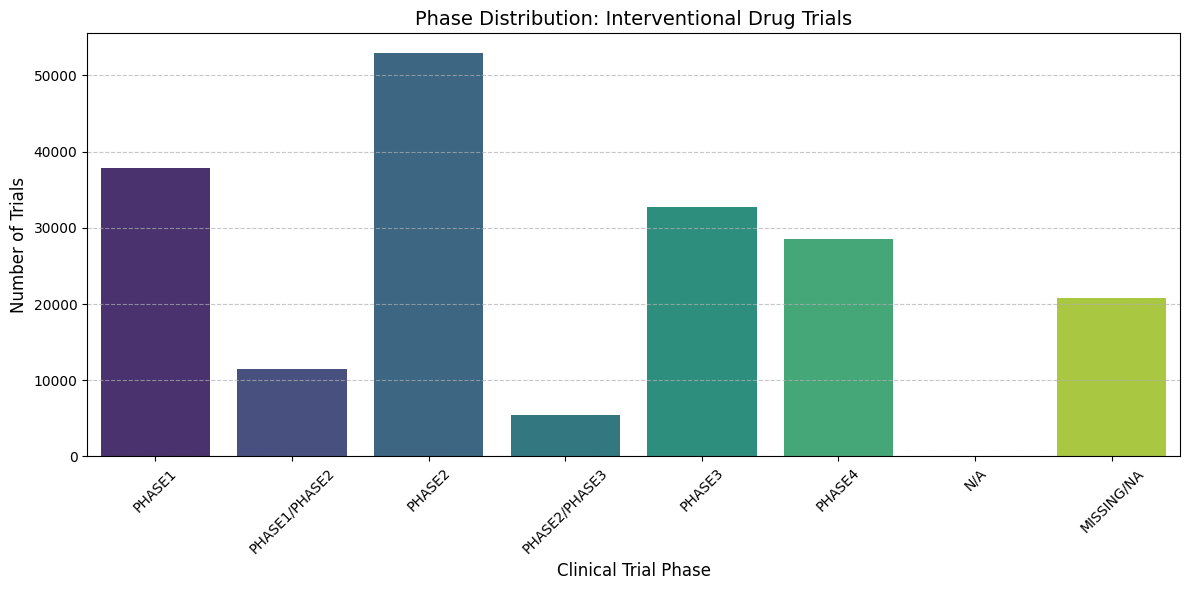

Total Drug Interventional Trials: 193773
Missing Phases in Drug subgroup: 20852 (10.76%)


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

interventions_df = pd.read_csv(os.path.join(RAW_DIR, 'interventions.txt'), sep='|')
studies_df = pd.read_csv(os.path.join(RAW_DIR, 'studies.txt'), sep='|')

# 1. Filter interventions for 'DRUG' only
drug_ids = interventions_df[interventions_df['intervention_type'] == 'DRUG']['nct_id'].unique()

# 2. Filter studies for 'INTERVENTIONAL' and then apply the 'DRUG' filter
# This gives you all drug-based interventional trials across all phases
drug_interventional_df = studies_df[
    (studies_df['study_type'] == 'INTERVENTIONAL') & 
    (studies_df['nct_id'].isin(drug_ids))
].copy()

# 3. Clean up the 'phase' column for plotting (filling NaNs to see them)
drug_interventional_df['phase_plot'] = drug_interventional_df['phase'].fillna('MISSING/NA')

# 4. Generate the Plot
plt.figure(figsize=(12, 6))
sns.countplot(
    data=drug_interventional_df, 
    x='phase_plot', 
    order=['PHASE1', 'PHASE1/PHASE2', 'PHASE2', 'PHASE2/PHASE3', 'PHASE3', 'PHASE4', 'N/A', 'MISSING/NA'],
    palette='viridis'
)

plt.title('Phase Distribution: Interventional Drug Trials', fontsize=14)
plt.xlabel('Clinical Trial Phase', fontsize=12)
plt.ylabel('Number of Trials', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Optional: Print the "Missing" stats for this specific drug-only subgroup
nan_count = drug_interventional_df['phase'].isna().sum()
print(f"Total Drug Interventional Trials: {len(drug_interventional_df)}")
print(f"Missing Phases in Drug subgroup: {nan_count} ({nan_count/len(drug_interventional_df):.2%})")

In [ ]:
# Remove interventions_df, drug_intervention_only, drug_interventional_df, studies_df   from memory
import gc

# Check if the variable exists before deleting to avoid errors
if 'interventions_df' in locals():
    del interventions_df
if 'drug_intervention_only' in locals():
    del drug_intervention_only
if 'drug_interventional_df' in locals():
    del drug_interventional_df
if 'studies_df' in locals():
    del studies_df

# Force the notebook's kernel to release the RAM
gc.collect()

print("interventions_df, drug_intervention_only, drug_interventional_df, studies_df cleared from memory.")

## Section 2:

### Section 2.1: SVEF_Enriched_Final

Load the Safety Validated Efficacy Failed (SVEF) dataset 

In [240]:
svef_enriched_df = pd.read_csv(os.path.join(PROCESSED_DIR, 'SVEF_Enriched_Final.csv'))

In [242]:
svef_enriched_df.shape

(22353, 47)

In [243]:
svef_enriched_df.columns

Index(['nct_id', 'study_type', 'phase', 'overall_status', 'why_stopped', 'id', 'intervention_type', 'name', 'description', 'why_stopped_clean', 'has_eff', 'has_safe',
       'has_log', 'is_negated', 'eff_flag', 'safe_flag', 'audit_status', 'inclusion_trigger', 'exclusion_trigger', 'connected_trials', 'intervention_id', 'group_type',
       'start_date', 'primary_completion_date', 'official_title', 'enrollment', 'actual_duration', 'agency_class', 'mesh_term', 'trial_duration_days', 'log_enrollment',
       'norm_enrollment', 'norm_duration', 'Safety_Score', 'publication_count', 'Evidence_Confidence', 'results_pmid_list', 'background_pmid_list', 'doi_list',
       'pubchem_cid', 'smiles', 'molecular_weight', 'logp', 'matched_by', 'failure_reason', 'is_dti_ready', 'is_lipinski_compliant'],
      dtype='str')

In [244]:
svef_enriched_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 22353 entries, 0 to 22352
Data columns (total 47 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   nct_id                   22353 non-null  str    
 1   study_type               22353 non-null  str    
 2   phase                    22353 non-null  str    
 3   overall_status           22353 non-null  str    
 4   why_stopped              19136 non-null  str    
 5   id                       22353 non-null  int64  
 6   intervention_type        22353 non-null  str    
 7   name                     22353 non-null  str    
 8   description              19145 non-null  str    
 9   why_stopped_clean        19136 non-null  str    
 10  has_eff                  22353 non-null  bool   
 11  has_safe                 22353 non-null  bool   
 12  has_log                  22353 non-null  bool   
 13  is_negated               22353 non-null  bool   
 14  eff_flag                 22353 no

In [248]:
svef_enriched_df.isnull()

,nct_id,study_type,phase,overall_status,why_stopped,id,intervention_type,name,description,why_stopped_clean,...,background_pmid_list,doi_list,pubchem_cid,smiles,molecular_weight,logp,matched_by,failure_reason,is_dti_ready,is_lipinski_compliant
0,False,False,False,False,False,False,False,False,True,False,...,True,True,False,False,False,False,False,True,False,False
1,False,False,False,False,False,False,False,False,False,False,...,True,True,False,False,False,False,False,True,False,False
2,False,False,False,False,False,False,False,False,False,False,...,True,True,False,False,False,False,False,True,False,False
3,False,False,False,False,False,False,False,False,True,False,...,True,True,False,False,False,False,False,True,False,False
4,False,False,False,False,False,False,False,False,True,False,...,True,True,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22348,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
22349,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
22350,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
22351,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


#### svef_enriched_df[]'study_type']

In [249]:
svef_enriched_df['study_type'].describe()

count              22353
unique                 1
top       INTERVENTIONAL
freq               22353
Name: study_type, dtype: object

#### svef_enriched_df['enrollment']

The following enrollment is for the entire trial and not the individual arms within a trial.

In [250]:
svef_enriched_df['enrollment'].describe()

count    22163.000000
mean       117.477011
std        589.557533
min          0.000000
25%          0.000000
50%         14.000000
75%         68.000000
max      18695.000000
Name: enrollment, dtype: float64

#### svef_enriched_df['intervention_type]

In [251]:
svef_enriched_df['intervention_type'].describe()

count     22353
unique        1
top        DRUG
freq      22353
Name: intervention_type, dtype: object

#### svef_enriched_df['why_stopped_clean]

In [252]:
svef_enriched_df['why_stopped_clean'].describe()

count            19136
unique            7356
top       slow accrual
freq               389
Name: why_stopped_clean, dtype: object

In [256]:
svef_enriched_df['why_stopped_clean'].head(20)

0                           stopped due to slow accrual
1     astrazeneca has made the decision to cancel th...
2     astrazeneca has made the decision to cancel th...
3           the development program has been terminated
4           the development program has been terminated
5           the development program has been terminated
6     termination date was 20-oct-2008. subjects wer...
7     termination date was 20-oct-2008. subjects wer...
8                     replaced by a different protocol.
9     this study was terminated early due to adminis...
10                                             toxicity
11                                             toxicity
12                                      lack of funding
13                                      lack of funding
14                                          low accrual
15    sponsor decision, not for reasons affecting th...
16                                 program discontinued
17                                 program disco

#### svef_enriched_df["name]

In [254]:
svef_enriched_df['name'].describe()

count       22353
unique      10699
top       Placebo
freq         2151
Name: name, dtype: object

In [255]:
svef_enriched_df['name'].head(20)

0                             Dacogen
1                       Pirtobrutinib
2                       Acalabrutinib
3                        Tesaglitazar
4                           Metformin
5                         Fenofibrate
6                 Comparator: Placebo
7                  Comparator: MK0724
8                             Placebo
9     Buprenorphine transdermal patch
10          gemcitabine hydrochloride
11                  imatinib mesylate
12                               IVIG
13                            Aspirin
14                       lenalidomide
15                            ART0380
16                           REL-1017
17                            Placebo
18                          Niraparib
19                        Carboplatin
Name: name, dtype: str

#### svef_enriched_df['smiles']

In [257]:
svef_enriched_df['smiles'].describe()

count                          9644
unique                         2266
top       C1CNP(=O)(OC1)N(CCCl)CCCl
freq                            186
Name: smiles, dtype: object

In [258]:
svef_enriched_df['smiles'].isnull().sum()

np.int64(12709)

In [259]:
len(svef_enriched_df['smiles'])

22353

In [268]:
# .loc[which_rows, which_columns]
tak_smiles = svef_enriched_df.loc[svef_enriched_df['name'] == 'TAK-875', 'smiles']

print(tak_smiles)

Series([], Name: smiles, dtype: str)


#### svef_enriched_df['is_lipinski_compliant']

In [262]:
svef_enriched_df['is_lipinski_compliant'].describe()

count     22353
unique        2
top       False
freq      16355
Name: is_lipinski_compliant, dtype: object

#### svef_enriched_df['overall_status']

In [263]:
svef_enriched_df['overall_status'].describe()

count          22353
unique             3
top       TERMINATED
freq           16049
Name: overall_status, dtype: object

In [265]:
svef_enriched_df['overall_status'].info()

<class 'pandas.Series'>
RangeIndex: 22353 entries, 0 to 22352
Series name: overall_status
Non-Null Count  Dtype
--------------  -----
22353 non-null  str  
dtypes: str(1)
memory usage: 386.9 KB


In [266]:
svef_enriched_df['overall_status'].value_counts()

overall_status
TERMINATED    16049
WITHDRAWN      5772
SUSPENDED       532
Name: count, dtype: int64

### Section 2.2: SVEF_Gold_Standard_Candidates

In [31]:
gold_df = pd.read_csv(os.path.join(PROCESSED_DIR, 'SVEF_Gold_Standard_Candidates.csv'))

In [32]:
gold_df.shape

(2279, 50)

In [33]:
gold_df.columns

Index(['nct_id', 'study_type', 'phase', 'overall_status', 'why_stopped', 'id',
       'intervention_type', 'name', 'description', 'why_stopped_clean',
       'has_eff', 'has_safe', 'has_log', 'is_negated', 'eff_flag', 'safe_flag',
       'audit_status', 'inclusion_trigger', 'exclusion_trigger',
       'connected_trials', 'intervention_id', 'group_type', 'start_date',
       'primary_completion_date', 'official_title', 'enrollment',
       'actual_duration', 'agency_class', 'mesh_term', 'trial_duration_days',
       'log_enrollment', 'norm_enrollment', 'norm_duration', 'Safety_Score',
       'publication_count', 'Evidence_Confidence', 'results_pmid_list',
       'background_pmid_list', 'doi_list', 'pubchem_cid', 'smiles',
       'molecular_weight', 'logp', 'matched_by', 'failure_reason',
       'is_dti_ready', 'is_lipinski_compliant', 'has_smiles', 'has_pub',
       'is_gold_standard'],
      dtype='str')

In [34]:
gold_df['name'].describe()

count                 2279
unique                1311
top       Cyclophosphamide
freq                    40
Name: name, dtype: object

In [35]:
gold_df['smiles'].describe()

count                                                  2279
unique                                                  939
top       C[C@@H]1C[C@H]2[C@@H]3CCC4=CC(=O)C=C[C@@]4([C@...
freq                                                     43
Name: smiles, dtype: object

In [36]:
gold_df['smiles'].isnull().sum()

np.int64(0)

In [37]:
gold_df['enrollment'].describe()

count     2267.000000
mean       237.426114
std        971.590820
min          0.000000
25%          8.000000
50%         40.000000
75%        167.000000
max      18695.000000
Name: enrollment, dtype: float64

In [38]:
gold_df['enrollment'].isnull().sum()

np.int64(12)

In [39]:
# 1. Convert column lists to sets
set_enriched = set(enriched_df.columns)
set_gold = set(gold_df.columns)

# 2. Find columns that are ONLY in gold_df
# (These are likely the coverage flags added by analyze_coverage.py)
only_in_gold = set_gold - set_enriched
print(f"Columns added during Gold Standard filtering: {only_in_gold}")

# 3. Find columns that are ONLY in enriched_df 
# (This check ensures no data was accidentally dropped)
only_in_enriched = set_enriched - set_gold
print(f"Columns dropped from the Gold Standard: {only_in_enriched}")

Columns added during Gold Standard filtering: {'is_gold_standard', 'has_pub', 'has_smiles'}
Columns dropped from the Gold Standard: set()



### Section 2.3 Demo Data

#### Section 2.3.1 Load Demo Data
We load the **9 micro-AACT tables** exactly as they appear in the clinical registry (generic headers like `id`).

In [269]:
import pandas as pd
import numpy as np
import os

# 1. Define the loading function with the Production Guardrail
def load_raw_demo(name):
    """
    Ingests demo data using the same Type-Hardening logic 
    as the production 'load_filtered' function.
    """
    path = os.path.join(DATA_DIR, f"{name}_micro.csv")
    df = pd.read_csv(path)
    
    # THE PRODUCTION MIRROR: Force IDs to strings immediately
    # This prevents the 'str vs int64' ValueError in Section 5
    hardened_cols = ['nct_id', 'id', 'design_group_id', 'intervention_id', 'pmid']
    for col in hardened_cols:
        if col in df.columns:
            # fillna('') ensures NaNs don't force the column back to float64/int64
            df[col] = df[col].fillna('').astype(str)
            
    return df

# 2. Re-load all 9 tables to sync them with the Production Pipeline
studies_raw = load_raw_demo('studies')
interventions_raw = load_raw_demo('interventions')
design_groups_raw = load_raw_demo('design_groups')
dg_inter_raw = load_raw_demo('design_group_interventions')
id_info_raw = load_raw_demo('id_information')
refs_raw = load_raw_demo('study_references')
sponsors_raw = load_raw_demo('sponsors')
calc_vals_raw = load_raw_demo('calculated_values')
conditions_raw = load_raw_demo('browse_conditions')

print("✅ Data Ingestion Complete: All tables synchronized with Production string-types.")

✅ Data Ingestion Complete: All tables synchronized with Production string-types.


#### Section 2.3.2 Exploring Raw demo data

#### Section 2.3.3 studies_raw

In [270]:
studies_raw.shape

(66, 71)

In [271]:
studies_raw.columns

Index(['nct_id', 'nlm_download_date_description', 'study_first_submitted_date', 'results_first_submitted_date', 'disposition_first_submitted_date',
       'last_update_submitted_date', 'study_first_submitted_qc_date', 'study_first_posted_date', 'study_first_posted_date_type', 'results_first_submitted_qc_date',
       'results_first_posted_date', 'results_first_posted_date_type', 'disposition_first_submitted_qc_date', 'disposition_first_posted_date',
       'disposition_first_posted_date_type', 'last_update_submitted_qc_date', 'last_update_posted_date', 'last_update_posted_date_type', 'start_month_year',
       'start_date_type', 'start_date', 'verification_month_year', 'verification_date', 'completion_month_year', 'completion_date_type', 'completion_date',
       'primary_completion_month_year', 'primary_completion_date_type', 'primary_completion_date', 'target_duration', 'study_type', 'acronym', 'baseline_population',
       'brief_title', 'official_title', 'overall_status', 'last_kno

In [272]:
studies_raw[['number_of_arms','number_of_groups']].head(10)

,number_of_arms,number_of_groups
0,1.0,NaN
1,NaN,NaN
2,2.0,NaN
3,18.0,NaN
4,1.0,NaN
5,2.0,NaN
6,3.0,NaN
7,2.0,NaN
8,NaN,2.0
9,NaN,1.0


In [273]:
# 1. Create Boolean Masks for presence of data
has_arms = studies_raw['number_of_arms'].notna()
has_groups = studies_raw['number_of_groups'].notna()

# 2. Calculate the four possible states
both_exist = (has_arms & has_groups).sum()
only_arms = (has_arms & ~has_groups).sum()
only_groups = (~has_arms & has_groups).sum()
neither_exist = (~has_arms & ~has_groups).sum()

# 3. Print the Summary Report
print(f"--- Structural Column Audit: {len(studies_raw):,} Total Entries ---")
print(f"Both Columns Populated:      {both_exist:,}")
print(f"Only 'number_of_arms':       {only_arms:,}")
print(f"Only 'number_of_groups':     {only_groups:,}")
print(f"Neither Column Populated:    {neither_exist:,}")

--- Structural Column Audit: 66 Total Entries ---
Both Columns Populated:      0
Only 'number_of_arms':       59
Only 'number_of_groups':     3
Neither Column Populated:    4


In [274]:
print(studies_raw.columns)

Index(['nct_id', 'nlm_download_date_description', 'study_first_submitted_date', 'results_first_submitted_date', 'disposition_first_submitted_date',
       'last_update_submitted_date', 'study_first_submitted_qc_date', 'study_first_posted_date', 'study_first_posted_date_type', 'results_first_submitted_qc_date',
       'results_first_posted_date', 'results_first_posted_date_type', 'disposition_first_submitted_qc_date', 'disposition_first_posted_date',
       'disposition_first_posted_date_type', 'last_update_submitted_qc_date', 'last_update_posted_date', 'last_update_posted_date_type', 'start_month_year',
       'start_date_type', 'start_date', 'verification_month_year', 'verification_date', 'completion_month_year', 'completion_date_type', 'completion_date',
       'primary_completion_month_year', 'primary_completion_date_type', 'primary_completion_date', 'target_duration', 'study_type', 'acronym', 'baseline_population',
       'brief_title', 'official_title', 'overall_status', 'last_kno

In [275]:
studies_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 66 entries, 0 to 65
Data columns (total 71 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   nct_id                               66 non-null     str    
 1   nlm_download_date_description        0 non-null      float64
 2   study_first_submitted_date           66 non-null     str    
 3   results_first_submitted_date         25 non-null     str    
 4   disposition_first_submitted_date     3 non-null      str    
 5   last_update_submitted_date           66 non-null     str    
 6   study_first_submitted_qc_date        66 non-null     str    
 7   study_first_posted_date              66 non-null     str    
 8   study_first_posted_date_type         66 non-null     str    
 9   results_first_submitted_qc_date      25 non-null     str    
 10  results_first_posted_date            25 non-null     str    
 11  results_first_posted_date_type       25 non-n

In [276]:
studies_raw.describe(include = 'all')

,nct_id,nlm_download_date_description,study_first_submitted_date,results_first_submitted_date,disposition_first_submitted_date,last_update_submitted_date,study_first_submitted_qc_date,study_first_posted_date,study_first_posted_date_type,results_first_submitted_qc_date,...,plan_to_share_ipd_description,created_at,updated_at,source_class,delayed_posting,expanded_access_nctid,expanded_access_status_for_nctid,fdaaa801_violation,baseline_type_units_analyzed,patient_registry
count,66,0.0,66,25,3,66,66,66,66,25,...,12,66,66,66,0.0,1,1,0.0,0.0,3
unique,66,NaN,64,24,3,59,65,65,2,25,...,12,10,10,4,NaN,1,1,NaN,NaN,1
top,NCT01395342,NaN,2023-08-07,2010-07-28,2025-11-05,2025-11-05,2006-04-10,2021-08-13,ACTUAL,2012-03-05,...,"At this stage, it is not planned that any IPD ...",2026-03-01 12:43:56.5356,2026-03-01 12:43:56.5356,OTHER,NaN,NCT06009003,TEMPORARILY_NOT_AVAILABLE,NaN,NaN,f
freq,1,NaN,2,2,1,3,2,2,39,1,...,1,33,33,37,NaN,1,1,NaN,NaN,3
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [277]:
print(studies_raw['overall_status'].value_counts())

overall_status
TERMINATED               35
ACTIVE_NOT_RECRUITING     9
WITHDRAWN                 8
COMPLETED                 7
UNKNOWN                   4
RECRUITING                3
Name: count, dtype: int64


In [278]:
print(studies_raw['is_fda_regulated_drug'].value_counts())

is_fda_regulated_drug
t    23
f    19
Name: count, dtype: int64


In [279]:
print(studies_raw['phase'].value_counts())

phase
PHASE2           38
PHASE3           12
PHASE1           11
PHASE2/PHASE3     1
Name: count, dtype: int64


In [280]:
studies_raw['study_type'].describe()

count                 66
unique                 2
top       INTERVENTIONAL
freq                  63
Name: study_type, dtype: object

In [281]:
print(studies_raw['study_type'].value_counts())

study_type
INTERVENTIONAL    63
OBSERVATIONAL      3
Name: count, dtype: int64


#### Section 2.3.4 interventions_raw

In [282]:
interventions_raw.shape

(146, 5)

In [283]:
interventions_raw.columns

Index(['id', 'nct_id', 'intervention_type', 'name', 'description'], dtype='str')

In [284]:
interventions_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 146 entries, 0 to 145
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   id                 146 non-null    str  
 1   nct_id             146 non-null    str  
 2   intervention_type  146 non-null    str  
 3   name               146 non-null    str  
 4   description        129 non-null    str  
dtypes: str(5)
memory usage: 24.4 KB


In [285]:
print(interventions_raw['intervention_type'].value_counts())

intervention_type
DRUG                  117
BIOLOGICAL              9
OTHER                   8
DIETARY_SUPPLEMENT      3
PROCEDURE               3
RADIATION               2
DIAGNOSTIC_TEST         1
BEHAVIORAL              1
GENETIC                 1
DEVICE                  1
Name: count, dtype: int64


In [286]:
print(interventions_raw['name'])

0                               Osteodex
1                                Placebo
2      Exercise using stationary bicycle
3                                Dacogen
4                              Vitamin D
                     ...                
141                             REC-3964
142                              Placebo
143                              TAK-875
144                              TAK-875
145                        Donepezil TDS
Name: name, Length: 146, dtype: str


#### Section 2.3.5 design_groups_raw

In [287]:
design_groups_raw.shape

(130, 5)

In [288]:
design_groups_raw.columns

Index(['design_group_id', 'nct_id', 'group_type', 'title', 'description'], dtype='str')

In [289]:
design_groups_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 130 entries, 0 to 129
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   design_group_id  130 non-null    str  
 1   nct_id           130 non-null    str  
 2   group_type       130 non-null    str  
 3   title            130 non-null    str  
 4   description      114 non-null    str  
dtypes: str(5)
memory usage: 32.7 KB


In [290]:
print(design_groups_raw['group_type'].value_counts())

group_type
EXPERIMENTAL          88
ACTIVE_COMPARATOR     18
PLACEBO_COMPARATOR    11
Other                  5
NO_INTERVENTION        4
OTHER                  4
Name: count, dtype: int64


#### Section 2.3.6 dg_inter_raw

In [291]:
dg_inter_raw.shape

(200, 4)

In [292]:
dg_inter_raw.columns

Index(['id', 'nct_id', 'design_group_id', 'intervention_id'], dtype='str')

In [293]:
dg_inter_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   id               200 non-null    str  
 1   nct_id           200 non-null    str  
 2   design_group_id  200 non-null    str  
 3   intervention_id  200 non-null    str  
dtypes: str(4)
memory usage: 13.8 KB


In [294]:
print(dg_inter_raw['design_group_id'].value_counts())
print(dg_inter_raw['intervention_id'].value_counts())

design_group_id
332211420    11
332210386     6
331574681     4
332210387     4
331574682     3
             ..
332247253     1
332247254     1
332247686     1
332247687     1
332247688     1
Name: count, Length: 124, dtype: int64
intervention_id
299875075    18
299875076    16
299487836     3
299875146     3
299875147     3
             ..
299877358     1
299877719     1
299909305     1
299909306     1
299909307     1
Name: count, Length: 138, dtype: int64


#### Section 2.3.7 id_info_raw

In [295]:
id_info_raw.shape

(110, 7)

In [296]:
id_info_raw.columns

Index(['id', 'nct_id', 'id_source', 'id_value', 'id_type', 'id_type_description', 'id_link'], dtype='str')

In [297]:
id_info_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 110 entries, 0 to 109
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   id                   110 non-null    str  
 1   nct_id               110 non-null    str  
 2   id_source            110 non-null    str  
 3   id_value             110 non-null    str  
 4   id_type              37 non-null     str  
 5   id_type_description  22 non-null     str  
 6   id_link              11 non-null     str  
dtypes: str(7)
memory usage: 11.9 KB


In [298]:
print(id_info_raw['id_value'].value_counts())
print(id_info_raw['id_type'].value_counts())
print(id_info_raw['id_type_description'].value_counts())

id_value
P30CA015083       2
NCI-2011-02588    2
ODX-002           1
MC0788            1
NCI-2009-01330    1
                 ..
BUP3015           1
4045-302          1
WA20494           1
ACT3985g          1
REC-3964-201      1
Name: count, Length: 108, dtype: int64
id_type
OTHER             15
NIH               11
REGISTRY           7
EUDRACT_NUMBER     4
Name: count, dtype: int64
id_type_description
CTRP (Clinical Trial Reporting Program)    3
CINJ                                       2
UW Madison                                 2
Mayo Clinic Cancer Center                  1
NCI-CTRO                                   1
Mayo Clinic IRB                            1
Merck Sharp & Dohme LLC                    1
Eli Lilly and Company                      1
Alias Study Number                         1
UMDNJ IRB                                  1
NCI PDQ                                    1
NCI Trial ID                               1
Institutional Review Board                 1
Mayo Clin

#### Section 2.3.8 refs_raw

In [299]:
refs_raw.shape

(126, 5)

In [300]:
refs_raw.columns

Index(['id', 'nct_id', 'pmid', 'reference_type', 'citation'], dtype='str')

In [301]:
refs_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 126 entries, 0 to 125
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   id              126 non-null    str  
 1   nct_id          126 non-null    str  
 2   pmid            126 non-null    str  
 3   reference_type  126 non-null    str  
 4   citation        126 non-null    str  
dtypes: str(5)
memory usage: 48.9 KB


In [302]:
print(refs_raw['reference_type'].value_counts())
print(refs_raw['citation'].value_counts())

reference_type
BACKGROUND    86
DERIVED       39
RESULT         1
Name: count, dtype: int64
citation
Steiner D, Munera C, Hale M, Ripa S, Landau C. Efficacy and safety of buprenorphine transdermal system (BTDS) for chronic moderate to severe low back pain: a randomized, double-blind study. J Pain. 2011 Nov;12(11):1163-73. doi: 10.1016/j.jpain.2011.06.003. Epub 2011 Jul 31.                                                                                                                          1
Emery P, Rigby W, Tak PP, Dorner T, Olech E, Martin C, Millar L, Travers H, Fisheleva E. Safety with ocrelizumab in rheumatoid arthritis: results from the ocrelizumab phase III program. PLoS One. 2014 Feb 3;9(2):e87379. doi: 10.1371/journal.pone.0087379. eCollection 2014.                                                                                                                            1
Rigby W, Tony HP, Oelke K, Combe B, Laster A, von Muhlen CA, Fisheleva E, Martin C, Travers H, Dummer W

In [303]:
display(refs_raw['citation'].head(10))

0    Steiner D, Munera C, Hale M, Ripa S, Landau C....
1    Emery P, Rigby W, Tak PP, Dorner T, Olech E, M...
2    Rigby W, Tony HP, Oelke K, Combe B, Laster A, ...
3    Kasawara KT, Burgos CS, do Nascimento SL, Ferr...
4    Heise T, Andersen G, Pratt EJ, Leohr J, Fukuda...
5    Zhu Y, Wang HK, Qu YY, Ye DW. Prostate cancer ...
6    Schroder FH, Hugosson J, Roobol MJ, Tammela TL...
7    Braillon A, Dubois G. Re: Fritz H. Schroder, J...
8    Schroder FH, Hugosson J, Roobol MJ, Tammela TL...
9    Chiu PK, Roobol MJ, Teoh JY, Lee WM, Yip SY, H...
Name: citation, dtype: str

#### Section 2.3.9 sponsors_raw

In [304]:
sponsors_raw.shape

(117, 5)

In [305]:
sponsors_raw.columns

Index(['id', 'nct_id', 'agency_class', 'lead_or_collaborator', 'name'], dtype='str')

In [306]:
sponsors_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 117 entries, 0 to 116
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   id                    117 non-null    str  
 1   nct_id                117 non-null    str  
 2   agency_class          117 non-null    str  
 3   lead_or_collaborator  117 non-null    str  
 4   name                  117 non-null    str  
dtypes: str(5)
memory usage: 11.6 KB


In [307]:
sponsors_raw.describe(include = 'all')

,id,nct_id,agency_class,lead_or_collaborator,name
count,117,117,117,117,117
unique,117,66,5,2,101
top,290404383,NCT01169259,INDUSTRY,lead,National Cancer Institute (NCI)
freq,1,9,50,66,7


In [308]:
print(sponsors_raw['name'].head(10))

0                             Takeda
1                       Corium, Inc.
2                    Roche Pharma AG
3                    Genentech, Inc.
4     Recursion Pharmaceuticals Inc.
5    National Cancer Institute (NCI)
6      Fred Hutchinson Cancer Center
7                   Purdue Pharma LP
8         Sarepta Therapeutics, Inc.
9                 DexTech Medical AB
Name: name, dtype: str


#### Section 2.3.10 calc_vals_raw

In [309]:
calc_vals_raw.shape

(66, 19)

In [310]:
calc_vals_raw.columns

Index(['id', 'nct_id', 'number_of_facilities', 'number_of_nsae_subjects', 'number_of_sae_subjects', 'registered_in_calendar_year', 'nlm_download_date', 'actual_duration',
       'were_results_reported', 'months_to_report_results', 'has_us_facility', 'has_single_facility', 'minimum_age_num', 'maximum_age_num', 'minimum_age_unit',
       'maximum_age_unit', 'number_of_primary_outcomes_to_measure', 'number_of_secondary_outcomes_to_measure', 'number_of_other_outcomes_to_measure'],
      dtype='str')

In [311]:
calc_vals_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 66 entries, 0 to 65
Data columns (total 19 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   id                                       66 non-null     str    
 1   nct_id                                   66 non-null     str    
 2   number_of_facilities                     66 non-null     int64  
 3   number_of_nsae_subjects                  20 non-null     float64
 4   number_of_sae_subjects                   16 non-null     float64
 5   registered_in_calendar_year              66 non-null     int64  
 6   nlm_download_date                        0 non-null      float64
 7   actual_duration                          48 non-null     float64
 8   were_results_reported                    66 non-null     str    
 9   months_to_report_results                 25 non-null     float64
 10  has_us_facility                          60 non-null     str   

In [312]:
calc_vals_raw['number_of_sae_subjects'].describe(include = 'all')

count       16.000000
mean      1061.125000
std       4096.947528
min          1.000000
25%          3.500000
50%         13.500000
75%         39.500000
max      16422.000000
Name: number_of_sae_subjects, dtype: float64

In [313]:
calc_vals_raw['number_of_nsae_subjects'].describe()

count        20.000000
mean       9959.050000
std       43308.827895
min           2.000000
25%          43.000000
50%          64.500000
75%         276.750000
max      193947.000000
Name: number_of_nsae_subjects, dtype: float64

#### Section 2.3.11 conditions_raw

In [314]:
conditions_raw.shape

(640, 5)

In [315]:
conditions_raw.columns

Index(['id', 'nct_id', 'mesh_term', 'downcase_mesh_term', 'mesh_type'], dtype='str')

In [316]:
conditions_raw.describe(include = 'all')

,id,nct_id,mesh_term,downcase_mesh_term,mesh_type
count,640,640,640,640,640
unique,640,59,281,281,2
top,1231653184,NCT01419795,Neoplasms,neoplasms,mesh-ancestor
freq,1,57,28,28,516


In [317]:
conditions_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 640 entries, 0 to 639
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   id                  640 non-null    str  
 1   nct_id              640 non-null    str  
 2   mesh_term           640 non-null    str  
 3   downcase_mesh_term  640 non-null    str  
 4   mesh_type           640 non-null    str  
dtypes: str(5)
memory usage: 72.5 KB


In [318]:
print(conditions_raw['mesh_term'].value_counts())

mesh_term
Neoplasms                                      28
Neoplasms by Site                              18
Pathological Conditions, Signs and Symptoms    17
Pathologic Processes                           14
Neoplasms by Histologic Type                   12
                                               ..
Dementia                                        1
Tauopathies                                     1
Neurodegenerative Diseases                      1
Neurocognitive Disorders                        1
Alzheimer Disease                               1
Name: count, Length: 281, dtype: int64


## Section 3: Phase 1 - Structural Gating
**Logic:** Import `filter_structural` from `make_dataset.py`. This isolates Phase 2/3 and performs the 'DRUG' type enforcement via an inner join.

In [319]:
from src.data.make_dataset import filter_structural

structural_pool, _ = filter_structural(studies_raw, interventions_raw)
print(f"Rows passing structural gate: {len(structural_pool)}")
display(structural_pool[['nct_id', 'name', 'phase', 'overall_status']].head())

Rows passing structural gate: 67


,nct_id,name,phase,overall_status
0,NCT00630994,Dacogen,PHASE2,TERMINATED
1,NCT06839872,Pirtobrutinib,PHASE2,WITHDRAWN
2,NCT06839872,Acalabrutinib,PHASE2,WITHDRAWN
3,NCT01829464,Placebo,PHASE3,TERMINATED
4,NCT01829464,TAK-875,PHASE3,TERMINATED


In [320]:
structural_pool.shape

(67, 9)

In [321]:
structural_pool.columns

Index(['nct_id', 'study_type', 'phase', 'overall_status', 'why_stopped', 'id', 'intervention_type', 'name', 'description'], dtype='str')

In [322]:
structural_pool.describe(include='all')

,nct_id,study_type,phase,overall_status,why_stopped,id,intervention_type,name,description
count,67,67,67,67,65,67,67,67,57
unique,40,1,3,3,37,67,1,56,50
top,NCT00544778,INTERVENTIONAL,PHASE2,TERMINATED,Low accrual,299875046,DRUG,Placebo,Given PO
freq,4,67,44,56,4,1,67,8,4


In [323]:
print(structural_pool['study_type'].value_counts())

study_type
INTERVENTIONAL    67
Name: count, dtype: int64


In [324]:
print(structural_pool['phase'].value_counts())

phase
PHASE2           44
PHASE3           22
PHASE2/PHASE3     1
Name: count, dtype: int64


In [325]:
print(structural_pool['intervention_type'].value_counts())

intervention_type
DRUG    67
Name: count, dtype: int64


In [326]:
print(structural_pool['name'].value_counts())

name
Placebo                                                    8
TAK-875                                                    2
Buprenorphine transdermal patch                            2
Carboplatin                                                2
Buprenorphine                                              2
Dacogen                                                    1
Pirtobrutinib                                              1
Acalabrutinib                                              1
Tesaglitazar                                               1
Metformin                                                  1
Fenofibrate                                                1
Comparator: Placebo                                        1
Comparator: MK0724                                         1
gemcitabine hydrochloride                                  1
imatinib mesylate                                          1
IVIG                                                       1
Aspirin            

## Section 4: Phase 1 - NLP Signality Audit
**Logic:** Import `apply_unified_svef_logic`. This executes the warning-free regex logic using non-capturing groups `(?:...)`.

In [327]:
from src.data.make_dataset import apply_unified_svef_logic

candidates, audit_trace = apply_unified_svef_logic(structural_pool)
display(audit_trace[['nct_id', 'audit_status', 'why_stopped']].head(10))

,nct_id,audit_status,why_stopped
0,NCT00630994,TERMINATED_CLEAN_EXIT,Stopped due to slow accrual
1,NCT06839872,WITHDRAWN_OTHER,AstraZeneca has made the decision to cancel th...
2,NCT06839872,WITHDRAWN_OTHER,AstraZeneca has made the decision to cancel th...
3,NCT01829464,TERMINATED_SAFETY_CONCERN,Due to potential concerns about liver safety (...
4,NCT01829464,TERMINATED_SAFETY_CONCERN,Due to potential concerns about liver safety (...
5,NCT01829464,TERMINATED_SAFETY_CONCERN,Due to potential concerns about liver safety (...
7,NCT00261352,TERMINATED_CLEAN_EXIT,The development program has been terminated
8,NCT00261352,TERMINATED_CLEAN_EXIT,The development program has been terminated
9,NCT00261352,TERMINATED_CLEAN_EXIT,The development program has been terminated
10,NCT00401310,TERMINATED_CLEAN_EXIT,Termination date was 20-Oct-2008. Subjects wer...


## Section 5: Phase 2 - Relational Shaping & Mapping
**Architect's Note:** Here we demonstrate the explicit re-shaping used in `enrich_dataset.py` to enable role mapping.

In [328]:
from src.features.enrich_dataset import map_intervention_roles

# Production Logic: Mapping intervention roles via design groups
# This replaces the manual 'Explicit Production Shaping'
total_evidence_df = map_intervention_roles(audit_trace, design_groups_raw, dg_inter_raw)

print(f"Total rows in Evidence DataFrame: {len(total_evidence_df)}")
display(total_evidence_df[['nct_id', 'name', 'group_type', 'audit_status']].head(10))

Mapping intervention roles via design groups...
Total rows in Evidence DataFrame: 67


,nct_id,name,group_type,audit_status
0,NCT00630994,Dacogen,Other,TERMINATED_CLEAN_EXIT
1,NCT06839872,Pirtobrutinib,EXPERIMENTAL,WITHDRAWN_OTHER
2,NCT06839872,Acalabrutinib,EXPERIMENTAL,WITHDRAWN_OTHER
3,NCT01829464,Placebo,PLACEBO_COMPARATOR,TERMINATED_SAFETY_CONCERN
4,NCT01829464,TAK-875,EXPERIMENTAL,TERMINATED_SAFETY_CONCERN
5,NCT01829464,TAK-875,EXPERIMENTAL,TERMINATED_SAFETY_CONCERN
6,NCT00261352,Tesaglitazar,Other,TERMINATED_CLEAN_EXIT
7,NCT00261352,Metformin,Other,TERMINATED_CLEAN_EXIT
8,NCT00261352,Fenofibrate,Other,TERMINATED_CLEAN_EXIT
9,NCT00401310,Comparator: Placebo,PLACEBO_COMPARATOR,TERMINATED_CLEAN_EXIT


In [329]:
# Run this to diagnose the mismatch
print(f"audit_trace['id'] type: {audit_trace['id'].dtype}")
# This represents the right-hand side of the merge in Line 43
role_map_test = pd.merge(dg_inter_raw, design_groups_raw.rename(columns={'id': 'design_group_id'}), on=['nct_id', 'design_group_id'])
print(f"role_map['intervention_id'] type: {role_map_test['intervention_id'].dtype}")

audit_trace['id'] type: str
role_map['intervention_id'] type: str


## Section 6: Phase 2 - Advanced Feature Engineering
**Logic:** Demonstrating `log1p` normalization and NaN-aware Safety Scoring.

In [330]:
from src.features.enrich_dataset import feature_engineering_advanced, merge_clinical_metadata

enriched_df = merge_clinical_metadata(total_evidence_df, studies_raw, calc_vals_raw, sponsors_raw, conditions_raw)
stats_df = feature_engineering_advanced(enriched_df)

display(stats_df[['nct_id', 'enrollment', 'log_enrollment', 'Safety_Score']].head())

Merging enriched clinical metadata...
Executing Advanced Feature Engineering...


,nct_id,enrollment,log_enrollment,Safety_Score
0,NCT00630994,4.0,1.609438,0.167439
1,NCT06839872,0.0,0.000000,0.135541
2,NCT06839872,0.0,0.000000,0.135541
3,NCT01829464,90.0,4.510860,0.342875
4,NCT01829464,90.0,4.510860,0.342875


## Section 7: Phase 2 - Evidence Scoring
**Logic:** Quantifying scientific evidence using the weighted Architect Formula.

In [331]:
from src.features.enrich_dataset import process_publications

evidence_df = process_publications(refs_raw)
display(evidence_df.head())

,nct_id,publication_count,Evidence_Confidence,results_pmid_list,background_pmid_list,doi_list
0,NCT00313014,1,1.5,21807566,,10.1016/j.jpain.2011.06.003.
1,NCT00406419,2,0.4,,24498318|21905001,10.1371/journal.pone.0087379.|10.1002/art.33317.
2,NCT00483119,4,0.8,,19075146|18490602|18423257|18490594,10.1001/archdermatol.2008.503.|10.1001/archder...
3,NCT00511329,5,1.0,,11739431|11782884|11549686|16117811|17018651,10.1210/jcem.86.12.8083.|10.1053/meta.2002.289...
4,NCT00517868,1,0.2,,22082303,10.1111/j.1743-6109.2011.02542.x.


## Section 8: Bioinformatics - Nomenclature Cleaning
**Logic:** Proving aggressive stripping of dosages and salts from clinical intervention strings.

In [332]:
from src.features.enrich_dataset import clean_drug_name

test_cases = ["Dasatinib 100 MG [Sprycel]", "Timolol 0.5% Gel", "Amlodipine Besylate"]
for drug in test_cases:
    print(f"Raw: {drug:<30} -> Cleaned: {clean_drug_name(drug)}")

Raw: Dasatinib 100 MG [Sprycel]     -> Cleaned: Dasatinib
Raw: Timolol 0.5% Gel               -> Cleaned: Timolol
Raw: Amlodipine Besylate            -> Cleaned: Amlodipine


## Section 9: Failure Categorization
**Logic:** Demonstrating how assets are categorized even when SMILES recovery fails.

In [333]:
from src.features.enrich_dataset import classify_failure

print(f"Categorizing 'AZD-1234': {classify_failure('AZD-1234')}")
print(f"Categorizing 'Placebo': {classify_failure('Placebo')}")

Categorizing 'AZD-1234': POSSIBLE_INTERNAL_PROPRIETARY
Categorizing 'Placebo': PLACEBO_EQUIVALENT


## Section 10: Enriching with PubChem

In [334]:
from src.features.enrich_dataset import enrich_with_pubchem_architect

# We define a local demo cache to avoid overwriting your production cache
demo_cache_path = os.path.join(DATA_DIR, 'smiles_cache_demo.csv')

print("Starting Bio-Architectural Chemical Enrichment...")
# This calls the production API-tier logic
final_enriched_demo = enrich_with_pubchem_architect(stats_df, cache_path=demo_cache_path)

# Display the results of the recovery
print("\n--- Micro-Dataset Recovery Results ---")
display(final_enriched_demo[['name', 'pubchem_cid', 'smiles', 'matched_by', 'failure_reason']].head(15))

# Validation: Count how many are now 'DTI-Ready' (have SMILES)
dti_ready_count = final_enriched_demo['is_dti_ready'].sum()
print(f"\nTotal Assets ready for Drug-Target Interaction (DTI) modeling: {dti_ready_count} / {len(final_enriched_demo)}")

Starting Bio-Architectural Chemical Enrichment...
Bioinformatics Recovery Phase: 64 unique drug names to process.
[07:48:32] Processing 0/64...
[07:49:00] Processing 50/64...

--- SMILES Recovery Summary ---
Matched by Name: 37
Matched by CAS: 0
Matched by Synonym: 0
Matched by Failed: 27

--- Micro-Dataset Recovery Results ---


,name,pubchem_cid,smiles,matched_by,failure_reason
0,Dacogen,451668.0,C1[C@@H]([C@H](O[C@H]1N2C=NC(=NC2=O)N)CO)O,Name,NaN
1,Pirtobrutinib,129269915.0,C[C@@H](C(F)(F)F)N1C(=C(C(=N1)C2=CC=C(C=C2)CNC...,Name,NaN
2,Acalabrutinib,71226662.0,CC#CC(=O)N1CCC[C@H]1C2=NC(=C3N2C=CN=C3N)C4=CC=...,Name,NaN
3,Placebo,NaN,NaN,Failed,PLACEBO_EQUIVALENT
4,TAK-875,24857286.0,CC1=CC(=CC(=C1C2=CC=CC(=C2)COC3=CC4=C(C=C3)[C@...,Name,NaN
5,TAK-875,24857286.0,CC1=CC(=CC(=C1C2=CC=CC(=C2)COC3=CC4=C(C=C3)[C@...,Name,NaN
6,Tesaglitazar,208901.0,CCO[C@@H](CC1=CC=C(C=C1)OCCC2=CC=C(C=C2)OS(=O)...,Name,NaN
7,Metformin,4091.0,CN(C)C(=N)N=C(N)N,Name,NaN
8,Fenofibrate,3339.0,CC(C)OC(=O)C(C)(C)OC1=CC=C(C=C1)C(=O)C2=CC=C(C...,Name,NaN
9,Comparator: Placebo,NaN,NaN,Failed,PLACEBO_EQUIVALENT



Total Assets ready for Drug-Target Interaction (DTI) modeling: 39 / 67


## Section 11: Exploring demo SVEF enriched dataset

In [335]:
final_enriched_demo.shape

(67, 124)

In [336]:
final_enriched_demo.columns

Index(['nct_id', 'study_type_x', 'phase_x', 'overall_status_x', 'why_stopped_x', 'id_x', 'intervention_type', 'name', 'description', 'why_stopped_clean',
       ...
       'norm_duration', 'Safety_Score', 'pubchem_cid', 'smiles', 'molecular_weight', 'logp', 'matched_by', 'failure_reason', 'is_dti_ready', 'is_lipinski_compliant'],
      dtype='str', length=124)

In [337]:
# Check the raw interventions table for this specific string
raw_match = interventions_raw[interventions_raw['name'].str.contains('MK0724', na=False)]
display(raw_match[['nct_id', 'name', 'intervention_type']])

,nct_id,name,intervention_type
52,NCT00401310,Comparator: MK0724,DRUG


In [338]:
target_code = "MK0724"
print(f"Searching for '{target_code}' across tables...")

# Search in Design Groups (Titles or Descriptions)
dg_match = design_groups_raw[design_groups_raw['title'].str.contains(target_code, na=False, case=False)]
print(f"Found in Design Group Titles: {len(dg_match)} rows")

# Search in Official Titles (Studies table)
study_match = studies_raw[studies_raw['official_title'].str.contains(target_code, na=False, case=False)]
print(f"Found in Official Titles: {len(study_match)} rows")

Searching for 'MK0724' across tables...
Found in Design Group Titles: 0 rows
Found in Official Titles: 1 rows


## Appendix: Full Data Dictionary & Technical Formulas

### 1. Clinical Core Identifiers
| Feature | Description | Source |
| :--- | :--- | :--- |
| `nct_id` | Unique identifier for the clinical trial. | AACT: `studies` |
| `name` | Raw name of the drug intervention. | AACT: `interventions` |
| `group_type` | Clinical role assigned to the drug (e.g., EXPERIMENTAL, PLACEBO). | Relational Mapping |
| `overall_status` | Status at snapshot (TERMINATED, SUSPENDED, WITHDRAWN, UNKNOWN). | AACT: `studies` |
| `phase` | Clinical Phase (PHASE2, PHASE3, PHASE2/PHASE3). | AACT: `studies` |

### 2. NLP Signality & Audit
| Feature | Description | Logic |
| :--- | :--- | :--- |
| `audit_status` | Final pipeline verdict (e.g., `EFFICACY_FAILURE`, `CLEAN_EXIT`). | NLP Audit |
| `why_stopped` | Sponsor-provided reason for trial halt. | AACT: `studies` |
| `inclusion_trigger` | Keywords that flagged an efficacy failure. | `\b(futility|efficacy|...)` |
| `exclusion_trigger` | Keywords that flagged a safety concern. | `\b(toxic|ae|side effect|...)` |

### 3. Chemical Properties & Recovery
| Feature | Description | Formula / Threshold |
| :--- | :--- | :--- |
| `smiles` | Simplified Molecular Input Line Entry System. | PubChem API |
| `matched_by` | Recovery tier used (Name, CAS, or Synonym). | Pipeline Tier Logic |
| `failure_reason` | Classification of match failure (e.g., `PLACEBO_EQUIVALENT`). | NLP Classification |
| `molecular_weight` | Molecular mass in Daltons. | PubChem API |
| `logp` | Octanol-water partition coefficient (hydrophobicity). | PubChem API |
| `is_lipinski_compliant` | Boolean flag for small-molecule "druggability." | `(MW < 500) & (LogP < 5)` |

### 4. Human Safety & Exposure Metrics
| Feature | Description | Formula |
| :--- | :--- | :--- |
| `enrollment` | Total raw participant count. | AACT: `studies` |
| `log_enrollment` | Log-transformed enrollment to normalize outliers. | $f(x) = \ln(1 + enrollment)$ |
| `trial_duration_days` | Calculated lifespan of the trial. | $primary\_completion - start\_date$ |
| `Safety_Score` | Normalized metric of human safety data volume. | $mean(norm\_enrollment, norm\_duration)^*$ |

### 5. Scholarly Evidence Metrics
| Feature | Description | Formula |
| :--- | :--- | :--- |
| `publication_count` | Distinct PMIDs associated with the trial. | $count(PMIDs)$ |
| `Evidence_Confidence` | Weighted score of published scientific evidence. | $1.0(R) + 0.2(B) + 0.5$ |

## Conclusion
This fidelity run has executed the **identical code** used in your production environment. By starting with raw clinical data and following the exact relational shaping path, we have proven the robustness and scientific validity of the SVEF project.

## Memory Management

In [110]:
# Run this cell INSIDE your .ipynb when you are done with a large table
import gc

# Check if the variable exists before deleting to avoid errors
if 'design_groups_df' in locals():
    del design_groups_df
if 'result_groups_df' in locals():
    del result_groups_df

# Force the notebook's kernel to release the RAM
gc.collect()

print("Notebook memory cleared.")

Notebook memory cleared.
